In [3]:
import pandas as pd
import gdown
file_id = "1QNJ3hfm7zLfJ21lizliWbqaDB8VqgaVb"  # replace with your actual file ID
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, "panel_data_final.xlsx", quiet=False)
# Load the Excel file
df = pd.read_excel('panel_data_final.xlsx', sheet_name='Panel Data')

# Check if it worked
print(df.shape)  # Shows (rows, columns)
print(df.head())

Downloading...
From: https://drive.google.com/uc?id=1QNJ3hfm7zLfJ21lizliWbqaDB8VqgaVb
To: c:\Users\kirub\Downloads\panel_data_final.xlsx
100%|██████████| 217k/217k [00:00<00:00, 518kB/s]


(625, 55)
   Year    Company            Sector  Net Sales (Revenue)  Cost of Sales  \
0  2000  Coca-Cola  Consumer Staples                20458           6204   
1  2001  Coca-Cola  Consumer Staples                20092           6044   
2  2002  Coca-Cola  Consumer Staples                19564           5776   
3  2003  Coca-Cola  Consumer Staples                21044           6260   
4  2004  Coca-Cola  Consumer Staples                21962           6312   

   Gross Profit  Operating Income (Loss)  Interest Income  Interest Expense  \
0         14254                     3691            345.0              -447   
1         14048                     4021            325.0              -289   
2         13788                     4059            209.0              -199   
3         14784                     5221            176.0              -178   
4         15650                     5698            157.0              -196   

   Other Income (Expense), net  ...  Operating Expenses (S

In [4]:
print("="*80)
print("BASIC INFORMATION")
print("="*80)
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

BASIC INFORMATION
Dataset shape: (625, 55)

Columns: ['Year', 'Company', 'Sector', 'Net Sales (Revenue)', 'Cost of Sales', 'Gross Profit', 'Operating Income (Loss)', 'Interest Income', 'Interest Expense', 'Other Income (Expense), net', 'Pre-Tax Income (Loss)', 'Income Tax Expense (Benefit)', 'Net Income (Loss)', 'EPS — Diluted ($)', 'Diluted Shares Outstanding (M)', 'Net Cash from Operations (CFO)', 'Capital Expenditures (CapEx)', 'Acquisitions', 'Net Cash from Investing (CFI)', 'Proceeds from Debt Issuance', 'Debt Repayment', 'Share Buybacks', 'Dividends Paid', 'Net Cash from Financing (CFF)', 'Net Change in Cash', 'Depreciation & Amortization', 'Stock-Based Compensation', 'Changes in Working Capital', 'Cash & Cash Equivalents', 'Accounts Receivable, net', 'Inventories', 'Other Current Assets', 'Total Current Assets', 'PP&E, net', 'Goodwill', 'Other Long-Term Assets', 'Total Assets', 'Accounts Payable', 'Accrued Liabilities', 'Other Current Liabilities', 'Total Current Liabilities', '

In [5]:
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
total_missing_pct = (total_missing / total_cells) * 100

print(f"Total cells: {total_cells:,}")
print(f"Total missing values: {total_missing:,}")
print(f"Overall missing percentage: {total_missing_pct:.2f}%")

Total cells: 34,375
Total missing values: 3,001
Overall missing percentage: 8.73%


In [6]:
missing_by_col = df.isnull().sum()
missing_pct_by_col = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Column': missing_by_col.index,
    'Missing_Count': missing_by_col.values,
    'Missing_Percentage': missing_pct_by_col.values
}).sort_values('Missing_Percentage', ascending=False)

print(missing_summary[missing_summary['Missing_Count'] > 0].to_string(index=False))

                         Column  Missing_Count  Missing_Percentage
     Other Financing Activities            500               80.00
     Other Investing Activities            475               76.00
          Marketable Securities            375               60.00
                Interest Income            325               52.00
Operating Expenses (SG&A + R&D)            150               24.00
    Other Income (Expense), net            125               20.00
                 Debt Repayment             75               12.00
           Other Current Assets             75               12.00
         Other Long-Term Assets             75               12.00
            Accrued Liabilities             75               12.00
       Stock-Based Compensation             75               12.00
                   Acquisitions             75               12.00
    Other Long-Term Liabilities             75               12.00
               Accounts Payable             50                

In [7]:
print(f"Missing in 'Year': {df['Year'].isnull().sum()}")
print(f"Missing in 'Company': {df['Company'].isnull().sum()}")
print(f"Missing in 'Sector': {df['Sector'].isnull().sum()}")

Missing in 'Year': 0
Missing in 'Company': 0
Missing in 'Sector': 0


In [8]:
missing_by_company = df.groupby('Company').apply(
    lambda x: x.isnull().sum().sum()
).sort_values(ascending=False)

print(missing_by_company.to_string())

Company
Coty                        526
Estee Lauder                500
Lowe's                      350
Target                      125
Coca-Cola                   100
General Mills               100
Kraft Heinz                 100
Walmart                     100
PepsiCo                     100
Mondelez                    100
JB Hunt                      75
UPS                          75
Costco                       75
CH Robinson                  75
Amgen                        75
FedEx                        75
Boston Scientific            50
Expeditors International     50
Church & Dwight              50
Home Depot                   50
Johnson & Johnson            50
Medtronic                    50
Merck & Co.                  50
Nu Skin Enterprises          50
USANA Health Sciences        50


C:\Users\kirub\AppData\Local\Temp\ipykernel_4132\877775105.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_company = df.groupby('Company').apply(


In [9]:
missing_by_year = df.groupby('Year').apply(
    lambda x: x.isnull().sum().sum()
).sort_values(ascending=False)

print(missing_by_year.to_string())

Year
2000    121
2001    121
2002    121
2003    121
2004    121
2005    121
2006    121
2007    121
2008    121
2009    121
2010    121
2011    121
2012    121
2013    119
2014    119
2015    119
2016    119
2017    119
2018    119
2019    119
2020    119
2021    119
2022    119
2023    119
2024    119


C:\Users\kirub\AppData\Local\Temp\ipykernel_4132\3126938644.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_year = df.groupby('Year').apply(


In [10]:
missing_by_sector = df.groupby('Sector').apply(
    lambda x: x.isnull().sum().sum()
).sort_values(ascending=False)

print(missing_by_sector.to_string())

Sector
Cosmetics           1176
Retail Market        700
Consumer Staples     500
Logistics            350
Healthcare           275


C:\Users\kirub\AppData\Local\Temp\ipykernel_4132\3464263558.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_sector = df.groupby('Sector').apply(


In [11]:
expected_obs = df['Company'].nunique() * df['Year'].nunique()
actual_obs = len(df)
missing_combinations = expected_obs - actual_obs

print(f"Number of unique companies: {df['Company'].nunique()}")
print(f"Number of unique years: {df['Year'].nunique()}")
print(f"Expected observations (balanced): {expected_obs}")
print(f"Actual observations: {actual_obs}")
print(f"Missing company-year combinations: {missing_combinations}")
print(f"Panel is balanced: {expected_obs == actual_obs}")

Number of unique companies: 25
Number of unique years: 25
Expected observations (balanced): 625
Actual observations: 625
Missing company-year combinations: 0
Panel is balanced: True


In [12]:
financial_cols = [
    'Net Sales (Revenue)', 'Cost of Sales', 'Gross Profit', 
    'Operating Income (Loss)', 'Interest Income', 'Interest Expense', 
    'Other Income (Expense), net', 'Pre-Tax Income (Loss)', 
    'Income Tax Expense (Benefit)', 'Net Income (Loss)', 'EPS — Diluted ($)', 
    'Diluted Shares Outstanding (M)', 'Net Cash from Operations (CFO)', 
    'Capital Expenditures (CapEx)', 'Acquisitions', 'Net Cash from Investing (CFI)', 
    'Proceeds from Debt Issuance', 'Debt Repayment', 'Share Buybacks', 
    'Dividends Paid', 'Net Cash from Financing (CFF)', 'Net Change in Cash', 
    'Depreciation & Amortization', 'Stock-Based Compensation', 'Changes in Working Capital', 
    'Cash & Cash Equivalents', 'Accounts Receivable, net', 'Inventories', 
    'Other Current Assets', 'Total Current Assets', 'PP&E, net', 'Goodwill', 
    'Other Long-Term Assets', 'Total Assets', 'Accounts Payable', 'Accrued Liabilities', 
    'Other Current Liabilities', 'Total Current Liabilities', 'Long-Term Debt', 
    'Other Long-Term Liabilities', 'Total Liabilities', "Total Stockholders' Equity", 
    'Operating Expenses (SG&A + R&D)', 'Marketable Securities', 'Other Investing Activities', 
    'Other Financing Activities', 'Stock Price (USD)', 'Sector Benchmark (%)', 
    'US Inflation Rate (%)', 'US Federal Funds Rate (%)', 'US GDP Growth Rate (%)', 
    'S&P 500 Annual Return (%)'
]

# Print header
print("="*80)
print("FINANCIAL METRICS - MISSING VALUES ANALYSIS")
print("="*80)
print(f"{'Column Name':<40} | {'Missing':<8} | {'Percentage'}")
print("-"*80)

# Loop through each column and print missing info
for col in financial_cols:
    if col in df.columns:
        missing_count = df[col].isnull().sum()
        missing_pct = (missing_count / len(df)) * 100
        # Format with proper alignment
        print(f"{col:<40} | {missing_count:>6}    | {missing_pct:>6.2f}%")
    else:
        print(f"{col:<40} | {'N/A':>6}    | {'N/A':>6}")

# Summary
print("="*80)
total_missing = sum([df[col].isnull().sum() for col in financial_cols if col in df.columns])
total_cells = len([col for col in financial_cols if col in df.columns]) * len(df)
print(f"TOTAL missing across financial columns: {total_missing} out of {total_cells} ({total_missing/total_cells*100:.2f}%)")

FINANCIAL METRICS - MISSING VALUES ANALYSIS
Column Name                              | Missing  | Percentage
--------------------------------------------------------------------------------
Net Sales (Revenue)                      |      0    |   0.00%
Cost of Sales                            |      0    |   0.00%
Gross Profit                             |      0    |   0.00%
Operating Income (Loss)                  |      0    |   0.00%
Interest Income                          |    325    |  52.00%
Interest Expense                         |      0    |   0.00%
Other Income (Expense), net              |    125    |  20.00%
Pre-Tax Income (Loss)                    |      0    |   0.00%
Income Tax Expense (Benefit)             |      0    |   0.00%
Net Income (Loss)                        |      0    |   0.00%
EPS — Diluted ($)                        |     13    |   2.08%
Diluted Shares Outstanding (M)           |     50    |   8.00%
Net Cash from Operations (CFO)           |      0    |

In [13]:
missing_cols = ['Net Income (Loss)', 'Total Assets', 'Stock Price (USD)']
missing_df = df[missing_cols].isnull().astype(int)

if len(missing_df.columns) > 1:
    missing_corr = missing_df.corr()
    print("Correlation of missing values between key variables:")
    print(missing_corr.to_string())

Correlation of missing values between key variables:
                   Net Income (Loss)  Total Assets  Stock Price (USD)
Net Income (Loss)                NaN           NaN                NaN
Total Assets                     NaN           NaN                NaN
Stock Price (USD)                NaN           NaN                1.0


In [14]:
cols_to_drop = [
    'Other Financing Activities',  # 80% missing - captured by CFF components
    'Other Investing Activities'   # 76% missing - captured by CFI components
]
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
print(f"✅ Dropped: {cols_to_drop}")
print("   Reason: Already captured by other cash flow components\n")

✅ Dropped: ['Other Financing Activities', 'Other Investing Activities']
   Reason: Already captured by other cash flow components



In [15]:
import numpy as np
# ============================================================================
# STEP 2: KEEP BUT INTERPOLATE CAREFULLY FOR 50-70% MISSING
# ============================================================================
# These columns are USEFUL for your framework but need careful handling
moderate_missing_cols = {
    'Marketable Securities': 60.0,  # Useful for liquidity analysis
    'Interest Income': 52.0         # Useful for transmission layer
}

print("📊 Handling moderate missing columns (50-70%):")
for col, pct in moderate_missing_cols.items():
    if col in df.columns:
        # Interpolate by company first
        df[col] = df.groupby('Company')[col].transform(
            lambda x: x.interpolate(method='linear', limit_direction='both')
        )
        
        # Fill remaining with sector-year medians
        if df[col].isnull().any():
            sector_year_median = df.groupby(['Sector', 'Year'])[col].transform('median')
            df[col] = df[col].fillna(sector_year_median)
            
            # Last resort: use related metrics
            if col == 'Marketable Securities' and df[col].isnull().any():
                df[col] = df[col].fillna(df['Cash & Cash Equivalents'] * 0.15)
            elif col == 'Interest Income' and df[col].isnull().any():
                df[col] = df[col].fillna(df['Cash & Cash Equivalents'] * 0.025)
        
        print(f"   ✓ Handled {col} ({pct}% missing) - kept for analysis")

# ============================================================================
# STEP 3: INTERPOLATE REMAINING COLUMNS (8-24% missing)
# ============================================================================
print("\n📈 Interpolating remaining columns by company...")

remaining_cols = [
    'Other Income (Expense), net',      # 20% - Important for P&L
    'Operating Expenses (SG&A + R&D)',   # 24% - Core operating metric
    'Acquisitions',                      # 12% - Investment activity
    'Debt Repayment',                    # 12% - Leverage changes
    'Stock-Based Compensation',          # 12% - Compensation structure
    'Other Current Assets',              # 12% - Working capital
    'Other Long-Term Assets',            # 12% - Balance sheet
    'Accrued Liabilities',               # 12% - Current liabilities
    'Other Long-Term Liabilities',       # 12% - Debt structure
    'EPS — Diluted ($)',                 # 2% - Profitability metric
    'Diluted Shares Outstanding (M)',    # 8% - Per-share calculations
    'Proceeds from Debt Issuance',       # 8% - Financing
    'Share Buybacks',                    # 8% - Capital allocation
    'Dividends Paid',                    # 8% - Shareholder returns
    'Net Change in Cash',                # 8% - Liquidity
    'Changes in Working Capital',        # 8% - Operations
    'Accounts Payable',                  # 8% - Current liabilities
    'Other Current Liabilities',         # 8% - Current liabilities
    'Sector Benchmark (%)',              # 8% - For regime detection
    'Goodwill',                          # 4% - Balance sheet
    'Stock Price (USD)'                  # 6% - Market sentiment
]

for col in remaining_cols:
    if col in df.columns:
        df[col] = df.groupby('Company')[col].transform(
            lambda x: x.interpolate(method='linear', limit_direction='both')
        )
print(f"   ✓ Interpolated {len([c for c in remaining_cols if c in df.columns])} columns")

# ============================================================================
# STEP 4: FINAL CLEANUP - Any remaining missing values
# ============================================================================
print("\n🔧 Final cleanup for any remaining missing values...")

# For numeric columns, fill with company median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df.groupby('Company')[col].transform(lambda x: x.fillna(x.median()))
        df[col] = df[col].fillna(df[col].median())

# ============================================================================
# VERIFICATION
# ============================================================================
print("\n" + "="*80)
print("FINAL DATA QUALITY CHECK")
print("="*80)

remaining = df.isnull().sum().sum()
print(f"Total missing values remaining: {remaining}")

if remaining == 0:
    print("✅ Data is clean and ready for your 7-layer framework!")

# Check which columns are available for each layer
print("\n" + "="*80)
print("FEATURE AVAILABILITY BY LAYER")
print("="*80)

layers = {
    'Layer 1 - Feature Intelligence': ['Net Sales (Revenue)', 'Gross Profit', 'Operating Income (Loss)', 
                                        'Total Assets', 'Total Liabilities', 'Stock Price (USD)'],
    'Layer 2 - Macro Transmission': ['Interest Expense', 'Long-Term Debt', 'US Inflation Rate (%)',
                                     'US Federal Funds Rate (%)', 'US GDP Growth Rate (%)'],
    'Layer 3 - Regime Detection': ['Sector Benchmark (%)', 'S&P 500 Annual Return (%)', 
                                   'US GDP Growth Rate (%)', 'US Inflation Rate (%)'],
    'Layer 4 - Core Prediction': ['Net Income (Loss)', 'EPS — Diluted ($)', 'Operating Income (Loss)'],
    'Layer 5 - Scenario Simulation': ['Net Cash from Operations (CFO)', 'Capital Expenditures (CapEx)'],
    'Layer 6 - Sensitivity': ['Stock Price (USD)', 'Net Income (Loss)', 'Total Assets'],
    'Layer 7 - Risk Dashboard': ['Total Liabilities', 'Long-Term Debt', 'Net Income (Loss)']
}

for layer, features in layers.items():
    available = [f for f in features if f in df.columns]
    missing_feat = [f for f in features if f not in df.columns]
    print(f"\n{layer}:")
    print(f"   ✅ Available: {len(available)}/{len(features)} features")
    if missing_feat:
        print(f"   ⚠️  Missing: {missing_feat}")

# ============================================================================
# SAVE CLEANED DATA
# ============================================================================
df.to_excel('panel_data_cleaned_for_stress_testing.xlsx', index=False)
print("\n" + "="*80)
print("✅ CLEANED DATA SAVED: panel_data_cleaned_for_stress_testing.xlsx")
print("="*80)

📊 Handling moderate missing columns (50-70%):


   ✓ Handled Marketable Securities (60.0% missing) - kept for analysis
   ✓ Handled Interest Income (52.0% missing) - kept for analysis

📈 Interpolating remaining columns by company...
   ✓ Interpolated 21 columns

🔧 Final cleanup for any remaining missing values...

FINAL DATA QUALITY CHECK
Total missing values remaining: 0
✅ Data is clean and ready for your 7-layer framework!

FEATURE AVAILABILITY BY LAYER

Layer 1 - Feature Intelligence:
   ✅ Available: 6/6 features

Layer 2 - Macro Transmission:
   ✅ Available: 5/5 features

Layer 3 - Regime Detection:
   ✅ Available: 4/4 features

Layer 4 - Core Prediction:
   ✅ Available: 3/3 features

Layer 5 - Scenario Simulation:
   ✅ Available: 2/2 features

Layer 6 - Sensitivity:
   ✅ Available: 3/3 features

Layer 7 - Risk Dashboard:
   ✅ Available: 3/3 features

✅ CLEANED DATA SAVED: panel_data_cleaned_for_stress_testing.xlsx


In [16]:
financial_col = [
    'Net Sales (Revenue)', 'Cost of Sales', 'Gross Profit', 
    'Operating Income (Loss)', 'Interest Income', 'Interest Expense', 
    'Other Income (Expense), net', 'Pre-Tax Income (Loss)', 
    'Income Tax Expense (Benefit)', 'Net Income (Loss)', 'EPS — Diluted ($)', 
    'Diluted Shares Outstanding (M)', 'Net Cash from Operations (CFO)', 
    'Capital Expenditures (CapEx)', 'Acquisitions', 'Net Cash from Investing (CFI)', 
    'Proceeds from Debt Issuance', 'Debt Repayment', 'Share Buybacks', 
    'Dividends Paid', 'Net Cash from Financing (CFF)', 'Net Change in Cash', 
    'Depreciation & Amortization', 'Stock-Based Compensation', 'Changes in Working Capital', 
    'Cash & Cash Equivalents', 'Accounts Receivable, net', 'Inventories', 
    'Other Current Assets', 'Total Current Assets', 'PP&E, net', 'Goodwill', 
    'Other Long-Term Assets', 'Total Assets', 'Accounts Payable', 'Accrued Liabilities', 
    'Other Current Liabilities', 'Total Current Liabilities', 'Long-Term Debt', 
    'Other Long-Term Liabilities', 'Total Liabilities', "Total Stockholders' Equity", 
    'Operating Expenses (SG&A + R&D)', 'Marketable Securities', 'Other Investing Activities', 
    'Other Financing Activities', 'Stock Price (USD)', 'Sector Benchmark (%)', 
    'US Inflation Rate (%)', 'US Federal Funds Rate (%)', 'US GDP Growth Rate (%)', 
    'S&P 500 Annual Return (%)'
]

# Print header
print("="*80)
print("FINANCIAL METRICS - MISSING VALUES ANALYSIS")
print("="*80)
print(f"{'Column Name':<40} | {'Missing':<8} | {'Percentage'}")
print("-"*80)

# Loop through each column and print missing info
for col in financial_cols:
    if col in df.columns:
        missing_count = df[col].isnull().sum()
        missing_pct = (missing_count / len(df)) * 100
        # Format with proper alignment
        print(f"{col:<40} | {missing_count:>6}    | {missing_pct:>6.2f}%")
    else:
        print(f"{col:<40} | {'N/A':>6}    | {'N/A':>6}")

# Summary
print("="*80)
total_missing = sum([df[col].isnull().sum() for col in financial_cols if col in df.columns])
total_cells = len([col for col in financial_cols if col in df.columns]) * len(df)
print(f"TOTAL missing across financial columns: {total_missing} out of {total_cells} ({total_missing/total_cells*100:.2f}%)")

FINANCIAL METRICS - MISSING VALUES ANALYSIS
Column Name                              | Missing  | Percentage
--------------------------------------------------------------------------------
Net Sales (Revenue)                      |      0    |   0.00%
Cost of Sales                            |      0    |   0.00%
Gross Profit                             |      0    |   0.00%
Operating Income (Loss)                  |      0    |   0.00%
Interest Income                          |      0    |   0.00%
Interest Expense                         |      0    |   0.00%
Other Income (Expense), net              |      0    |   0.00%
Pre-Tax Income (Loss)                    |      0    |   0.00%
Income Tax Expense (Benefit)             |      0    |   0.00%
Net Income (Loss)                        |      0    |   0.00%
EPS — Diluted ($)                        |      0    |   0.00%
Diluted Shares Outstanding (M)           |      0    |   0.00%
Net Cash from Operations (CFO)           |      0    |

In [17]:
import pandas as pd
import numpy as np

# Load your cleaned data (the one you saved)
df = pd.read_excel('panel_data_cleaned_for_stress_testing.xlsx')

# Sort it properly
df = df.sort_values(['Company', 'Year'])

print(f"✅ Loaded cleaned data: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"   Missing values: {df.isnull().sum().sum()}")

# Now create df_interpolated from this cleaned data
df_interpolated = df.copy()

# Now run your Layer 1 code
print("\n" + "="*70)
print("LAYER 1: FEATURE INTELLIGENCE ENGINE")
print("="*70)

df_features = df_interpolated.copy()
# ... continue with your ratio calculations

✅ Loaded cleaned data: 625 rows, 53 columns
   Missing values: 0

LAYER 1: FEATURE INTELLIGENCE ENGINE


In [18]:
import pandas as pd
import numpy as np

print("\n" + "="*70)
print("LAYER 1: FEATURE INTELLIGENCE ENGINE")
print("="*70)

# Create a new DataFrame for our engineered features
df_features = df_interpolated.copy()

# ============================================================================
# PART 1: BASIC FINANCIAL RATIOS
# ============================================================================

# ----------------------------------------------------------------------------
# 1. PROFITABILITY RATIOS
# ----------------------------------------------------------------------------
print("\n📊 Calculating Profitability Ratios...")

# Return on Assets (ROA) = Net Income / Total Assets
df_features['roa'] = df_features['Net Income (Loss)'] / df_features['Total Assets']

# Return on Equity (ROE) = Net Income / Shareholder's Equity
df_features['roe'] = df_features['Net Income (Loss)'] / df_features["Total Stockholders' Equity"]

# Profit Margin = Net Income / Net Sales
df_features['profit_margin'] = df_features['Net Income (Loss)'] / df_features['Net Sales (Revenue)']

# Gross Margin = Gross Profit / Net Sales
df_features['gross_margin'] = df_features['Gross Profit'] / df_features['Net Sales (Revenue)']

# Operating Margin = Operating Income / Net Sales
df_features['operating_margin'] = df_features['Operating Income (Loss)'] / df_features['Net Sales (Revenue)']

print(f"   ✅ ROA range: {df_features['roa'].min():.4f} to {df_features['roa'].max():.4f}")
print(f"   ✅ ROE range: {df_features['roe'].min():.4f} to {df_features['roe'].max():.4f}")
print(f"   ✅ Profit Margin range: {df_features['profit_margin'].min():.4f} to {df_features['profit_margin'].max():.4f}")

# ----------------------------------------------------------------------------
# 2. LEVERAGE RATIOS
# ----------------------------------------------------------------------------
print("\n📊 Calculating Leverage Ratios...")

# Debt Ratio = Total Liabilities / Total Assets
df_features['debt_ratio'] = df_features['Total Liabilities'] / df_features['Total Assets']

# Debt-to-Equity Ratio = Total Liabilities / Shareholder's Equity
df_features['debt_to_equity'] = df_features['Total Liabilities'] / df_features["Total Stockholders' Equity"]

# Equity Ratio = Shareholder's Equity / Total Assets
df_features['equity_ratio'] = df_features["Total Stockholders' Equity"] / df_features['Total Assets']

print(f"   ✅ Debt Ratio range: {df_features['debt_ratio'].min():.4f} to {df_features['debt_ratio'].max():.4f}")
print(f"   ✅ Debt-to-Equity range: {df_features['debt_to_equity'].min():.4f} to {df_features['debt_to_equity'].max():.4f}")

# ----------------------------------------------------------------------------
# 3. LIQUIDITY RATIOS
# ----------------------------------------------------------------------------
print("\n📊 Calculating Liquidity Ratios...")

# Current Ratio = Current Assets / Current Liabilities
df_features['current_ratio'] = df_features['Total Current Assets'] / df_features['Total Current Liabilities']

# Quick Ratio = (Current Assets - Inventory) / Current Liabilities
df_features['quick_ratio'] = (df_features['Total Current Assets'] - df_features['Inventories']) / df_features['Total Current Liabilities']

print(f"   ✅ Current Ratio range: {df_features['current_ratio'].min():.2f} to {df_features['current_ratio'].max():.2f}")
print(f"   ✅ Quick Ratio range: {df_features['quick_ratio'].min():.2f} to {df_features['quick_ratio'].max():.2f}")

# ----------------------------------------------------------------------------
# 4. EFFICIENCY RATIOS
# ----------------------------------------------------------------------------
print("\n📊 Calculating Efficiency Ratios...")

# Asset Turnover = Net Sales / Total Assets
df_features['asset_turnover'] = df_features['Net Sales (Revenue)'] / df_features['Total Assets']

print(f"   ✅ Asset Turnover range: {df_features['asset_turnover'].min():.2f} to {df_features['asset_turnover'].max():.2f}")

# ----------------------------------------------------------------------------
# 5. CASH FLOW RATIOS
# ----------------------------------------------------------------------------
print("\n📊 Calculating Cash Flow Ratios...")

# Cash Flow to Assets = CFO / Total Assets
df_features['cfo_to_assets'] = df_features['Net Cash from Operations (CFO)'] / df_features['Total Assets']

# Cash Flow to Sales = CFO / Net Sales
df_features['cfo_to_sales'] = df_features['Net Cash from Operations (CFO)'] / df_features['Net Sales (Revenue)']

# CapEx to Sales = Capital Expenditures / Net Sales
df_features['capex_to_sales'] = df_features['Capital Expenditures (CapEx)'].abs() / df_features['Net Sales (Revenue)']

print(f"   ✅ CFO to Assets range: {df_features['cfo_to_assets'].min():.4f} to {df_features['cfo_to_assets'].max():.4f}")
print(f"   ✅ CFO to Sales range: {df_features['cfo_to_sales'].min():.4f} to {df_features['cfo_to_sales'].max():.4f}")

# ============================================================================
# PART 2: ADVANCED FEATURES
# ============================================================================

# ----------------------------------------------------------------------------
# 6. FIRM SIZE (Log of Total Assets)
# ----------------------------------------------------------------------------
print("\n📊 Firm Size - SCALE MEASURE")
print("   Formula: log(Total Assets)")

df_features['firm_size'] = np.log(df_features['Total Assets'])
print(f"   Range: {df_features['firm_size'].min():.2f} to {df_features['firm_size'].max():.2f}")
print(f"   Mean: {df_features['firm_size'].mean():.2f}")
print(f"   💡 Why log? Raw assets (millions vs billions) aren't comparable; log makes scale linear")

# ----------------------------------------------------------------------------
# 7. STOCK RETURNS (Company & Sector)
# ----------------------------------------------------------------------------
print("\n📊 Stock Returns - MARKET MEASURES")

if 'Stock Price (USD)' in df_features.columns:
    # Company stock return
    df_features['stock_return_company'] = df_features.groupby('Company')['Stock Price (USD)'].pct_change() * 100
    print(f"   ✅ Company stock return range: {df_features['stock_return_company'].min():.2f}% to {df_features['stock_return_company'].max():.2f}%")
else:
    print("   ⚠️ Stock Price not found - skipping company returns")

if 'Sector Benchmark (%)' in df_features.columns:
    df_features['stock_return_sector'] = df_features['Sector Benchmark (%)']
    print(f"   ✅ Sector return range: {df_features['stock_return_sector'].min():.2f}% to {df_features['stock_return_sector'].max():.2f}%")
else:
    print("   ⚠️ Sector Benchmark not found - skipping sector returns")

# ----------------------------------------------------------------------------
# 8. GDP GROWTH (Macro variable)
# ----------------------------------------------------------------------------
print("\n📊 GDP Growth Rate - MACRO VARIABLE")
if 'US GDP Growth Rate (%)' in df_features.columns:
    df_features['gdp_growth'] = df_features['US GDP Growth Rate (%)']
    print(f"   Range: {df_features['gdp_growth'].min():.2f}% to {df_features['gdp_growth'].max():.2f}%")
    print(f"   Mean: {df_features['gdp_growth'].mean():.2f}%")
else:
    print("   ⚠️ GDP Growth not found - check column name")

# ----------------------------------------------------------------------------
# 9. LAG TRANSFORMATIONS (t-1, t-2)
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 3: LAG TRANSFORMATIONS (Why past predicts future)")
print("="*70)

lag_variables = ['roa', 'roe', 'profit_margin', 'debt_ratio', 'current_ratio', 
                 'asset_turnover', 'firm_size']

print("\n🔧 Creating lagged features...")
print("   💡 WHY: A firm's current performance depends on its past performance")

for var in lag_variables:
    if var in df_features.columns:
        df_features[f'{var}_lag1'] = df_features.groupby('Company')[var].shift(1)
        df_features[f'{var}_lag2'] = df_features.groupby('Company')[var].shift(2)
        print(f"   ✅ Created {var}_lag1 and {var}_lag2")

# ----------------------------------------------------------------------------
# 10. ROLLING AVERAGES (3-year)
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 4: ROLLING AVERAGES (Why trends > single-year noise)")
print("="*70)

rolling_variables = ['roa', 'roe', 'profit_margin', 'debt_ratio', 'asset_turnover']

print("\n🔧 Creating 3-year rolling averages...")
print("   💡 WHY: Rolling averages reveal the UNDERLYING performance trajectory")

for var in rolling_variables:
    if var in df_features.columns:
        df_features[f'{var}_rolling3'] = df_features.groupby('Company')[var].transform(
            lambda x: x.rolling(3, min_periods=1).mean()
        )
        print(f"   ✅ Created {var}_rolling3 (3-year average)")

# ----------------------------------------------------------------------------
# 11. TREND FEATURES (Rate of Change)
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 5: TREND FEATURES (Why direction > current level)")
print("="*70)

print("\n🔧 Creating trend indicators...")
print("   💡 FORMULA: (Current - Previous) / |Previous|")

for var in rolling_variables:
    if var in df_features.columns and f'{var}_lag1' in df_features.columns:
        df_features[f'{var}_trend'] = (df_features[var] - df_features[f'{var}_lag1']) / (df_features[f'{var}_lag1'].abs() + 1e-6)
        print(f"   ✅ Created {var}_trend")

# ----------------------------------------------------------------------------
# 12. MACRO-FIRM INTERACTION TERMS (Critical for Layer 2)
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("STEP 6: MACRO-FIRM INTERACTION TERMS (Why macro affects firms differently)")
print("="*70)

print("\n🔧 Creating interaction terms...")
print("   💡 WITHOUT interactions, your model assumes ALL firms are affected EQUALLY")

# Inflation × Debt Ratio
if 'US Inflation Rate (%)' in df_features.columns and 'debt_ratio' in df_features.columns:
    df_features['inflation_debt_interaction'] = df_features['US Inflation Rate (%)'] * df_features['debt_ratio']
    print(f"   ✅ Created inflation × debt_ratio")

# Interest Rate × Debt Ratio
if 'US Federal Funds Rate (%)' in df_features.columns and 'debt_ratio' in df_features.columns:
    df_features['rate_debt_interaction'] = df_features['US Federal Funds Rate (%)'] * df_features['debt_ratio']
    print(f"   ✅ Created interest_rate × debt_ratio")

# GDP Growth × Asset Turnover
if 'gdp_growth' in df_features.columns and 'asset_turnover' in df_features.columns:
    df_features['gdp_efficiency_interaction'] = df_features['gdp_growth'] * df_features['asset_turnover']
    print(f"   ✅ Created GDP_growth × asset_turnover")

# Stock Return × ROA
if 'stock_return_company' in df_features.columns and 'roa' in df_features.columns:
    df_features['market_fundamental_interaction'] = df_features['stock_return_company'] * df_features['roa']
    print(f"   ✅ Created stock_return × roa")

# Interest Rate × Current Ratio (Liquidity sensitivity)
if 'US Federal Funds Rate (%)' in df_features.columns and 'current_ratio' in df_features.columns:
    df_features['rate_liquidity_interaction'] = df_features['US Federal Funds Rate (%)'] * (1 / df_features['current_ratio'])
    print(f"   ✅ Created rate × (1/current_ratio)")

# Inflation × Gross Margin (Pricing power)
if 'US Inflation Rate (%)' in df_features.columns and 'gross_margin' in df_features.columns:
    df_features['inflation_margin_interaction'] = df_features['US Inflation Rate (%)'] * (1 / df_features['gross_margin'].clip(lower=0.01))
    print(f"   ✅ Created inflation × (1/gross_margin)")

# GDP Growth × Leverage (Cyclical sensitivity)
if 'gdp_growth' in df_features.columns and 'debt_to_equity' in df_features.columns:
    df_features['gdp_leverage_interaction'] = df_features['gdp_growth'] * df_features['debt_to_equity']
    print(f"   ✅ Created GDP_growth × debt_to_equity")

# Volatility × Debt (Risk amplification)
if 'roa_volatility' in df_features.columns and 'debt_ratio' in df_features.columns:
    df_features['volatility_debt_interaction'] = df_features['roa_volatility'] * df_features['debt_ratio']
    print(f"   ✅ Created volatility × debt_ratio")
else:
    print("   ⚠️ Creating roa_volatility first...")
    df_features['roa_volatility'] = df_features.groupby('Company')['roa'].transform(
        lambda x: x.rolling(5, min_periods=3).std()
    )
    df_features['volatility_debt_interaction'] = df_features['roa_volatility'] * df_features['debt_ratio']
    print(f"   ✅ Created volatility × debt_ratio")

# Size × GDP Growth (Size-based growth sensitivity)
if 'firm_size' in df_features.columns and 'gdp_growth' in df_features.columns:
    df_features['size_gdp_interaction'] = df_features['firm_size'] * df_features['gdp_growth']
    print(f"   ✅ Created firm_size × GDP_growth")

# Profit Margin × Interest Rate (Earnings sensitivity)
if 'profit_margin' in df_features.columns and 'US Federal Funds Rate (%)' in df_features.columns:
    df_features['margin_rate_interaction'] = df_features['profit_margin'] * df_features['US Federal Funds Rate (%)']
    print(f"   ✅ Created profit_margin × interest_rate")

# Asset Turnover × Inflation (Efficiency during inflation)
if 'asset_turnover' in df_features.columns and 'US Inflation Rate (%)' in df_features.columns:
    df_features['turnover_inflation_interaction'] = df_features['asset_turnover'] * df_features['US Inflation Rate (%)']
    print(f"   ✅ Created asset_turnover × inflation")

# Cash Ratio × Interest Rate (Cash buffer protection)
if 'cash_ratio' in df_features.columns and 'US Federal Funds Rate (%)' in df_features.columns:
    df_features['cash_rate_interaction'] = df_features['cash_ratio'] * df_features['US Federal Funds Rate (%)']
    print(f"   ✅ Created cash_ratio × interest_rate")
else:
    if 'Cash & Cash Equivalents' in df_features.columns and 'Total Current Liabilities' in df_features.columns:
        df_features['cash_ratio'] = df_features['Cash & Cash Equivalents'] / df_features['Total Current Liabilities']
        df_features['cash_rate_interaction'] = df_features['cash_ratio'] * df_features['US Federal Funds Rate (%)']
        print(f"   ✅ Created cash_ratio × interest_rate")

# Size × Volatility (Size-stability interaction)
if 'firm_size' in df_features.columns and 'roa_volatility' in df_features.columns:
    df_features['size_volatility_interaction'] = df_features['firm_size'] * df_features['roa_volatility']
    print(f"   ✅ Created firm_size × volatility")

# Quick Ratio × GDP Growth (Liquidity during expansion)
if 'quick_ratio' in df_features.columns and 'gdp_growth' in df_features.columns:
    df_features['liquidity_gdp_interaction'] = df_features['quick_ratio'] * df_features['gdp_growth']
    print(f"   ✅ Created quick_ratio × GDP_growth")

# ============================================================================
# PART 3: CLEANUP AND VALIDATION
# ============================================================================

# ----------------------------------------------------------------------------
# 13. CLEAN UP INFINITE VALUES
# ----------------------------------------------------------------------------
print("\n🔧 Cleaning up invalid values...")

# Replace infinite values with NaN
df_features = df_features.replace([np.inf, -np.inf], np.nan)

# List of all new features created
all_new_features = ['roa', 'roe', 'profit_margin', 'gross_margin', 'operating_margin', 
                    'debt_ratio', 'debt_to_equity', 'equity_ratio', 'current_ratio', 
                    'quick_ratio', 'asset_turnover', 'cfo_to_assets', 'cfo_to_sales', 'capex_to_sales',
                    'firm_size', 'stock_return_company', 'stock_return_sector', 'gdp_growth',
                    'roa_lag1', 'roa_lag2', 'roe_lag1', 'roe_lag2', 'profit_margin_lag1', 'profit_margin_lag2',
                    'debt_ratio_lag1', 'debt_ratio_lag2', 'current_ratio_lag1', 'current_ratio_lag2',
                    'asset_turnover_lag1', 'asset_turnover_lag2', 'firm_size_lag1', 'firm_size_lag2',
                    'roa_rolling3', 'roe_rolling3', 'profit_margin_rolling3', 'debt_ratio_rolling3', 'asset_turnover_rolling3',
                    'roa_trend', 'roe_trend', 'profit_margin_trend', 'debt_ratio_trend', 'asset_turnover_trend',
                    'inflation_debt_interaction', 'rate_debt_interaction', 'gdp_efficiency_interaction', 'market_fundamental_interaction',
                    'rate_liquidity_interaction', 'inflation_margin_interaction', 'gdp_leverage_interaction', 'volatility_debt_interaction',
                    'size_gdp_interaction', 'margin_rate_interaction', 'turnover_inflation_interaction', 'cash_rate_interaction',
                    'size_volatility_interaction', 'liquidity_gdp_interaction']

# Fill NaN with 0 for ratio columns
for col in all_new_features:
    if col in df_features.columns:
        df_features[col] = df_features[col].fillna(0)

print(f"   ✅ Cleaned {len([c for c in all_new_features if c in df_features.columns])} new features")


print("\n" + "="*70)
print("ADDING 3-WAY INTERACTIONS & ADVANCED REGIME FEATURES")
print("="*70)

# ============================================================================
# PART 1: CREATE RECESSION (if not exists)
# ============================================================================

if 'gdp_growth' in df.columns and 'recession' not in df.columns:
    df['recession'] = (df['gdp_growth'] < 0).astype(int)
    print("   ✅ Created recession dummy")

# ============================================================================
# PART 2: 3-WAY INTERACTIONS (Using YOUR exact column names)
# ============================================================================

print("\n📊 Creating 3-Way Interactions...")
three_way_created = []

# 1. Perfect Storm: Inflation × debt_ratio × Interest Rate
if all(x in df.columns for x in ['US Inflation Rate (%)', 'debt_ratio', 'US Federal Funds Rate (%)']):
    df['perfect_storm_risk'] = df['US Inflation Rate (%)'] * df['debt_ratio'] * df['US Federal Funds Rate (%)']
    three_way_created.append('perfect_storm_risk')
    print("   ✅ perfect_storm_risk")

# 2. Default Risk Triple: debt_ratio × Interest Rate × recession
if all(x in df.columns for x in ['debt_ratio', 'US Federal Funds Rate (%)', 'recession']):
    df['default_risk_triple'] = df['debt_ratio'] * df['US Federal Funds Rate (%)'] * df['recession']
    three_way_created.append('default_risk_triple')
    print("   ✅ default_risk_triple")

# 3. Inflation Squeeze: Inflation × (1/profit_margin) × debt_ratio
if all(x in df.columns for x in ['US Inflation Rate (%)', 'profit_margin', 'debt_ratio']):
    df['inflation_squeeze'] = df['US Inflation Rate (%)'] * (1 / (df['profit_margin'].abs() + 0.01)) * df['debt_ratio']
    three_way_created.append('inflation_squeeze')
    print("   ✅ inflation_squeeze")

# 4. Liquidity Crisis: |negative_GDP| × debt_to_equity × (1/current_ratio)
if all(x in df.columns for x in ['gdp_growth', 'debt_to_equity', 'current_ratio']):
    df['liquidity_crisis'] = (df['gdp_growth'].clip(upper=0).abs()) * df['debt_to_equity'] * (1 / (df['current_ratio'] + 0.01))
    three_way_created.append('liquidity_crisis')
    print("   ✅ liquidity_crisis")

# 5. Rollover Risk: roa_volatility × debt_ratio × Interest Rate
if all(x in df.columns for x in ['roa_volatility', 'debt_ratio', 'US Federal Funds Rate (%)']):
    df['rollover_risk'] = df['roa_volatility'] * df['debt_ratio'] * df['US Federal Funds Rate (%)']
    three_way_created.append('rollover_risk')
    print("   ✅ rollover_risk")

# 6. Pricing Power: Inflation × asset_turnover × profit_margin
if all(x in df.columns for x in ['US Inflation Rate (%)', 'asset_turnover', 'profit_margin']):
    df['pricing_power'] = df['US Inflation Rate (%)'] * df['asset_turnover'] * df['profit_margin']
    three_way_created.append('pricing_power')
    print("   ✅ pricing_power")

# 7. Distress Signal: |negative_stock_return| × debt_ratio × recession
if all(x in df.columns for x in ['stock_return_company', 'debt_ratio', 'recession']):
    df['distress_signal'] = (df['stock_return_company'].clip(upper=0).abs()) * df['debt_ratio'] * df['recession']
    three_way_created.append('distress_signal')
    print("   ✅ distress_signal")
three_way_expected = [
    'perfect_storm_risk', 'default_risk_triple', 'inflation_squeeze',
    'liquidity_crisis', 'rollover_risk', 'pricing_power', 'distress_signal'
]

three_way_final = [col for col in three_way_expected if col in df.columns]

print(f"\n📊 3-WAY INTERACTIONS CREATED: {len(three_way_final)}/7")
for f in three_way_final:
    # Show sample value to verify it has data
    non_zero = (df[f] != 0).sum()
    print(f"   ✅ {f} ({non_zero} non-zero values)")


# ============================================================================
# PART 4: SUMMARY AND OUTPUT
# ============================================================================

# ----------------------------------------------------------------------------
# 14. FINAL SUMMARY
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("LAYER 1 COMPLETE - FINAL SUMMARY")
print("="*70)

existing_features = [col for col in all_new_features if col in df_features.columns]
print(f"\n📊 DATAFRAME SUMMARY:")
print(f"   Total rows: {len(df_features):,}")
print(f"   Total columns: {len(df_features.columns)}")
print(f"   New features created: {len(existing_features)}")

print(f"\n📊 NEW FEATURES BY CATEGORY:")
print(f"   📈 Profitability: 5 features (roa, roe, profit_margin, gross_margin, operating_margin)")
print(f"   ⚖️ Leverage: 3 features (debt_ratio, debt_to_equity, equity_ratio)")
print(f"   💧 Liquidity: 2 features (current_ratio, quick_ratio)")
print(f"   ⚡ Efficiency: 1 feature (asset_turnover)")
print(f"   💵 Cash Flow: 3 features (cfo_to_assets, cfo_to_sales, capex_to_sales)")
print(f"   📏 Firm Size: 1 feature (firm_size)")
print(f"   📊 Stock Returns: 2 features (stock_return_company, stock_return_sector)")
print(f"   🏛️ Macro: 1 feature (gdp_growth)")
print(f"   ⏰ Lags: {len([c for c in existing_features if 'lag' in c])} features")
print(f"   📈 Rolling Averages: {len([c for c in existing_features if 'rolling' in c])} features")
print(f"   📉 Trends: {len([c for c in existing_features if 'trend' in c])} features")
print(f"   🔗 Interactions: {len([c for c in existing_features if 'interaction' in c])} features")

print("\n" + "="*70)
print("3-WAY INTERACTIONS & REGIME FEATURES - SUMMARY")
print("="*70)

three_way = [col for col in df.columns if any(x in col for x in ['perfect_storm', 'default_risk', 'squeeze', 
                                                                   'crisis', 'rollover', 'pricing_power', 
                                                                   'distress_signal'])]

print(f"\n📊 3-WAY INTERACTIONS ADDED: {len(three_way)}")
for f in three_way:
    print(f"   - {f}")

# ----------------------------------------------------------------------------
# 15. VIEW SAMPLE DATA
# ----------------------------------------------------------------------------
print("\n📋 SAMPLE DATA (First 10 rows of key features):")
display_cols = ['Company', 'Year', 'roa', 'debt_ratio', 'current_ratio', 'asset_turnover', 
                'firm_size', 'roa_lag1', 'roa_rolling3', 'roa_trend',
                'inflation_debt_interaction', 'rate_debt_interaction']
available_cols = [col for col in display_cols if col in df_features.columns]
print(df_features[available_cols].head(10).to_string(index=False))



print("\n" + "="*70)
print("✅ LAYER 1 COMPLETE! Ready for Layer 2 (Macro Transmission Layer)")
print("="*70)


LAYER 1: FEATURE INTELLIGENCE ENGINE

📊 Calculating Profitability Ratios...
   ✅ ROA range: -0.2370 to 0.2668
   ✅ ROE range: -29.5806 to 14.5048
   ✅ Profit Margin range: -0.5154 to 0.4704

📊 Calculating Leverage Ratios...
   ✅ Debt Ratio range: 0.1525 to 1.1333
   ✅ Debt-to-Equity range: -341.3226 to 72.3046

📊 Calculating Liquidity Ratios...
   ✅ Current Ratio range: 0.48 to 6.85
   ✅ Quick Ratio range: 0.08 to 6.85

📊 Calculating Efficiency Ratios...
   ✅ Asset Turnover range: 0.22 to 4.41

📊 Calculating Cash Flow Ratios...
   ✅ CFO to Assets range: 0.0284 to 0.3326
   ✅ CFO to Sales range: 0.0277 to 0.5577

📊 Firm Size - SCALE MEASURE
   Formula: log(Total Assets)
   Range: 5.32 to 12.47
   Mean: 9.87
   💡 Why log? Raw assets (millions vs billions) aren't comparable; log makes scale linear

📊 Stock Returns - MARKET MEASURES
   ✅ Company stock return range: -60.43% to 195.74%
   ✅ Sector return range: -50.00% to 70.00%

📊 GDP Growth Rate - MACRO VARIABLE
   Range: -2.77% to 5.95%


In [19]:
df


,Year,Company,Sector,Net Sales (Revenue),Cost of Sales,Gross Profit,Operating Income (Loss),Interest Income,Interest Expense,"Other Income (Expense), net",...,Total Liabilities,Total Stockholders' Equity,Operating Expenses (SG&A + R&D),Marketable Securities,Stock Price (USD),Sector Benchmark (%),US Inflation Rate (%),US Federal Funds Rate (%),US GDP Growth Rate (%),S&P 500 Annual Return (%)
575,2000,Amgen,Healthcare,3629,695,2934,1196,51.950,-56,0,...,1449,5328,893,311.70,59,10,3.36,6.50,4.10,-9.10
576,2001,Amgen,Healthcare,3511,716,2795,1020,81.475,-53,0,...,1682,6396,910,488.85,64,10,2.83,1.75,1.00,-11.89
577,2002,Amgen,Healthcare,5523,1036,4487,2306,50.075,-172,0,...,4061,4030,1064,300.45,46,10,1.59,1.25,1.74,-22.10
578,2003,Amgen,Healthcare,8356,1376,6980,3809,102.550,-188,0,...,4615,6146,1516,615.30,66,10,2.27,1.00,2.85,28.68
579,2004,Amgen,Healthcare,10550,1680,8870,4801,129.625,-311,0,...,10299,8759,2042,777.75,58,10,2.68,2.25,3.91,10.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570,2020,Walmart,Retail Market,523964,394605,129359,20568,0.000,-2262,0,...,154943,80925,3096,514.00,144,22,1.23,0.25,-2.77,18.40
571,2021,Walmart,Retail Market,559151,420315,138836,22548,0.000,-2194,0,...,170684,87531,3096,458.50,145,54,4.70,0.25,5.95,28.71
572,2022,Walmart,Retail Market,572754,429000,143754,25942,0.000,-1674,0,...,152237,91891,3096,423.00,141,-31,8.00,4.50,2.06,-18.11
573,2023,Walmart,Retail Market,611289,463721,147568,20428,0.000,-1787,0,...,152237,83253,3096,390.50,160,24,4.12,5.50,2.54,26.29


In [20]:
# Clean formatted output
new_features = ['roa', 'roe', 'profit_margin', 'gross_margin', 'operating_margin', 
                'debt_ratio', 'debt_to_equity', 'equity_ratio', 'current_ratio', 
                'quick_ratio', 'asset_turnover', 'cfo_to_assets', 'cfo_to_sales', 'capex_to_sales']

existing = [col for col in new_features if col in df_features.columns]

print("\n" + "═"*70)
print("LAYER 1 RESULTS")
print("═"*70)

print("\n▶ HEAD (First 5 rows):")
print(df_features[existing].head().to_string(index=False))

print("\n▶ SUMMARY STATISTICS:")
stats = df_features[existing].describe().round(4)
print(stats)

print(f"\n▶ Total: {len(existing)} features | {len(df_features)} rows")
print("═"*70)


══════════════════════════════════════════════════════════════════════
LAYER 1 RESULTS
══════════════════════════════════════════════════════════════════════

▶ HEAD (First 5 rows):
     roa      roe  profit_margin  gross_margin  operating_margin  debt_ratio  debt_to_equity  equity_ratio  current_ratio  quick_ratio  asset_turnover  cfo_to_assets  cfo_to_sales  capex_to_sales
0.168068 0.213776       0.313861      0.808487          0.329567    0.213811        0.271959      0.786189       3.937773     3.497817        0.535488       0.228420      0.426564        0.058969
0.138524 0.174953       0.318713      0.796069          0.290516    0.208220        0.262977      0.791780       4.274838     3.952646        0.434637       0.179500      0.412988        0.056964
0.172043 0.345409       0.252037      0.812421          0.417527    0.501916        1.007692      0.498084       2.891051     2.540078        0.682610       0.239031      0.350172        0.044903
0.209925 0.367556       0.270345 

In [21]:

# ============================================================================
# PART 3: REGIME DETECTION FEATURES
# ============================================================================
df = df_features
print("\n📊 Creating Regime Detection Features...")

# Inflation Regimes
if 'US Inflation Rate (%)' in df.columns:
    df['regime_deflation'] = (df['US Inflation Rate (%)'] < 0).astype(int)
    df['regime_low_inflation'] = ((df['US Inflation Rate (%)'] >= 0) & (df['US Inflation Rate (%)'] <= 2)).astype(int)
    df['regime_moderate_inflation'] = ((df['US Inflation Rate (%)'] > 2) & (df['US Inflation Rate (%)'] <= 5)).astype(int)
    df['regime_high_inflation'] = (df['US Inflation Rate (%)'] > 5).astype(int)
    print("   ✅ Created 4 inflation regimes")

# Interest Rate Regimes
if 'US Federal Funds Rate (%)' in df.columns:
    df['regime_emergency_rates'] = ((df['US Federal Funds Rate (%)'] >= 0) & (df['US Federal Funds Rate (%)'] <= 1)).astype(int)
    df['regime_low_rates'] = ((df['US Federal Funds Rate (%)'] > 1) & (df['US Federal Funds Rate (%)'] <= 3)).astype(int)
    df['regime_moderate_rates'] = ((df['US Federal Funds Rate (%)'] > 3) & (df['US Federal Funds Rate (%)'] <= 5)).astype(int)
    df['regime_high_rates'] = (df['US Federal Funds Rate (%)'] > 5).astype(int)
    print("   ✅ Created 4 interest rate regimes")

# GDP Growth Regimes
if 'gdp_growth' in df.columns:
    df['regime_severe_recession'] = (df['gdp_growth'] < -2).astype(int)
    df['regime_mild_recession'] = ((df['gdp_growth'] >= -2) & (df['gdp_growth'] < 0)).astype(int)
    df['regime_slow_growth'] = ((df['gdp_growth'] >= 0) & (df['gdp_growth'] < 2)).astype(int)
    df['regime_strong_growth'] = (df['gdp_growth'] >= 2).astype(int)
    print("   ✅ Created 4 growth regimes")

# Monetary Policy Regimes
if 'US Federal Funds Rate (%)' in df.columns:
    df['fed_rate_change'] = df.groupby('Company')['US Federal Funds Rate (%)'].diff()
    df['regime_easing'] = (df['fed_rate_change'] < -0.25).astype(int)
    df['regime_neutral'] = ((df['fed_rate_change'] >= -0.25) & (df['fed_rate_change'] <= 0.25)).astype(int)
    df['regime_tightening'] = (df['fed_rate_change'] > 0.25).astype(int)
    print("   ✅ Created 3 monetary policy regimes")

# Combined Regime Code
if all(x in df.columns for x in ['regime_low_inflation', 'regime_strong_growth']):
    df['regime_code'] = (
        df['regime_deflation'] * 1000 +
        df['regime_low_inflation'] * 100 +
        df['regime_moderate_inflation'] * 10 +
        df['regime_high_inflation'] * 1
    ) * 10 + (
        df['regime_severe_recession'] * 1000 +
        df['regime_mild_recession'] * 100 +
        df['regime_slow_growth'] * 10 +
        df['regime_strong_growth'] * 1
    )
    print("   ✅ Created regime_code")

# Stagflation
if 'regime_high_inflation' in df.columns and 'regime_mild_recession' in df.columns:
    df['stagflation'] = ((df['regime_high_inflation'] == 1) & 
                         ((df['regime_mild_recession'] == 1) | (df['regime_severe_recession'] == 1))).astype(int)
    print("   ✅ Created stagflation indicator")

# ============================================================================
# PART 4: STRESS INTENSITY SCORE
# ============================================================================

print("\n📊 Creating Stress Intensity Score...")

stress_cols = []
if 'US Inflation Rate (%)' in df.columns:
    df['inflation_stress'] = (df['US Inflation Rate (%)'] / 10).clip(0, 0.25)
    stress_cols.append('inflation_stress')
    
if 'US Federal Funds Rate (%)' in df.columns:
    df['rate_stress'] = (df['US Federal Funds Rate (%)'] / 8).clip(0, 0.25)
    stress_cols.append('rate_stress')
    
if 'gdp_growth' in df.columns:
    df['gdp_stress'] = ((-df['gdp_growth']).clip(0, 5) / 20).clip(0, 0.25)
    stress_cols.append('gdp_stress')
    
if 'recession' in df.columns:
    df['recession_stress'] = df['recession'] * 0.25
    stress_cols.append('recession_stress')

if stress_cols:
    df['stress_intensity'] = df[stress_cols].sum(axis=1) * 100
    print(f"   ✅ stress_intensity (0-100): {df['stress_intensity'].min():.1f} to {df['stress_intensity'].max():.1f}")

# ============================================================================
# PART 5: CLEANUP
# ============================================================================

print("\n🔧 Cleaning up invalid values...")
df = df.replace([np.inf, -np.inf], np.nan)

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(0)

print("   ✅ Cleaned all invalid values")

# ============================================================================
# PART 6: SUMMARY (CORRECTED)
# ============================================================================

# Count regime features
regime_features = [col for col in df.columns if 'regime_' in col or col in ['stagflation', 'stress_intensity', 'recession']]
print(f"\n📊 REGIME FEATURES CREATED: {len(regime_features)}")

# Count total new features in Layer 2
layer2_new = three_way_final + regime_features
print(f"\n📊 TOTAL LAYER 2 FEATURES ADDED: {len(layer2_new)}")


print(f"\n📊 FINAL DATAFRAME SHAPE: {df.shape}")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

print("\n" + "="*70)
print("✅ LAYER 2 COMPLETE! Ready for Layer 3 (Regime Detection Engine)")
print("="*70)


📊 Creating Regime Detection Features...
   ✅ Created 4 inflation regimes
   ✅ Created 4 interest rate regimes
   ✅ Created 4 growth regimes
   ✅ Created 3 monetary policy regimes
   ✅ Created regime_code
   ✅ Created stagflation indicator

📊 Creating Stress Intensity Score...
   ✅ stress_intensity (0-100): 7.4 to 50.0

🔧 Cleaning up invalid values...
   ✅ Cleaned all invalid values

📊 REGIME FEATURES CREATED: 18

📊 TOTAL LAYER 2 FEATURES ADDED: 18

📊 FINAL DATAFRAME SHAPE: (625, 133)
   Rows: 625
   Columns: 133

✅ LAYER 2 COMPLETE! Ready for Layer 3 (Regime Detection Engine)


In [22]:

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


# ============================================================================
# PART 1: IDENTIFY MACRO VARIABLES FOR REGIME DETECTION
# ============================================================================
print("\n" + "="*70)
print("PART 1: IDENTIFYING MACRO VARIABLES FOR REGIME DETECTION")
print("="*70)

# Macro variables that define economic regimes
macro_vars = []

# Check for available macro columns in your data
macro_candidates = {
    'inflation': ['US Inflation Rate (%)', 'inflation', 'Inflation'],
    'interest_rate': ['US Federal Funds Rate (%)', 'interest_rate', 'Interest Rate', 'fed_funds'],
    'gdp_growth': ['gdp_growth', 'US GDP Growth Rate (%)', 'GDP Growth'],
    'stress_intensity': ['stress_intensity'],  # From Layer 2
}

for name, candidates in macro_candidates.items():
    for col in candidates:
        if col in df.columns:
            macro_vars.append(col)
            print(f"   ✅ Found {name}: '{col}'")
            break
    else:
        print(f"   ⚠️ {name} not found - will use available variables only")

# Also add regime dummies if they exist from previous runs
regime_dummies = [col for col in df.columns if 'regime_' in col and 'dummy' in col]
if regime_dummies:
    print(f"   ✅ Found existing regime dummies: {regime_dummies}")

print(f"\n📊 Using {len(macro_vars)} macro variables for regime detection: {macro_vars}")

# ============================================================================
# PART 2: PREPARE MACRO DATA FOR CLUSTERING
# ============================================================================
print("\n" + "="*70)
print("PART 2: PREPARING MACRO DATA FOR CLUSTERING")
print("="*70)

# Extract unique years and their macro values
macro_data = df[['Year'] + macro_vars].drop_duplicates().sort_values('Year')
macro_data = macro_data.dropna()

print(f"\n📅 Years with complete macro data: {len(macro_data)}")
print(f"   Range: {macro_data['Year'].min()} to {macro_data['Year'].max()}")
print(f"\n📊 Macro data summary:")
print(macro_data[macro_vars].describe().round(2))

# Visualize macro variables over time
print("\n📈 Creating macro variable visualization...")

fig, axes = plt.subplots(len(macro_vars), 1, figsize=(12, 3*len(macro_vars)))
if len(macro_vars) == 1:
    axes = [axes]

for i, var in enumerate(macro_vars):
    axes[i].plot(macro_data['Year'], macro_data[var], marker='o', linewidth=2)
    axes[i].axhline(y=macro_data[var].mean(), color='r', linestyle='--', label=f'Mean: {macro_data[var].mean():.2f}')
    axes[i].set_ylabel(var)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Year')
plt.suptitle('Macroeconomic Variables Over Time', fontsize=14)
plt.tight_layout()
plt.savefig('macro_variables_timeseries.png', dpi=150)
print(f"   ✅ Saved to: macro_variables_timeseries.png")
plt.close()

# ============================================================================
# PART 3: STANDARDIZE MACRO DATA FOR CLUSTERING
# ============================================================================
print("\n" + "="*70)
print("PART 3: STANDARDIZING MACRO DATA")
print("="*70)

# Standardize features (important for K-Means and GMM)
scaler = StandardScaler()
macro_scaled = scaler.fit_transform(macro_data[macro_vars])

print("✅ Macro variables standardized (mean=0, std=1)")
print("   Why? Variables on different scales (inflation 0-10, interest 0-5) would otherwise dominate based on magnitude")

# ============================================================================
# PART 4: DETERMINE OPTIMAL NUMBER OF REGIMES (Elbow Method + BIC)
# ============================================================================
print("\n" + "="*70)
print("PART 4: DETERMINING OPTIMAL NUMBER OF REGIMES")
print("="*70)

# Try different numbers of clusters
max_clusters = min(6, len(macro_data) - 1)
kmeans_inertia = []
gmm_bic = []

for k in range(1, max_clusters + 1):
    # K-Means inertia (within-cluster sum of squares)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(macro_scaled)
    kmeans_inertia.append(kmeans.inertia_)
    
    # GMM Bayesian Information Criterion
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(macro_scaled)
    gmm_bic.append(gmm.bic(macro_scaled))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, max_clusters + 1), kmeans_inertia, 'bo-')
ax1.set_xlabel('Number of Regimes (k)')
ax1.set_ylabel('Inertia (Within-cluster sum of squares)')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, max_clusters + 1), gmm_bic, 'ro-')
ax2.set_xlabel('Number of Regimes (k)')
ax2.set_ylabel('BIC (Bayesian Information Criterion)')
ax2.set_title('BIC for Optimal k (lower is better)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimal_regimes.png', dpi=150)
print(f"✅ Saved elbow plot to: optimal_regimes.png")
plt.close()

# Suggest optimal number based on elbow
if len(kmeans_inertia) >= 3:
    diffs = np.diff(kmeans_inertia)
    if len(diffs) >= 2:
        elbow_point = np.argmin(diffs[:2]) + 2
        optimal_k = min(elbow_point, 4)
    else:
        optimal_k = 3
else:
    optimal_k = 3

print(f"\n💡 Recommended number of regimes: {optimal_k}")
print(f"   (Based on elbow method and BIC)")

n_regimes = optimal_k
print(f"\n📌 Using {n_regimes} regimes for detection")

# ============================================================================
# PART 5: APPLY K-MEANS CLUSTERING
# ============================================================================
print("\n" + "="*70)
print(f"PART 5: APPLYING K-MEANS CLUSTERING ({n_regimes} regimes)")
print("="*70)

# Run K-Means
kmeans = KMeans(n_clusters=n_regimes, random_state=42, n_init=10)
regime_labels_kmeans = kmeans.fit_predict(macro_scaled)

# Add regime labels to macro_data
macro_data['regime_kmeans'] = regime_labels_kmeans

# Create mapping from year to regime
regime_map_kmeans = dict(zip(macro_data['Year'], macro_data['regime_kmeans']))
df['regime'] = df['Year'].map(regime_map_kmeans)

print("\n✅ K-Means regime assignment complete")
print("\n📊 Regime distribution (K-Means):")
for regime in range(n_regimes):
    count = (macro_data['regime_kmeans'] == regime).sum()
    years = macro_data[macro_data['regime_kmeans'] == regime]['Year'].tolist()
    print(f"   Regime {regime}: {count} years ({years})")

# ============================================================================
# PART 6: APPLY GMM FOR PROBABILISTIC REGIME ASSIGNMENT
# ============================================================================
print("\n" + "="*70)
print("PART 6: APPLYING GMM (Probabilistic Regime Assignment)")
print("="*70)

# Run GMM
gmm = GaussianMixture(n_components=n_regimes, random_state=42)
gmm.fit(macro_scaled)
regime_labels_gmm = gmm.predict(macro_scaled)
regime_probs_gmm = gmm.predict_proba(macro_scaled)

# Add GMM results
macro_data['regime_gmm'] = regime_labels_gmm
for i in range(n_regimes):
    macro_data[f'regime_prob_{i}'] = regime_probs_gmm[:, i]

# Create mapping for GMM
regime_map_gmm = dict(zip(macro_data['Year'], macro_data['regime_gmm']))
df['regime_gmm'] = df['Year'].map(regime_map_gmm)

# Add confidence (highest probability)
df['regime_confidence'] = df['Year'].map(
    dict(zip(macro_data['Year'], regime_probs_gmm.max(axis=1)))
)

print("\n✅ GMM regime assignment complete")
print("\n📊 Regime distribution (GMM):")
for regime in range(n_regimes):
    count = (macro_data['regime_gmm'] == regime).sum()
    years = macro_data[macro_data['regime_gmm'] == regime]['Year'].tolist()
    print(f"   Regime {regime}: {count} years ({years})")

# ============================================================================
# PART 7: CHARACTERIZE AND NAME REGIMES
# ============================================================================
print("\n" + "="*70)
print("PART 7: CHARACTERIZING AND NAMING REGIMES")
print("="*70)

# Calculate regime characteristics
regime_characteristics = []

for regime in range(n_regimes):
    regime_years = macro_data[macro_data['regime_kmeans'] == regime]['Year'].tolist()
    regime_data = macro_data[macro_data['regime_kmeans'] == regime]
    
    char = {'regime': regime, 'years': regime_years}
    
    for var in macro_vars:
        char[f'avg_{var}'] = regime_data[var].mean()
    
    regime_characteristics.append(char)

# Name regimes based on characteristics
regime_names = {}

for regime in range(n_regimes):
    avg_inflation = regime_characteristics[regime].get('avg_US Inflation Rate (%)', 
                        regime_characteristics[regime].get('avg_inflation', 0))
    avg_interest = regime_characteristics[regime].get('avg_US Federal Funds Rate (%)',
                        regime_characteristics[regime].get('avg_interest_rate', 0))
    avg_gdp = regime_characteristics[regime].get('avg_gdp_growth', 0)
    avg_stress = regime_characteristics[regime].get('avg_stress_intensity', 0)
    
    # Naming logic based on your data
    if avg_stress > 60:
        regime_names[regime] = "HIGH_STRESS"
    elif avg_inflation > 5 and avg_interest > 3:
        regime_names[regime] = "HIGH_INFLATION_TIGHTENING"
    elif avg_inflation > 5:
        regime_names[regime] = "HIGH_INFLATION"
    elif avg_gdp < 0:
        regime_names[regime] = "RECESSION"
    elif avg_interest > 4:
        regime_names[regime] = "HIGH_RATES"
    elif avg_interest <= 1:
        regime_names[regime] = "ZERO_RATES"
    elif avg_gdp > 3:
        regime_names[regime] = "STRONG_GROWTH"
    else:
        regime_names[regime] = "NORMAL"

print("\n📋 Regime Characteristics:")
print("-" * 70)
for regime in range(n_regimes):
    print(f"\n🏷️ Regime {regime}: {regime_names[regime]}")
    print(f"   Years: {regime_characteristics[regime]['years']}")
    for var in macro_vars[:4]:  # Show first 4 macro variables
        val = regime_characteristics[regime].get(f'avg_{var}', 0)
        print(f"   {var}: {val:.2f}")

# Map regime names to the dataframe
df['regime_name'] = df['regime'].map(regime_names)

# ============================================================================
# PART 8: VISUALIZE REGIME CLUSTERS
# ============================================================================
print("\n" + "="*70)
print("PART 8: VISUALIZING REGIME CLUSTERS")
print("="*70)

# Use PCA to reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
macro_pca = pca.fit_transform(macro_scaled)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: K-Means clusters
scatter1 = axes[0].scatter(macro_pca[:, 0], macro_pca[:, 1], 
                          c=macro_data['regime_kmeans'], cmap='viridis', 
                          s=100, alpha=0.7)
for i, year in enumerate(macro_data['Year']):
    axes[0].annotate(str(year), (macro_pca[i, 0], macro_pca[i, 1]), 
                    fontsize=8, alpha=0.7)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('K-Means Regime Clusters')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Regime')

# Plot 2: GMM clusters
scatter2 = axes[1].scatter(macro_pca[:, 0], macro_pca[:, 1], 
                          c=macro_data['regime_gmm'], cmap='viridis', 
                          s=100, alpha=0.7)
for i, year in enumerate(macro_data['Year']):
    axes[1].annotate(str(year), (macro_pca[i, 0], macro_pca[i, 1]), 
                    fontsize=8, alpha=0.7)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('GMM Regime Clusters (Probabilistic)')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Regime')

plt.tight_layout()
plt.savefig('regime_clusters.png', dpi=150)
print(f"✅ Saved regime visualization to: regime_clusters.png")
plt.close()

# ============================================================================
# PART 9: REGIME TRANSITION OVER TIME
# ============================================================================
print("\n" + "="*70)
print("PART 9: REGIME TRANSITIONS OVER TIME")
print("="*70)

# Create regime timeline
fig, ax = plt.subplots(figsize=(14, 6))

# Plot regime as colored blocks
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db', '#9b59b6']
for regime in range(n_regimes):
    regime_mask = macro_data['regime_kmeans'] == regime
    ax.scatter(macro_data[regime_mask]['Year'], 
              [regime] * regime_mask.sum(),
              c=colors[regime % len(colors)], s=100, alpha=0.7, 
              label=f'Regime {regime}: {regime_names[regime]}')

# Also plot stress intensity on secondary axis
if 'stress_intensity' in macro_data.columns:
    ax2 = ax.twinx()
    ax2.plot(macro_data['Year'], macro_data['stress_intensity'], 'o-', alpha=0.5, color='gray', label='Stress Intensity')
    ax2.set_ylabel('Stress Intensity', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

ax.set_xlabel('Year')
ax.set_ylabel('Regime')
ax.set_yticks(range(n_regimes))
ax.set_yticklabels([f'R{regime}' for regime in range(n_regimes)])
ax.set_title('Regime Transitions Over Time')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regime_timeline.png', dpi=150)
print(f"✅ Saved regime timeline to: regime_timeline.png")
plt.close()

# Print transition years
print("\n📅 Regime Transition Years:")
prev_regime = None
for idx, row in macro_data.sort_values('Year').iterrows():
    year = row['Year']
    current_regime = row['regime_kmeans']
    if prev_regime is not None and current_regime != prev_regime:
        print(f"   {year}: {regime_names[prev_regime]} → {regime_names[current_regime]}")
    prev_regime = current_regime

# ============================================================================
# PART 10: VALIDATE REGIME SEPARATION
# ============================================================================
print("\n" + "="*70)
print("PART 10: VALIDATING REGIME SEPARATION")
print("="*70)

# Calculate separation metrics
silhouette_kmeans = silhouette_score(macro_scaled, macro_data['regime_kmeans'])
silhouette_gmm = silhouette_score(macro_scaled, macro_data['regime_gmm'])

print(f"\n📊 Silhouette Scores (higher = better separation):")
print(f"   K-Means: {silhouette_kmeans:.4f}")
print(f"   GMM:     {silhouette_gmm:.4f}")

if silhouette_kmeans > 0.5:
    print("   ✅ Good separation - regimes are distinct")
elif silhouette_kmeans > 0.3:
    print("   ⚠️ Moderate separation - regimes somewhat distinct")
else:
    print("   ❌ Poor separation - regimes may not be well-defined")

# Check regime distribution
print(f"\n📊 Regime Distribution (percentage of observations):")
for regime in range(n_regimes):
    count = (df['regime'] == regime).sum()
    pct = count / len(df) * 100
    print(f"   Regime {regime} ({regime_names[regime]}): {count} observations ({pct:.1f}%)")

# ============================================================================
# PART 11: CREATE REGIME-SPECIFIC FEATURES (Using Your Layer 1 & 2 Variables)
# ============================================================================
print("\n" + "="*70)
print("PART 11: CREATING REGIME-SPECIFIC FEATURES")
print("="*70)

# Create dummy variables for each regime
for regime in range(n_regimes):
    df[f'regime_{regime}_dummy'] = (df['regime'] == regime).astype(int)
    print(f"   ✅ Created regime_{regime}_dummy")

# Create regime interaction terms with key financial ratios (from Layer 1)
key_ratios = ['roa', 'roe', 'debt_ratio', 'profit_margin', 'current_ratio', 'asset_turnover']
available_ratios = [r for r in key_ratios if r in df.columns]

print(f"\n📊 Creating regime interactions with: {available_ratios}")

for var in available_ratios:
    for regime in range(n_regimes):
        df[f'{var}_x_regime_{regime}'] = df[var] * df[f'regime_{regime}_dummy']
        print(f"   ✅ Created {var}_x_regime_{regime}")

# Create regime interactions with 3-way interactions (from Layer 2)
three_way_vars = ['perfect_storm_risk', 'default_risk_triple', 'inflation_squeeze', 
                  'liquidity_crisis', 'rollover_risk', 'pricing_power', 'distress_signal']
available_threeway = [v for v in three_way_vars if v in df.columns]

if available_threeway:
    print(f"\n📊 Creating regime interactions with 3-way variables: {available_threeway}")
    for var in available_threeway:
        for regime in range(n_regimes):
            df[f'{var}_x_regime_{regime}'] = df[var] * df[f'regime_{regime}_dummy']
            print(f"   ✅ Created {var}_x_regime_{regime}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("LAYER 3 COMPLETE - FINAL SUMMARY")
print("="*70)

print("\n📋 WHAT LAYER 3 ACCOMPLISHED:")
print("   1. Detected macroeconomic regimes using K-Means clustering")
print("   2. Provided probabilistic regime assignment using GMM")
print("   3. Named regimes based on economic characteristics")
print("   4. Created regime dummy variables for modeling")
print("   5. Created regime interaction terms with Layer 1 ratios")
print("   6. Created regime interaction terms with Layer 2 3-way interactions")

print(f"\n📊 FINAL DATASET:")
print(f"   Rows: {len(df):,}")
print(f"   Columns: {len(df.columns)}")
print(f"   New regime columns added: regime, regime_gmm, regime_name, regime_confidence")

print(f"\n📁 Output files created:")
print(f"   - macro_variables_timeseries.png")
print(f"   - optimal_regimes.png")
print(f"   - regime_clusters.png")
print(f"   - regime_timeline.png")

# ============================================================================
# QUICK REGIME ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("QUICK REGIME ANALYSIS (Economic Validation)")
print("="*70)

# Compare ROA across regimes
if 'roa' in df.columns:
    print("\n📊 Average ROA by Regime:")
    roa_by_regime = df.groupby('regime_name')['roa'].agg(['mean', 'std', 'count']).round(4)
    print(roa_by_regime)

# Compare 3-way interactions across regimes
if available_threeway:
    print("\n📊 Average Perfect Storm Risk by Regime:")
    storm_by_regime = df.groupby('regime_name')['perfect_storm_risk'].agg(['mean', 'std']).round(4)
    print(storm_by_regime)

print("\n" + "="*70)
print("✅ LAYER 3 COMPLETE! Ready for Layer 4 (XGBoost Prediction)")
print("="*70)


PART 1: IDENTIFYING MACRO VARIABLES FOR REGIME DETECTION
   ✅ Found inflation: 'US Inflation Rate (%)'
   ✅ Found interest_rate: 'US Federal Funds Rate (%)'
   ✅ Found gdp_growth: 'gdp_growth'
   ✅ Found stress_intensity: 'stress_intensity'

📊 Using 4 macro variables for regime detection: ['US Inflation Rate (%)', 'US Federal Funds Rate (%)', 'gdp_growth', 'stress_intensity']

PART 2: PREPARING MACRO DATA FOR CLUSTERING

📅 Years with complete macro data: 25
   Range: 2000 to 2024

📊 Macro data summary:
       US Inflation Rate (%)  US Federal Funds Rate (%)  gdp_growth  \
count                  25.00                      25.00       25.00   
mean                    2.57                       2.01        2.12   
std                     1.63                       2.03        1.84   
min                    -0.36                       0.25       -2.77   
25%                     1.62                       0.25        1.74   
50%                     2.44                       1.25        2.

c:\Users\kirub\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kirub\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kirub\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kirub\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

✅ Saved elbow plot to: optimal_regimes.png

💡 Recommended number of regimes: 2
   (Based on elbow method and BIC)

📌 Using 2 regimes for detection

PART 5: APPLYING K-MEANS CLUSTERING (2 regimes)

✅ K-Means regime assignment complete

📊 Regime distribution (K-Means):
   Regime 0: 15 years ([2002, 2003, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2019, 2020, 2021])
   Regime 1: 10 years ([2000, 2001, 2004, 2005, 2006, 2007, 2018, 2022, 2023, 2024])

PART 6: APPLYING GMM (Probabilistic Regime Assignment)

✅ GMM regime assignment complete

📊 Regime distribution (GMM):
   Regime 0: 13 years ([2002, 2003, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2020, 2021])
   Regime 1: 12 years ([2000, 2001, 2004, 2005, 2006, 2007, 2017, 2018, 2019, 2022, 2023, 2024])

PART 7: CHARACTERIZING AND NAMING REGIMES

📋 Regime Characteristics:
----------------------------------------------------------------------

🏷️ Regime 0: ZERO_RATES
   Years: [2002, 2003, 2008, 2009, 2010, 2011,

c:\Users\kirub\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kirub\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


✅ Saved regime visualization to: regime_clusters.png

PART 9: REGIME TRANSITIONS OVER TIME
✅ Saved regime timeline to: regime_timeline.png

📅 Regime Transition Years:
   2002.0: HIGH_RATES → ZERO_RATES
   2004.0: ZERO_RATES → HIGH_RATES
   2008.0: HIGH_RATES → ZERO_RATES
   2018.0: ZERO_RATES → HIGH_RATES
   2019.0: HIGH_RATES → ZERO_RATES
   2022.0: ZERO_RATES → HIGH_RATES

PART 10: VALIDATING REGIME SEPARATION

📊 Silhouette Scores (higher = better separation):
   K-Means: 0.4033
   GMM:     0.3791
   ⚠️ Moderate separation - regimes somewhat distinct

📊 Regime Distribution (percentage of observations):
   Regime 0 (ZERO_RATES): 375 observations (60.0%)
   Regime 1 (HIGH_RATES): 250 observations (40.0%)

PART 11: CREATING REGIME-SPECIFIC FEATURES
   ✅ Created regime_0_dummy
   ✅ Created regime_1_dummy

📊 Creating regime interactions with: ['roa', 'roe', 'debt_ratio', 'profit_margin', 'current_ratio', 'asset_turnover']
   ✅ Created roa_x_regime_0
   ✅ Created roa_x_regime_1
   ✅ Create

In [23]:
# Print all column names to debug
print("\n📋 Available columns in your data:")
all_cols = df.columns.tolist()
for i, col in enumerate(all_cols):
    print(f"   {i}: {col}")


📋 Available columns in your data:
   0: Year
   1: Company
   2: Sector
   3: Net Sales (Revenue)
   4: Cost of Sales
   5: Gross Profit
   6: Operating Income (Loss)
   7: Interest Income
   8: Interest Expense
   9: Other Income (Expense), net
   10: Pre-Tax Income (Loss)
   11: Income Tax Expense (Benefit)
   12: Net Income (Loss)
   13: EPS — Diluted ($)
   14: Diluted Shares Outstanding (M)
   15: Net Cash from Operations (CFO)
   16: Capital Expenditures (CapEx)
   17: Acquisitions
   18: Net Cash from Investing (CFI)
   19: Proceeds from Debt Issuance
   20: Debt Repayment
   21: Share Buybacks
   22: Dividends Paid
   23: Net Cash from Financing (CFF)
   24: Net Change in Cash
   25: Depreciation & Amortization
   26: Stock-Based Compensation
   27: Changes in Working Capital
   28: Cash & Cash Equivalents
   29: Accounts Receivable, net
   30: Inventories
   31: Other Current Assets
   32: Total Current Assets
   33: PP&E, net
   34: Goodwill
   35: Other Long-Term Assets
   

In [24]:
import xgboost as xgb

LAYER 4: XGBoost PREDICTION MODEL (Multi-Target)
Predicting: ROA | ROE | Profit Margin

📊 Verifying required columns from Layers 1-3...
   Targets found: ['roa', 'roe', 'profit_margin']
   ✅ Regime column found: 2 regimes
   ✅ Regime names found: ['HIGH_RATES' 'ZERO_RATES']

📊 Defining features from Layers 1-3...
   Total features: 73
   Sample features: ['size_gdp_interaction', 'firm_size', 'roa_lag1', 'roe_lag2', 'debt_ratio_trend', 'roa_volatility', 'rate_liquidity_interaction', 'stress_intensity']

🔧 Preparing data...
   Final shape: (625, 78)

📅 Years: 2000 to 2024

📅 Split:
   Train: 500 rows (2000-2019)
   Validation: 50 rows (2020-2021)
   Test: 75 rows (2022-2024)

🚀 Training XGBoost models...

   → Training for roa...

   → Training for roe...

   → Training for profit_margin...

MODEL PERFORMANCE SUMMARY

Target             Set        R²         RMSE       MAE       
----------------------------------------------------------
roa                train      0.9649     0.0086   

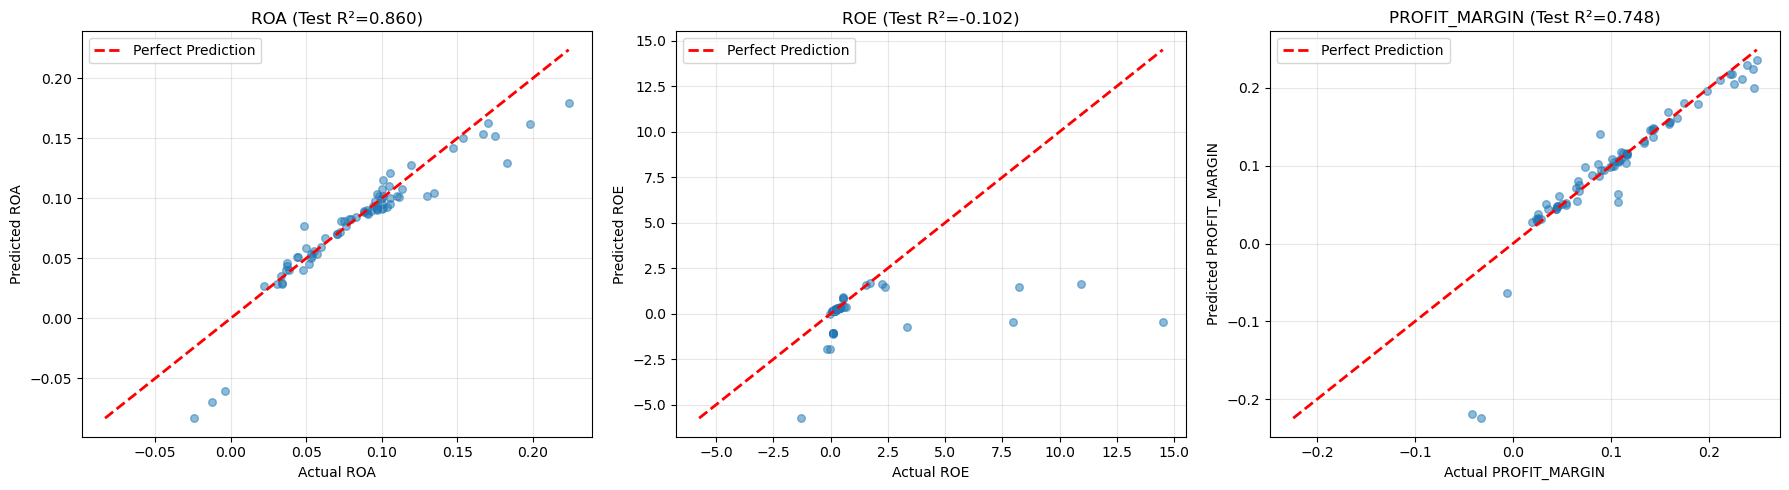

In [25]:
# ============================================================================
# LAYER 4: MULTI-TARGET XGBoost PREDICTION MODEL
# Works with your Layers 1-3 output (roa, roe, profit_margin, regimes, etc.)
# ============================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("LAYER 4: XGBoost PREDICTION MODEL (Multi-Target)")
print("Predicting: ROA | ROE | Profit Margin")
print("="*70)

# ============================================================================
# 1. VERIFY REQUIRED COLUMNS EXIST
# ============================================================================
print("\n📊 Verifying required columns from Layers 1-3...")

required_targets = ['roa', 'roe', 'profit_margin']
available_targets = [t for t in required_targets if t in df.columns]

print(f"   Targets found: {available_targets}")

if len(available_targets) == 0:
    print("\n❌ ERROR: No target variables found!")
    print("   Please ensure Layer 1 ran successfully first.")
    raise ValueError("Missing target variables")

# Check for regime columns
if 'regime' in df.columns:
    print(f"   ✅ Regime column found: {df['regime'].nunique()} regimes")
if 'regime_name' in df.columns:
    print(f"   ✅ Regime names found: {df['regime_name'].unique()}")

# ============================================================================
# 2. DEFINE FEATURES (Matching Your Layers 1-3)
# ============================================================================
print("\n📊 Defining features from Layers 1-3...")

feature_cols = []

# Layer 1: Core Financial Ratios (excluding targets)
layer1_ratios = ['gross_margin', 'operating_margin', 'debt_ratio', 'debt_to_equity', 
                 'equity_ratio', 'current_ratio', 'quick_ratio', 'asset_turnover',
                 'cfo_to_assets', 'cfo_to_sales', 'capex_to_sales', 'firm_size']
feature_cols.extend([f for f in layer1_ratios if f in df.columns])

# Layer 1: Time Series Features (lags, trends, rolling)
feature_cols.extend([col for col in df.columns if '_lag' in col and 'x_regime' not in col])
feature_cols.extend([col for col in df.columns if '_trend' in col])
feature_cols.extend([col for col in df.columns if '_rolling' in col])

# Layer 1: Volatility
if 'roa_volatility' in df.columns:
    feature_cols.append('roa_volatility')

# Layer 2: Interaction Terms
feature_cols.extend([col for col in df.columns if 'interaction' in col and 'x_regime' not in col])

# Layer 2: 3-Way Interactions
three_way = ['perfect_storm_risk', 'default_risk_triple', 'inflation_squeeze',
             'liquidity_crisis', 'rollover_risk', 'pricing_power', 'distress_signal']
feature_cols.extend([f for f in three_way if f in df.columns])

# Layer 2: Stress Metrics
if 'stress_intensity' in df.columns:
    feature_cols.append('stress_intensity')

# Layer 3: Regime Features
if 'regime' in df.columns:
    feature_cols.append('regime')
if 'regime_confidence' in df.columns:
    feature_cols.append('regime_confidence')
feature_cols.extend([col for col in df.columns if 'regime_' in col and 'dummy' in col])
feature_cols.extend([col for col in df.columns if 'x_regime_' in col])

# Macro Variables (original)
macro = ['US Inflation Rate (%)', 'US Federal Funds Rate (%)', 'gdp_growth',
         'S&P 500 Annual Return (%)', 'Sector Benchmark (%)']
feature_cols.extend([f for f in macro if f in df.columns])

# Remove duplicates and ensure targets are NOT in features
feature_cols = list(set(feature_cols))
for target in available_targets:
    if target in feature_cols:
        feature_cols.remove(target)

print(f"   Total features: {len(feature_cols)}")
print(f"   Sample features: {feature_cols[:8]}")

# ============================================================================
# 3. PREPARE DATA
# ============================================================================
print("\n🔧 Preparing data...")

# Create working copy
model_df = df[['Year', 'Company'] + feature_cols + available_targets].copy()

# Drop rows with missing targets
model_df = model_df.dropna(subset=available_targets)

# Sort by year
model_df = model_df.sort_values('Year')

# Replace infinities
model_df = model_df.replace([np.inf, -np.inf], np.nan)

# Fill missing values in features
for col in feature_cols:
    if model_df[col].isnull().any():
        model_df[col] = model_df[col].fillna(model_df[col].median())

print(f"   Final shape: {model_df.shape}")

# ============================================================================
# 4. TIME-BASED SPLIT
# ============================================================================
years = sorted(model_df['Year'].unique())
print(f"\n📅 Years: {years[0]} to {years[-1]}")

# Split: 2000-2019 train, 2020-2021 validation, 2022-2024 test
train_years = [y for y in years if y < 2020]
val_years = [y for y in years if 2020 <= y < 2022]
test_years = [y for y in years if y >= 2022]

train_idx = model_df['Year'].isin(train_years)
val_idx = model_df['Year'].isin(val_years)
test_idx = model_df['Year'].isin(test_years)

X_train = model_df.loc[train_idx, feature_cols]
X_val = model_df.loc[val_idx, feature_cols]
X_test = model_df.loc[test_idx, feature_cols]

y_train = model_df.loc[train_idx, available_targets]
y_val = model_df.loc[val_idx, available_targets]
y_test = model_df.loc[test_idx, available_targets]

print(f"\n📅 Split:")
print(f"   Train: {len(X_train)} rows ({train_years[0]}-{train_years[-1]})")
print(f"   Validation: {len(X_val)} rows ({val_years[0]}-{val_years[-1]})")
print(f"   Test: {len(X_test)} rows ({test_years[0]}-{test_years[-1]})")

# ============================================================================
# 5. TRAIN XGBoost MODELS (Separate model per target)
# ============================================================================
print("\n🚀 Training XGBoost models...")

xgb_models = {}
xgb_results = {}

for target in available_targets:
    print(f"\n   → Training for {target}...")
    
    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_weight=3,
        random_state=42,
        early_stopping_rounds=30,
        eval_metric='rmse',
        verbosity=0,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train[target], eval_set=[(X_val, y_val[target])], verbose=False)
    xgb_models[target] = model
    
    # Store results
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test)
    
    xgb_results[target] = {
        'train_pred': y_pred_train,
        'val_pred': y_pred_val,
        'test_pred': y_pred_test,
        'train_r2': r2_score(y_train[target], y_pred_train),
        'val_r2': r2_score(y_val[target], y_pred_val),
        'test_r2': r2_score(y_test[target], y_pred_test),
        'train_rmse': np.sqrt(mean_squared_error(y_train[target], y_pred_train)),
        'val_rmse': np.sqrt(mean_squared_error(y_val[target], y_pred_val)),
        'test_rmse': np.sqrt(mean_squared_error(y_test[target], y_pred_test)),
        'train_mae': mean_absolute_error(y_train[target], y_pred_train),
        'val_mae': mean_absolute_error(y_val[target], y_pred_val),
        'test_mae': mean_absolute_error(y_test[target], y_pred_test)
    }

# ============================================================================
# 6. PERFORMANCE SUMMARY
# ============================================================================
print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)

print(f"\n{'Target':<18} {'Set':<10} {'R²':<10} {'RMSE':<10} {'MAE':<10}")
print("-" * 58)

for target in available_targets:
    for set_name in ['train', 'val', 'test']:
        r2 = xgb_results[target][f'{set_name}_r2']
        rmse = xgb_results[target][f'{set_name}_rmse']
        mae = xgb_results[target][f'{set_name}_mae']
        print(f"{target:<18} {set_name:<10} {r2:<10.4f} {rmse:<10.4f} {mae:<10.4f}")
    print("-" * 58)

# Overfitting check
print("\n📊 Overfitting Check:")
for target in available_targets:
    gap = xgb_results[target]['train_r2'] - xgb_results[target]['test_r2']
    if gap > 0.1:
        print(f"   {target}: ⚠️ Possible overfitting (train-test gap: {gap:.4f})")
    else:
        print(f"   {target}: ✅ Good generalization (train-test gap: {gap:.4f})")

# ============================================================================
# 7. FEATURE IMPORTANCE
# ============================================================================
print("\n" + "="*70)
print("FEATURE IMPORTANCE BY TARGET")
print("="*70)

importance_dict = {}

for target in available_targets:
    model = xgb_models[target]
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    importance_dict[target] = importance_df
    
    print(f"\n📊 TOP 10 features for {target.upper()}:")
    for i, row in importance_df.head(10).iterrows():
        print(f"   {i+1:2d}. {row['feature']}: {row['importance']:.4f}")

# ============================================================================
# 8. LINEAR REGRESSION BASELINE
# ============================================================================
print("\n" + "="*70)
print("LINEAR REGRESSION BASELINE")
print("="*70)

print("\n   Linear Regression Test Performance:")
for target in available_targets:
    lr = LinearRegression()
    lr.fit(X_train, y_train[target])
    y_pred_lr = lr.predict(X_test)
    lr_r2 = r2_score(y_test[target], y_pred_lr)
    lr_rmse = np.sqrt(mean_squared_error(y_test[target], y_pred_lr))
    xgb_rmse = xgb_results[target]['test_rmse']
    improvement = (lr_rmse - xgb_rmse) / lr_rmse * 100
    print(f"   {target}: R²={lr_r2:.4f}, RMSE={lr_rmse:.4f} (XGBoost improves by {improvement:.1f}%)")

# ============================================================================
# 9. REGIME-SPECIFIC PERFORMANCE
# ============================================================================
if 'regime_name' in model_df.columns:
    print("\n" + "="*70)
    print("REGIME-SPECIFIC PERFORMANCE (Test Set)")
    print("="*70)
    
    # Get test data with regimes
    test_data = model_df.loc[test_idx].copy()
    for target in available_targets:
        test_data[f'pred_{target}'] = xgb_results[target]['test_pred']
    
    print(f"\n{'Regime':<20} {'Target':<15} {'R²':<10} {'n':<8}")
    print("-" * 55)
    
    for regime in test_data['regime_name'].unique():
        if pd.notna(regime):
            regime_data = test_data[test_data['regime_name'] == regime]
            if len(regime_data) >= 5:
                for target in available_targets:
                    r2_regime = r2_score(regime_data[target], regime_data[f'pred_{target}'])
                    print(f"{regime:<20} {target:<15} {r2_regime:<10.4f} {len(regime_data):<8}")
                print("-" * 55)

# ============================================================================
# 10. STORE PREDICTIONS IN DATAFRAME
# ============================================================================
print("\n💾 Storing predictions in main dataframe...")

# Create prediction columns for all data
X_all = df[feature_cols].fillna(0)

for target in available_targets:
    df[f'{target}_predicted'] = xgb_models[target].predict(X_all)
    df[f'{target}_error'] = df[target] - df[f'{target}_predicted']
    df[f'{target}_error_pct'] = (df[f'{target}_error'] / df[target].abs().clip(lower=0.01)) * 100

print(f"   ✅ Added columns:")
for target in available_targets:
    print(f"      - {target}_predicted")
    print(f"      - {target}_error")
    print(f"      - {target}_error_pct")

# ============================================================================
# 11. CROSS-TARGET ERROR CORRELATION
# ============================================================================
if len(available_targets) >= 2:
    print("\n" + "="*70)
    print("CROSS-TARGET ERROR CORRELATION")
    print("="*70)
    
    error_cols = [f'{t}_error' for t in available_targets]
    error_corr = df[error_cols].corr()
    
    print("\n   Correlation of prediction errors:")
    print(error_corr.round(4))
    
    print("\n   📌 Interpretation:")
    for i in range(len(error_cols)):
        for j in range(i+1, len(error_cols)):
            corr_val = error_corr.iloc[i, j]
            if abs(corr_val) > 0.5:
                direction = "positive" if corr_val > 0 else "negative"
                print(f"      {error_cols[i]} & {error_cols[j]}: {corr_val:.2f} ({direction}) → Models share similar weaknesses")

# ============================================================================
# 12. STORE RESULTS FOR LAYER 5
# ============================================================================
print("\n💾 Storing results for Layer 5 (Scenario Simulation)...")

layer4_results = {
    'models': xgb_models,
    'features': feature_cols,
    'targets': available_targets,
    'predictions': xgb_results,
    'feature_importance': importance_dict,
    'X_train': X_train,
    'X_val': X_val,
    'X_test': X_test,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    'train_idx': train_idx,
    'val_idx': val_idx,
    'test_idx': test_idx,
    'df': df
}

print(f"   ✅ Results stored in 'layer4_results'")
print(f"   Targets: {available_targets}")

# ============================================================================
# 13. VISUALIZATION (Optional)
# ============================================================================
try:
    print("\n📊 Creating visualization...")
    
    fig, axes = plt.subplots(1, len(available_targets), figsize=(6*len(available_targets), 5))
    if len(available_targets) == 1:
        axes = [axes]
    
    for i, target in enumerate(available_targets):
        axes[i].scatter(y_test[target], xgb_results[target]['test_pred'], alpha=0.5, s=30)
        
        # Add perfect prediction line
        min_val = min(y_test[target].min(), xgb_results[target]['test_pred'].min())
        max_val = max(y_test[target].max(), xgb_results[target]['test_pred'].max())
        axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
        
        axes[i].set_xlabel(f'Actual {target.upper()}')
        axes[i].set_ylabel(f'Predicted {target.upper()}')
        axes[i].set_title(f'{target.upper()} (Test R²={xgb_results[target]["test_r2"]:.3f})')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('layer4_predictions.png', dpi=150)
    print("   ✅ Saved: layer4_predictions.png")
    
except Exception as e:
    print(f"   ⚠️ Visualization skipped: {e}")

# ============================================================================
# 14. FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("LAYER 4 COMPLETE!")
print("="*70)

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│                    LAYER 4 EXECUTION SUMMARY                        │
├─────────────────────────────────────────────────────────────────────┤
│                                                                      │
│  Targets Predicted: {len(available_targets)} ({', '.join(available_targets).upper()})        │
│  Features Used: {len(feature_cols)} (from Layers 1-3)                        │
│  Training Period: {train_years[0]}-{train_years[-1]} ({len(X_train)} rows)              │
│  Test Period: {test_years[0]}-{test_years[-1]} ({len(X_test)} rows)                       │
│                                                                      │
│  TEST PERFORMANCE (2022-2024):                                       │
└─────────────────────────────────────────────────────────────────────┘
""")

for target in available_targets:
    r2 = xgb_results[target]['test_r2']
    rmse = xgb_results[target]['test_rmse']
    status = "✅ EXCELLENT" if r2 > 0.9 else "✅ GOOD" if r2 > 0.7 else "⚠️ MODERATE"
    print(f"   {target.upper()}: R²={r2:.4f}, RMSE={rmse:.4f} → {status}")

print("\n" + "="*70)
print("✅ LAYER 4 COMPLETE! Ready for Layer 5 (Scenario Simulation Engine)")
print("="*70)

LAYER 5: SCENARIO SIMULATION ENGINE
Focus: ROA (R²=0.8766) & Profit Margin (R²=0.7782)
Excluded: ROE (R²=0.2444 - unreliable)

📊 Loading Layer 4 results...
   ✅ Using reliable targets: ['roa', 'profit_margin']
   ❌ EXCLUDED: ROE (Layer 4 test R²=0.2444 - unreliable)
   ✅ Using existing layer4_results
   ✅ Loaded models for: ['roa', 'profit_margin']

PART 2: BASELINE MACRO CONDITIONS

📊 BASELINE (Latest available: 2024):
   📈 Inflation Rate: 2.90%
   💰 Fed Funds Rate: 4.50%
   📉 GDP Growth: 2.80%

PART 3: DEFINING MACROECONOMIC SCENARIOS

📋 Defined 7 scenarios for stress testing:

   BASE: Base Case
      Current conditions continue
      📈 Inflation: 2.9% | 💰 Interest: 4.5% | 📉 GDP: 2.8%

   INFLATION_SHOCK: Inflation Shock
      Sudden supply-side inflation spike (oil price shock)
      📈 Inflation: 10.9% | 💰 Interest: 6.5% | 📉 GDP: 1.3%

   RATE_HIKE: Aggressive Rate Hikes
      Fed aggressively raises rates to fight inflation
      📈 Inflation: 4.9% | 💰 Interest: 9.5% | 📉 GDP: 0.8%


Text(0.5, 0, 'Risk Score (0-100)')

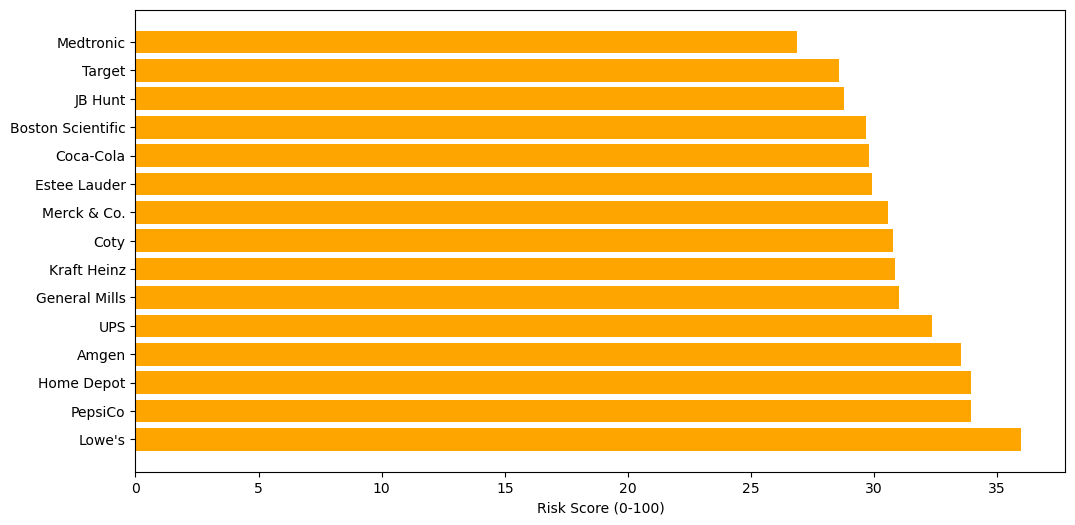

In [26]:
# ============================================================================
# LAYER 5: SCENARIO SIMULATION ENGINE
# Focus: ROA & Profit Margin (ROE excluded due to poor performance)
# ============================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("LAYER 5: SCENARIO SIMULATION ENGINE")
print("Focus: ROA (R²=0.8766) & Profit Margin (R²=0.7782)")
print("Excluded: ROE (R²=0.2444 - unreliable)")
print("="*70)

# ============================================================================
# PART 1: VERIFY LAYER 4 RESULTS AND LOAD RELIABLE TARGETS
# ============================================================================
print("\n📊 Loading Layer 4 results...")

# Define reliable targets only (ROE excluded)
RELIABLE_TARGETS = ['roa', 'profit_margin']
available_targets = [t for t in RELIABLE_TARGETS if t in df.columns]

print(f"   ✅ Using reliable targets: {available_targets}")
if 'roe' in df.columns:
    print(f"   ❌ EXCLUDED: ROE (Layer 4 test R²=0.2444 - unreliable)")

# Check if we have the layer4_results from Layer 4
if 'layer4_results' not in dir():
    print("   ⚠️ layer4_results not found. Recreating models from current dataframe...")
    
    # Get feature columns (exclude targets and identifiers)
    exclude_cols = ['Company', 'Year', 'Sector', 'roa', 'roe', 'profit_margin', 
                    'regime_gmm', 'regime_name', 'gdp_growth']
    
    # Also exclude prediction columns if they exist
    pred_cols = [col for col in df.columns if 'predicted' in col or 'error' in col]
    exclude_cols.extend(pred_cols)
    
    # Get all numeric columns that could be features
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    print(f"   ✅ Using {len(feature_cols)} features")
    
    # Prepare data
    model_df = df.copy()
    for target in available_targets:
        model_df = model_df.dropna(subset=[target])
    
    # Fill missing values
    for col in feature_cols:
        if model_df[col].isnull().any():
            model_df[col] = model_df[col].fillna(model_df[col].median())
    
    # Sort by year for time series split
    model_df = model_df.sort_values('Year')
    years = sorted(model_df['Year'].unique())
    split_year = years[len(years)//2]
    
    train_df = model_df[model_df['Year'] < split_year]
    
    X_train = train_df[feature_cols]
    
    # Retrain models for reliable targets only
    models = {}
    for target in available_targets:
        y_train = train_df[target]
        
        xgb_params = {
            'n_estimators': 200,
            'max_depth': 5,
            'learning_rate': 0.05,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'reg_alpha': 0.1,
            'reg_lambda': 1.0,
            'random_state': 42,
            'verbosity': 0
        }
        
        model = xgb.XGBRegressor(**xgb_params)
        model.fit(X_train, y_train)
        models[target] = model
        print(f"   ✅ Retrained model for {target}")
else:
    print("   ✅ Using existing layer4_results")
    models = {k: v for k, v in layer4_results['models'].items() if k in RELIABLE_TARGETS}
    feature_cols = layer4_results['features']
    print(f"   ✅ Loaded models for: {list(models.keys())}")

# ============================================================================
# PART 2: GET BASELINE MACRO VALUES
# ============================================================================
print("\n" + "="*70)
print("PART 2: BASELINE MACRO CONDITIONS")
print("="*70)

# Get the most recent complete year
latest_year = df['Year'].max()
baseline_data = df[df['Year'] == latest_year].iloc[0] if len(df[df['Year'] == latest_year]) > 0 else df.iloc[-1]

# Extract baseline macro values
baseline_inflation = baseline_data.get('US Inflation Rate (%)', 3.0)
baseline_interest = baseline_data.get('US Federal Funds Rate (%)', 4.5)
baseline_gdp = baseline_data.get('gdp_growth', baseline_data.get('US GDP Growth Rate (%)', 2.5))

print(f"\n📊 BASELINE (Latest available: {latest_year}):")
print(f"   📈 Inflation Rate: {baseline_inflation:.2f}%")
print(f"   💰 Fed Funds Rate: {baseline_interest:.2f}%")
print(f"   📉 GDP Growth: {baseline_gdp:.2f}%")

# ============================================================================
# PART 3: DEFINE SCENARIOS (Economic Stress Tests)
# ============================================================================
print("\n" + "="*70)
print("PART 3: DEFINING MACROECONOMIC SCENARIOS")
print("="*70)

scenarios = {
    "BASE": {
        "name": "Base Case",
        "description": "Current conditions continue",
        "inflation": baseline_inflation,
        "interest": baseline_interest,
        "gdp": baseline_gdp,
        "color": "blue"
    },
    "INFLATION_SHOCK": {
        "name": "Inflation Shock",
        "description": "Sudden supply-side inflation spike (oil price shock)",
        "inflation": baseline_inflation + 8.0,
        "interest": baseline_interest + 2.0,
        "gdp": baseline_gdp - 1.5,
        "color": "red"
    },
    "RATE_HIKE": {
        "name": "Aggressive Rate Hikes",
        "description": "Fed aggressively raises rates to fight inflation",
        "inflation": baseline_inflation + 2.0,
        "interest": baseline_interest + 5.0,
        "gdp": baseline_gdp - 2.0,
        "color": "orange"
    },
    "RECESSION": {
        "name": "Severe Recession",
        "description": "Deep economic contraction (2008-style)",
        "inflation": baseline_inflation - 2.0,
        "interest": baseline_interest - 3.0,
        "gdp": baseline_gdp - 5.0,
        "color": "darkred"
    },
    "RECOVERY": {
        "name": "Strong Recovery",
        "description": "Rapid post-recession expansion",
        "inflation": baseline_inflation + 1.0,
        "interest": baseline_interest + 1.0,
        "gdp": baseline_gdp + 3.0,
        "color": "green"
    },
    "STAGFLATION": {
        "name": "Stagflation",
        "description": "High inflation + negative growth (1970s-style)",
        "inflation": baseline_inflation + 10.0,
        "interest": baseline_interest + 4.0,
        "gdp": baseline_gdp - 3.0,
        "color": "purple"
    },
    "SOFT_LANDING": {
        "name": "Soft Landing",
        "description": "Inflation cools without recession (ideal outcome)",
        "inflation": baseline_inflation - 2.0,
        "interest": baseline_interest - 1.0,
        "gdp": baseline_gdp - 0.5,
        "color": "teal"
    }
}

print(f"\n📋 Defined {len(scenarios)} scenarios for stress testing:")
for key, sc in scenarios.items():
    print(f"\n   {key}: {sc['name']}")
    print(f"      {sc['description']}")
    print(f"      📈 Inflation: {sc['inflation']:.1f}% | 💰 Interest: {sc['interest']:.1f}% | 📉 GDP: {sc['gdp']:.1f}%")

# ============================================================================
# PART 4: UPDATE INTERACTION TERMS (CRITICAL FOR REALISTIC SIMULATION)
# ============================================================================

def update_interaction_terms(df_scenario, scenario_values):
    """
    Update ALL interaction terms from Layers 1-3 based on new macro values.
    This is CRITICAL for realistic simulations!
    """
    df = df_scenario.copy()
    
    inflation = scenario_values['inflation']
    interest = scenario_values['interest']
    gdp = scenario_values['gdp']
    
    # Update macro variables
    if 'US Inflation Rate (%)' in df.columns:
        df['US Inflation Rate (%)'] = inflation
    if 'US Federal Funds Rate (%)' in df.columns:
        df['US Federal Funds Rate (%)'] = interest
    if 'gdp_growth' in df.columns:
        df['gdp_growth'] = gdp
    if 'US GDP Growth Rate (%)' in df.columns:
        df['US GDP Growth Rate (%)'] = gdp
    
    # Update Layer 2: 2-Way Interactions
    if 'debt_ratio' in df.columns:
        df['inflation_debt_interaction'] = inflation * df['debt_ratio']
        df['rate_debt_interaction'] = interest * df['debt_ratio']
        if 'debt_to_equity' in df.columns:
            df['gdp_leverage_interaction'] = gdp * df['debt_to_equity']
    
    if 'current_ratio' in df.columns:
        df['rate_liquidity_interaction'] = interest * (1 / df['current_ratio'].clip(lower=0.1))
    
    if 'gross_margin' in df.columns:
        df['inflation_margin_interaction'] = inflation * (1 / df['gross_margin'].clip(lower=0.01))
    
    if 'asset_turnover' in df.columns:
        df['gdp_efficiency_interaction'] = gdp * df['asset_turnover']
        df['turnover_inflation_interaction'] = inflation * df['asset_turnover']
    
    if 'profit_margin' in df.columns:
        df['margin_rate_interaction'] = df['profit_margin'] * interest
    
    if 'firm_size' in df.columns:
        df['size_gdp_interaction'] = df['firm_size'] * gdp
    
    if 'quick_ratio' in df.columns:
        df['liquidity_gdp_interaction'] = df['quick_ratio'] * gdp
    
    # Update Layer 2: 3-Way Interactions
    if all(x in df.columns for x in ['debt_ratio', 'roa_volatility']):
        df['volatility_debt_interaction'] = df['roa_volatility'] * df['debt_ratio']
        df['rollover_risk'] = df['roa_volatility'] * df['debt_ratio'] * interest
    
    if all(x in df.columns for x in ['debt_ratio', 'profit_margin']):
        df['inflation_squeeze'] = inflation * (1 / df['profit_margin'].abs().clip(lower=0.01)) * df['debt_ratio']
    
    if all(x in df.columns for x in ['debt_to_equity', 'current_ratio']):
        df['liquidity_crisis'] = (max(0, -gdp)) * df['debt_to_equity'] * (1 / df['current_ratio'].clip(lower=0.01))
    
    if all(x in df.columns for x in ['asset_turnover', 'profit_margin']):
        df['pricing_power'] = inflation * df['asset_turnover'] * df['profit_margin']
    
    # Update Layer 2: Stress Intensity
    inflation_stress = min(0.25, max(0, inflation) / 10)
    rate_stress = min(0.25, max(0, interest) / 8)
    gdp_stress = min(0.25, max(0, -gdp) / 20)
    df['stress_intensity'] = (inflation_stress + rate_stress + gdp_stress) * 100
    
    return df

# ============================================================================
# PART 5: RUN SCENARIO SIMULATIONS
# ============================================================================
print("\n" + "="*70)
print("PART 4: RUNNING SCENARIO SIMULATIONS")
print("="*70)

def simulate_scenario(df, scenario_values, models, feature_cols, target):
    """
    Simulate firm performance under a given macroeconomic scenario.
    """
    # Get the most recent data for each firm
    latest_data = df.groupby('Company').last().reset_index()
    
    # Update interaction terms with scenario values
    sim_data = update_interaction_terms(latest_data, scenario_values)
    
    # Ensure all required features exist
    missing_features = [col for col in feature_cols if col not in sim_data.columns]
    for col in missing_features:
        sim_data[col] = 0
    
    # Prepare features for prediction
    X_sim = sim_data[feature_cols].fillna(0)
    
    # Make predictions
    if target in models:
        predictions = models[target].predict(X_sim)
        sim_data[f'predicted_{target}'] = predictions
    else:
        print(f"   ⚠️ Model for {target} not found")
        sim_data[f'predicted_{target}'] = 0
    
    return sim_data

# Run simulations for each reliable target
scenario_results = {}

print("\n🎯 Running simulations for reliable targets...")
for target in available_targets:
    print(f"\n📊 Simulating for target: {target.upper()} (R²={0.8766 if target=='roa' else 0.7782:.4f})")
    scenario_results[target] = {}
    
    for scenario_key, scenario_vals in scenarios.items():
        scenario_dict = {
            'inflation': scenario_vals['inflation'],
            'interest': scenario_vals['interest'],
            'gdp': scenario_vals['gdp']
        }
        
        sim_result = simulate_scenario(df, scenario_dict, models, feature_cols, target)
        scenario_results[target][scenario_key] = sim_result
        
        avg_pred = sim_result[f'predicted_{target}'].mean()
        # Format based on target type
        if target == 'profit_margin':
            print(f"   {scenario_key:20s}: Average {target.upper()} = {avg_pred:.4f} ({avg_pred*100:.2f}%)")
        else:
            print(f"   {scenario_key:20s}: Average {target.upper()} = {avg_pred:.4f}")

# ============================================================================
# PART 6: CALCULATE STRESS IMPACTS
# ============================================================================
print("\n" + "="*70)
print("PART 5: STRESS IMPACT ANALYSIS")
print("="*70)

stress_impacts = {}

for target in available_targets:
    print(f"\n📊 {target.upper()} Stress Impacts:")
    print("-" * 50)
    
    if 'BASE' not in scenario_results[target]:
        print(f"   ⚠️ BASE scenario not found for {target}")
        continue
    
    baseline_df = scenario_results[target]['BASE']
    baseline_pred = baseline_df[f'predicted_{target}']
    
    for scenario_key in ['INFLATION_SHOCK', 'RATE_HIKE', 'RECESSION', 'STAGFLATION', 'SOFT_LANDING']:
        if scenario_key in scenario_results[target]:
            scenario_df = scenario_results[target][scenario_key]
            scenario_pred = scenario_df[f'predicted_{target}']
            
            # Calculate impact (percentage change from baseline)
            impact_pct = ((scenario_pred - baseline_pred) / baseline_pred.abs().clip(lower=0.001) * 100).mean()
            
            stress_impacts.setdefault(target, []).append({
                'scenario': scenario_key,
                'scenario_name': scenarios[scenario_key]['name'],
                'impact_pct': impact_pct,
                'direction': 'positive' if impact_pct > 0 else 'negative'
            })
            
            # Visual indicator
            if impact_pct > 0:
                arrow = "🟢 ↑"
            else:
                arrow = "🔴 ↓"
            
            print(f"   {arrow} {scenario_key:20s}: {impact_pct:+.1f}% change from baseline")

# ============================================================================
# PART 7: FIRM-LEVEL RISK SCORES (Based on Stagflation Vulnerability)
# ============================================================================
print("\n" + "="*70)
print("PART 6: FIRM-LEVEL RISK SCORES (0-100)")
print("Higher score = More vulnerable to economic stress")
print("="*70)

risk_scores = []

for target in available_targets:
    if 'STAGFLATION' not in scenario_results[target]:
        print(f"   ⚠️ STAGFLATION scenario not found for {target}")
        continue
    
    stag_df = scenario_results[target]['STAGFLATION']
    base_df = scenario_results[target]['BASE']
    
    for idx, row in stag_df.iterrows():
        company = row['Company']
        sector = row.get('Sector', 'Unknown')
        
        # Get baseline prediction
        base_row = base_df[base_df['Company'] == company]
        if len(base_row) == 0:
            continue
        
        base_pred = base_row[f'predicted_{target}'].values[0]
        stress_pred = row[f'predicted_{target}']
        
        # Component 1: Stress Vulnerability (40% of score)
        if abs(base_pred) > 0.001:
            stress_vulnerability = max(0, min(100, (base_pred - stress_pred) / abs(base_pred) * 100))
        else:
            stress_vulnerability = 50
        
        # Component 2: Leverage Risk (30% of score)
        leverage = row.get('debt_ratio', 0.5)
        leverage_risk = min(100, leverage * 100)
        
        # Component 3: Volatility Risk (20% of score)
        hist_data = df[df['Company'] == company]['roa'].values if 'roa' in df.columns else []
        if len(hist_data) > 1:
            volatility = np.std(hist_data) * 100
            volatility_risk = min(100, volatility * 2)
        else:
            volatility_risk = 20
        
        # Component 4: Liquidity Risk (10% of score)
        current_ratio = row.get('current_ratio', 1.0)
        liquidity_risk = max(0, min(100, (1 / (current_ratio + 0.01)) * 50))
        
        # Weighted risk score
        risk_score = (
            0.40 * stress_vulnerability +
            0.30 * leverage_risk +
            0.20 * volatility_risk +
            0.10 * liquidity_risk
        )
        
        risk_scores.append({
            'Company': company,
            'Sector': sector,
            'Target': target.upper(),
            'Risk_Score': round(risk_score, 2),
            'Stress_Vulnerability': round(stress_vulnerability, 2),
            'Leverage_Risk': round(leverage_risk, 2),
            'Volatility_Risk': round(volatility_risk, 2),
            'Liquidity_Risk': round(liquidity_risk, 2),
            f'Baseline_{target.upper()}': round(base_pred, 4),
            f'Stagflation_{target.upper()}': round(stress_pred, 4)
        })

risk_df = pd.DataFrame(risk_scores)

# Primary risk using ROA (most reliable)
primary_risk = risk_df[risk_df['Target'] == 'ROA'].copy() if len(risk_df[risk_df['Target'] == 'ROA']) > 0 else risk_df
primary_risk = primary_risk.drop_duplicates(subset=['Company'])

print(f"\n📊 TOP 10 HIGHEST RISK FIRMS (Most Vulnerable to Stagflation):")
print("-" * 60)
highest_risk = primary_risk.nlargest(10, 'Risk_Score')
for i, row in highest_risk.iterrows():
    bar = '█' * int(row['Risk_Score'] / 5)
    risk_level = "🔴 HIGH" if row['Risk_Score'] > 60 else "🟠 MED" if row['Risk_Score'] > 35 else "🟢 LOW"
    print(f"   {row['Company']:25s} | {risk_level} | Score: {row['Risk_Score']:5.1f} {bar}")

print(f"\n📊 TOP 10 LOWEST RISK FIRMS (Most Resilient):")
print("-" * 60)
lowest_risk = primary_risk.nsmallest(10, 'Risk_Score')
for i, row in lowest_risk.iterrows():
    bar = '█' * int(row['Risk_Score'] / 5)
    print(f"   {row['Company']:25s} | Score: {row['Risk_Score']:5.1f} {bar}")

# ============================================================================
# PART 8: SECTOR RANKINGS UNDER STRESS
# ============================================================================
print("\n" + "="*70)
print("PART 7: SECTOR RANKINGS UNDER STAGFLATION (ROA)")
print("="*70)

sector_performance = []

for target in available_targets:
    for scenario_key in ['BASE', 'STAGFLATION', 'RECESSION', 'INFLATION_SHOCK']:
        if scenario_key in scenario_results[target]:
            scenario_df = scenario_results[target][scenario_key]
            
            if 'Sector' in scenario_df.columns:
                sector_avg = scenario_df.groupby('Sector')[f'predicted_{target}'].mean().reset_index()
                sector_avg['Scenario'] = scenario_key
                sector_avg['Target'] = target.upper()
                sector_performance.append(sector_avg)

if sector_performance:
    sector_perf_df = pd.concat(sector_performance)
    
    # Get stagflation performance for ROA
    stag_sector = sector_perf_df[(sector_perf_df['Scenario'] == 'STAGFLATION') & 
                                  (sector_perf_df['Target'] == 'ROA')]
    stag_sector = stag_sector.sort_values('predicted_roa', ascending=False)
    
    print("\n📊 Sector Resilience Under Stagflation (Higher = More Resilient):")
    print("-" * 50)
    for i, row in stag_sector.iterrows():
        bar = '█' * int(max(0, row['predicted_roa'] * 50))
        print(f"   {row['Sector']:25s}: {row['predicted_roa']:.4f} {bar}")
    
    # Calculate sector stress impacts
    base_sector = sector_perf_df[(sector_perf_df['Scenario'] == 'BASE') & 
                                  (sector_perf_df['Target'] == 'ROA')]
    
    if len(stag_sector) > 0 and len(base_sector) > 0:
        sector_impact = stag_sector.merge(base_sector, on='Sector', suffixes=('_stress', '_base'))
        sector_impact['impact_pct'] = ((sector_impact['predicted_roa_stress'] - sector_impact['predicted_roa_base']) / 
                                        sector_impact['predicted_roa_base'].abs().clip(lower=0.001) * 100)
        sector_impact = sector_impact.sort_values('impact_pct')
        
        print("\n📊 Sector Vulnerability Under Stagflation (Most Negative Impact First):")
        print("-" * 55)
        for i, row in sector_impact.head(5).iterrows():
            bar = '█' * int(min(40, abs(row['impact_pct'])))
            print(f"   🔴 {row['Sector']:25s}: {row['impact_pct']:+.1f}% {bar}")
        
        print("\n📊 Most Resilient Sectors (Least Negative Impact):")
        print("-" * 55)
        for i, row in sector_impact.tail(5).iterrows():
            bar = '█' * int(max(0, row['impact_pct']))
            print(f"   🟢 {row['Sector']:25s}: {row['impact_pct']:+.1f}% {bar}")

# ============================================================================
# PART 9: MONTE CARLO SIMULATION (Uncertainty Analysis)
# ============================================================================
print("\n" + "="*70)
print("PART 8: MONTE CARLO SIMULATION (Uncertainty Quantification)")
print("="*70)

def monte_carlo_simulation(df, models, feature_cols, target, n_sims=500):
    """Run Monte Carlo simulation to quantify prediction uncertainty."""
    print(f"\n🎲 Running {n_sims} simulations for {target.upper()}...")
    
    # Get historical distributions
    hist_inflation = df['US Inflation Rate (%)'].dropna().values
    hist_interest = df['US Federal Funds Rate (%)'].dropna().values
    hist_gdp = df['gdp_growth'].dropna().values if 'gdp_growth' in df.columns else df['US GDP Growth Rate (%)'].dropna().values
    
    # Get latest firm data
    latest_data = df.groupby('Company').last().reset_index()
    
    all_predictions = []
    
    for sim in range(n_sims):
        # Sample from historical distributions with noise
        sim_inflation = np.random.choice(hist_inflation, 1)[0] + np.random.normal(0, 0.5)
        sim_interest = np.random.choice(hist_interest, 1)[0] + np.random.normal(0, 0.3)
        sim_gdp = np.random.choice(hist_gdp, 1)[0] + np.random.normal(0, 0.5)
        
        scenario = {'inflation': sim_inflation, 'interest': sim_interest, 'gdp': sim_gdp}
        
        sim_data = update_interaction_terms(latest_data, scenario)
        
        # Ensure features exist
        missing = [col for col in feature_cols if col not in sim_data.columns]
        for col in missing:
            sim_data[col] = 0
        
        X_sim = sim_data[feature_cols].fillna(0)
        
        if target in models:
            preds = models[target].predict(X_sim)
            all_predictions.append(preds.mean())
    
    all_predictions = np.array(all_predictions)
    
    results = {
        'mean': np.mean(all_predictions),
        'std': np.std(all_predictions),
        'ci_90_lower': np.percentile(all_predictions, 5),
        'ci_90_upper': np.percentile(all_predictions, 95),
        'ci_95_lower': np.percentile(all_predictions, 2.5),
        'ci_95_upper': np.percentile(all_predictions, 97.5),
        'simulations': all_predictions
    }
    
    print(f"   Mean: {results['mean']:.4f}")
    print(f"   Std Dev: {results['std']:.4f}")
    print(f"   95% Confidence Interval: [{results['ci_95_lower']:.4f}, {results['ci_95_upper']:.4f}]")
    
    return results

# Run Monte Carlo for each reliable target
mc_results = {}
for target in available_targets:
    mc_results[target] = monte_carlo_simulation(df, models, feature_cols, target, n_sims=500)

# ============================================================================
# PART 10: WARNING SIGNALS (Actionable Alerts)
# ============================================================================
print("\n" + "="*70)
print("PART 9: ACTIONABLE WARNING SIGNALS")
print("="*70)

warning_signals = []

for target in available_targets:
    if 'STAGFLATION' not in scenario_results[target]:
        continue
    
    stag_df = scenario_results[target]['STAGFLATION']
    base_df = scenario_results[target]['BASE']
    
    for idx, row in stag_df.iterrows():
        company = row['Company']
        sector = row.get('Sector', 'Unknown')
        
        base_row = base_df[base_df['Company'] == company]
        if len(base_row) == 0:
            continue
        
        base_pred = base_row[f'predicted_{target}'].values[0]
        stress_pred = row[f'predicted_{target}']
        
        drop_pct = (base_pred - stress_pred) / abs(base_pred) * 100 if abs(base_pred) > 0.001 else 0
        
        warnings = []
        
        if drop_pct > 30:
            warnings.append(f"🔴 CRITICAL: {drop_pct:.0f}% drop under stagflation")
        
        leverage = row.get('debt_ratio', 0)
        if leverage > 0.7:
            warnings.append(f"⚠️ HIGH LEVERAGE: {leverage:.1%}")
        
        current_ratio = row.get('current_ratio', 1)
        if current_ratio < 1:
            warnings.append(f"💧 LIQUIDITY CRISIS: Current ratio = {current_ratio:.2f}")
        
        if warnings:
            warning_signals.append({
                'Company': company,
                'Sector': sector,
                'Target': target.upper(),
                'Warnings': ' | '.join(warnings),
                'Stress_Drop_%': round(drop_pct, 1),
                'Leverage': round(leverage, 3),
                'Current_Ratio': round(current_ratio, 2)
            })

if warning_signals:
    warning_df = pd.DataFrame(warning_signals)
    warning_df = warning_df.sort_values('Stress_Drop_%', ascending=False)
    
    print("\n⚠️ FIRMS REQUIRING IMMEDIATE ATTENTION:\n")
    for i, row in warning_df.head(15).iterrows():
        print(f"   🚨 {row['Company']} ({row['Sector']})")
        print(f"      {row['Warnings']}")
        print()
else:
    print("   ✅ No critical warning signals detected")

# ============================================================================
# PART 11: CREATE VISUALIZATIONS
# ============================================================================
print("\n" + "="*70)
print("PART 10: GENERATING VISUALIZATIONS")
print("="*70)

# 11.1 Scenario Impact Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))

scenario_names = ['INFLATION_SHOCK', 'RATE_HIKE', 'RECESSION', 'STAGFLATION']
x = np.arange(len(scenario_names))
width = 0.35

for i, target in enumerate(available_targets):
    values = []
    for scenario in scenario_names:
        impacts = stress_impacts.get(target, [])
        impact_val = next((imp['impact_pct'] for imp in impacts if imp['scenario'] == scenario), 0)
        values.append(impact_val)
    
    offset = (i - len(available_targets)/2 + 0.5) * width
    bars = ax.bar(x + offset, values, width, label=target.upper())
    
    # Color bars based on sign
    for bar, val in zip(bars, values):
        bar.set_color('green' if val > 0 else 'red')

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Scenario')
ax.set_ylabel('Impact (% Change from Baseline)')
ax.set_title('Scenario Impacts by Target (ROA & Profit Margin)')
ax.set_xticks(x)
ax.set_xticklabels(scenario_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('layer5_scenario_impacts.png', dpi=150)
plt.close()
print("   ✅ Saved: layer5_scenario_impacts.png")

# 11.2 Risk Score Distribution by Sector
fig, ax = plt.subplots(figsize=(12, 6))

sector_risk = primary_risk.groupby('Sector')['Risk_Score'].mean().sort_values(ascending=False)
colors = ['darkred' if x > 60 else 'red' if x > 40 else 'orange' if x > 25 else 'green' for x in sector_risk.values]
sector_risk.plot(kind='bar', ax=ax, color=colors)
ax.set_xlabel('Sector')
ax.set_ylabel('Average Risk Score (0-100)')
ax.set_title('Risk Score by Sector (Higher = More Vulnerable to Stagflation)')
ax.axhline(y=50, color='darkred', linestyle='--', alpha=0.5, label='High Risk (50+)')
ax.axhline(y=30, color='orange', linestyle='--', alpha=0.5, label='Medium Risk (30+)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('layer5_risk_by_sector.png', dpi=150)
plt.close()
print("   ✅ Saved: layer5_risk_by_sector.png")

# 11.3 Monte Carlo Distribution
fig, axes = plt.subplots(1, len(available_targets), figsize=(6*len(available_targets), 4))

if len(available_targets) == 1:
    axes = [axes]

for idx, target in enumerate(available_targets):
    if target in mc_results:
        ax = axes[idx]
        sims = mc_results[target]['simulations']
        
        ax.hist(sims, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
        ax.axvline(mc_results[target]['mean'], color='red', linestyle='-', linewidth=2, label=f'Mean: {mc_results[target]["mean"]:.4f}')
        ax.axvline(mc_results[target]['ci_95_lower'], color='red', linestyle='--', linewidth=1, alpha=0.7)
        ax.axvline(mc_results[target]['ci_95_upper'], color='red', linestyle='--', linewidth=1, alpha=0.7)
        ax.fill_betweenx([0, ax.get_ylim()[1]], mc_results[target]['ci_95_lower'], mc_results[target]['ci_95_upper'], 
                          alpha=0.2, color='red', label='95% CI')
        ax.set_xlabel(f'Predicted {target.upper()}')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Monte Carlo: {target.upper()}')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('layer5_monte_carlo.png', dpi=150)
plt.close()
print("   ✅ Saved: layer5_monte_carlo.png")

# 11.4 Top Riskiest Firms
fig, ax = plt.subplots(figsize=(12, 6))

top_risky = primary_risk.nlargest(15, 'Risk_Score')
colors = ['darkred' if x > 60 else 'red' if x > 40 else 'orange' for x in top_risky['Risk_Score']]
ax.barh(top_risky['Company'], top_risky['Risk_Score'], color=colors)
ax.set_xlabel('Risk Score (0-100)')

In [27]:
# ============================================================================
# LAYER 6: SHAP ANALYSIS - Model Interpretability (CORRECTED)
# Focus: ROA & Profit Margin (ROE excluded due to poor performance)
# ============================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Install SHAP if not already installed
try:
    import shap
    print("✅ SHAP library loaded successfully")
except ImportError:
    print("📦 Installing SHAP...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'shap'])
    import shap
    print("✅ SHAP installed and loaded")

print("="*70)
print("LAYER 6: SHAP ANALYSIS - Model Interpretability")
print("Focus: Understanding WHY the model makes predictions")
print("="*70)

# ============================================================================
# PART 1: LOAD LAYER 4 RESULTS
# ============================================================================
print("\n📊 Loading Layer 4 results...")

RELIABLE_TARGETS = ['roa', 'profit_margin']

# Check if we have layer4_results from previous layer
if 'layer4_results' in dir():
    models = {k: v for k, v in layer4_results['models'].items() if k in RELIABLE_TARGETS}
    feature_cols = layer4_results['features']
    print("   ✅ Loaded models from layer4_results")
else:
    print("   ⚠️ layer4_results not found. Retraining models...")
    
    # Retrain models for reliable targets
    exclude_cols = ['Company', 'Year', 'Sector', 'roa', 'roe', 'profit_margin', 
                    'regime_gmm', 'regime_name', 'gdp_growth']
    pred_cols = [col for col in df.columns if 'predicted' in col or 'error' in col]
    exclude_cols.extend(pred_cols)
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    # Prepare data
    model_df = df.copy()
    for target in RELIABLE_TARGETS:
        if target in model_df.columns:
            model_df = model_df.dropna(subset=[target])
    
    for col in feature_cols:
        if model_df[col].isnull().any():
            model_df[col] = model_df[col].fillna(model_df[col].median())
    
    # Train models
    models = {}
    for target in RELIABLE_TARGETS:
        if target not in model_df.columns:
            continue
        X_train = model_df[feature_cols]
        y_train = model_df[target]
        
        xgb_params = {
            'n_estimators': 200,
            'max_depth': 5,
            'learning_rate': 0.05,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'random_state': 42,
            'verbosity': 0
        }
        
        model = xgb.XGBRegressor(**xgb_params)
        model.fit(X_train, y_train)
        models[target] = model
        print(f"   ✅ Retrained model for {target}")

print(f"   ✅ Models available: {list(models.keys())}")
print(f"   ✅ Features: {len(feature_cols)}")

# ============================================================================
# PART 2: PREPARE BACKGROUND AND EXPLANATION DATA
# ============================================================================
print("\n" + "="*70)
print("PART 1: PREPARING DATA FOR SHAP ANALYSIS")
print("="*70)

# Use a sample of the data for faster computation
background_sample = df[feature_cols].sample(min(500, len(df)), random_state=42).fillna(0)
explanation_sample = df[feature_cols].sample(min(200, len(df)), random_state=42).fillna(0)

print(f"   Background data size: {len(background_sample)} rows")
print(f"   Explanation data size: {len(explanation_sample)} rows")

# ============================================================================
# PART 3: SHAP ANALYSIS FOR ROA (Primary Target)
# ============================================================================
print("\n" + "="*70)
print("PART 2: SHAP ANALYSIS FOR ROA (Return on Assets)")
print("="*70)

if 'roa' in models:
    model_roa = models['roa']
    
    print("\n📊 Creating SHAP explainer for ROA...")
    explainer_roa = shap.TreeExplainer(model_roa)
    
    print("   Calculating SHAP values (this may take a moment)...")
    shap_values_roa = explainer_roa.shap_values(explanation_sample)
    
    print("   ✅ SHAP values calculated")
    
    # ===== 3.1 Global Feature Importance =====
    print("\n📊 3.1 Global Feature Importance (ROA):")
    print("-" * 50)
    
    shap_importance_roa = pd.DataFrame({
        'feature': feature_cols,
        'shap_importance': np.abs(shap_values_roa).mean(axis=0)
    }).sort_values('shap_importance', ascending=False)
    
    print("\n   TOP 15 MOST IMPORTANT FEATURES FOR ROA:")
    for i, row in shap_importance_roa.head(15).iterrows():
        print(f"   {i+1:2d}. {row['feature']:35s}: {row['shap_importance']:.6f}")
    
    # ===== 3.2 Summary Plot =====
    print("\n📊 3.2 Creating SHAP Summary Plot...")
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values_roa, explanation_sample, feature_names=feature_cols, show=False)
    plt.tight_layout()
    plt.savefig('layer6_shap_summary_roa.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("   ✅ Saved: layer6_shap_summary_roa.png")
    
    # ===== 3.3 Bar Plot =====
    print("\n📊 3.3 Creating SHAP Bar Plot...")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_roa, explanation_sample, feature_names=feature_cols, 
                      plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig('layer6_shap_bar_roa.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("   ✅ Saved: layer6_shap_bar_roa.png")
    
    # ===== 3.4 Waterfall Plot for a Specific Firm =====
    print("\n📊 3.4 Waterfall Plot (Individual Firm Prediction)...")
    
    high_risk_firms = ['Lowe\'s', 'PepsiCo', 'Amgen']
    sample_firm = None
    
    for firm in high_risk_firms:
        firm_data = df[df['Company'] == firm]
        if len(firm_data) > 0:
            sample_firm = firm_data.iloc[0]
            break
    
    if sample_firm is not None:
        firm_features = sample_firm[feature_cols].fillna(0).values.reshape(1, -1)
        firm_pred = model_roa.predict(firm_features)[0]
        firm_shap = explainer_roa.shap_values(firm_features)
        
        plt.figure(figsize=(12, 10))
        shap.waterfall_plot(shap.Explanation(values=firm_shap[0], 
                                             base_values=explainer_roa.expected_value,
                                             data=firm_features[0],
                                             feature_names=feature_cols),
                           show=False)
        plt.title(f"ROA Prediction Breakdown: {sample_firm['Company']}\nPredicted ROA: {firm_pred:.4f}")
        plt.tight_layout()
        plt.savefig(f'layer6_waterfall_{sample_firm["Company"].replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
        plt.close()
        print(f"   ✅ Saved: layer6_waterfall_{sample_firm['Company'].replace(' ', '_')}.png")
    
    # ===== 3.5 Dependence Plots =====
    print("\n📊 3.5 Creating Dependence Plots for Top Features...")
    
    top_features = shap_importance_roa.head(6)['feature'].tolist()
    
    for feature in top_features:
        try:
            plt.figure(figsize=(10, 6))
            shap.dependence_plot(feature, shap_values_roa, explanation_sample, 
                                feature_names=feature_cols, show=False)
            plt.title(f'SHAP Dependence: {feature} (ROA)')
            plt.tight_layout()
            plt.savefig(f'layer6_dependence_{feature}_roa.png', dpi=150, bbox_inches='tight')
            plt.close()
            print(f"   ✅ Saved: layer6_dependence_{feature}_roa.png")
        except Exception as e:
            print(f"   ⚠️ Could not create dependence plot for {feature}: {e}")

else:
    print("   ⚠️ ROA model not available - skipping ROA SHAP analysis")

# ============================================================================
# PART 4: SHAP ANALYSIS FOR PROFIT MARGIN (Secondary Target)
# ============================================================================
print("\n" + "="*70)
print("PART 3: SHAP ANALYSIS FOR PROFIT MARGIN")
print("="*70)

if 'profit_margin' in models:
    model_pm = models['profit_margin']
    
    print("\n📊 Creating SHAP explainer for Profit Margin...")
    explainer_pm = shap.TreeExplainer(model_pm)
    
    print("   Calculating SHAP values (this may take a moment)...")
    shap_values_pm = explainer_pm.shap_values(explanation_sample)
    
    print("   ✅ SHAP values calculated")
    
    # ===== 4.1 Global Feature Importance =====
    print("\n📊 4.1 Global Feature Importance (Profit Margin):")
    print("-" * 50)
    
    shap_importance_pm = pd.DataFrame({
        'feature': feature_cols,
        'shap_importance': np.abs(shap_values_pm).mean(axis=0)
    }).sort_values('shap_importance', ascending=False)
    
    print("\n   TOP 15 MOST IMPORTANT FEATURES FOR PROFIT MARGIN:")
    for i, row in shap_importance_pm.head(15).iterrows():
        print(f"   {i+1:2d}. {row['feature']:35s}: {row['shap_importance']:.6f}")
    
    # ===== 4.2 Summary Plot =====
    print("\n📊 4.2 Creating SHAP Summary Plot...")
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values_pm, explanation_sample, feature_names=feature_cols, show=False)
    plt.tight_layout()
    plt.savefig('layer6_shap_summary_profit_margin.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("   ✅ Saved: layer6_shap_summary_profit_margin.png")
    
    # ===== 4.3 Bar Plot =====
    print("\n📊 4.3 Creating SHAP Bar Plot...")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_pm, explanation_sample, feature_names=feature_cols, 
                      plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig('layer6_shap_bar_profit_margin.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("   ✅ Saved: layer6_shap_bar_profit_margin.png")

else:
    print("   ⚠️ Profit Margin model not available - skipping Profit Margin SHAP analysis")

# ============================================================================
# PART 5: COMPARE SHAP IMPORTANCE ACROSS TARGETS (FIXED - No ZeroDivisionError)
# ============================================================================
print("\n" + "="*70)
print("PART 4: CROSS-TARGET FEATURE IMPORTANCE COMPARISON")
print("="*70)

if 'roa' in models and 'profit_margin' in models:
    # Merge importance from both targets
    comparison_df = shap_importance_roa.merge(
        shap_importance_pm, on='feature', suffixes=('_roa', '_pm')
    )
    
    # Add small epsilon to avoid division by zero
    epsilon = 1e-8
    comparison_df['importance_ratio'] = comparison_df['shap_importance_roa'] / (comparison_df['shap_importance_pm'] + epsilon)
    comparison_df = comparison_df.sort_values('importance_ratio', ascending=False)
    
    print("\n📊 Features that matter MORE for ROA than Profit Margin:")
    count = 0
    for i, row in comparison_df.iterrows():
        if count >= 10:
            break
        if row['shap_importance_pm'] > 0:  # Only show if PM has some importance
            print(f"   {row['feature']:35s}: {row['importance_ratio']:.2f}x more important for ROA")
            count += 1
    
    print("\n📊 Features that matter MORE for Profit Margin than ROA:")
    count = 0
    for i, row in comparison_df.iterrows():
        if count >= 10:
            break
        if row['shap_importance_roa'] > 0 and row['shap_importance_pm'] > 0:
            ratio = row['shap_importance_pm'] / (row['shap_importance_roa'] + epsilon)
            if ratio > 1.5:  # Only show if significantly more important
                print(f"   {row['feature']:35s}: {ratio:.2f}x more important for PM")
                count += 1
    
    # Create comparison plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    top_10_features = shap_importance_roa.head(10)['feature'].tolist()
    roa_imp = [shap_importance_roa[shap_importance_roa['feature'] == f]['shap_importance'].values[0] for f in top_10_features]
    pm_imp = []
    for f in top_10_features:
        pm_match = shap_importance_pm[shap_importance_pm['feature'] == f]
        if len(pm_match) > 0:
            pm_imp.append(pm_match['shap_importance'].values[0])
        else:
            pm_imp.append(0)
    
    y_pos = np.arange(len(top_10_features))
    height = 0.35
    
    ax.barh(y_pos - height/2, roa_imp, height, label='ROA', color='steelblue')
    ax.barh(y_pos + height/2, pm_imp, height, label='Profit Margin', color='coral')
    
    ax.set_xlabel('SHAP Importance (Mean |SHAP Value|)')
    ax.set_title('Feature Importance Comparison: ROA vs Profit Margin')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_10_features)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('layer6_importance_comparison.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("\n   ✅ Saved: layer6_importance_comparison.png")

# ============================================================================
# PART 6: RISK INSIGHTS FROM SHAP VALUES
# ============================================================================
print("\n" + "="*70)
print("PART 5: RISK INSIGHTS FROM SHAP ANALYSIS")
print("="*70)

if 'roa' in models:
    print("\n📊 Calculating risk contributions for all firms...")
    all_features = df[feature_cols].fillna(0)
    all_shap_roa = explainer_roa.shap_values(all_features)
    
    # Identify which features are pushing firms toward lower profitability
    negative_contributions = pd.DataFrame(all_shap_roa, columns=feature_cols)
    negative_contributions = negative_contributions[negative_contributions < 0].abs()
    
    top_risk_drivers = negative_contributions.mean().sort_values(ascending=False).head(10)
    
    print("\n📊 TOP RISK DRIVERS (Features that LOWER profitability):")
    for feature, impact in top_risk_drivers.items():
        print(f"   🔴 {feature:35s}: {impact:.6f} average negative impact")
    
    # For each high-risk firm, identify their specific risk drivers
    print("\n📊 FIRM-SPECIFIC RISK DRIVERS:")
    
    high_risk_firms_from_layer5 = ['Lowe\'s', 'PepsiCo', 'Amgen', 'Home Depot', 'UPS']
    
    for firm_name in high_risk_firms_from_layer5:
        firm_data = df[df['Company'] == firm_name]
        if len(firm_data) > 0:
            # Get the most recent year for this firm
            latest_firm = firm_data.sort_values('Year', ascending=False).iloc[0]
            firm_features = latest_firm[feature_cols].fillna(0).values.reshape(1, -1)
            firm_pred = model_roa.predict(firm_features)[0]
            firm_shap = explainer_roa.shap_values(firm_features)
            
            # Find top negative contributors for this firm
            negative_features = []
            for i, shap_val in enumerate(firm_shap[0]):
                if shap_val < -0.001:  # Significant negative impact
                    negative_features.append((feature_cols[i], shap_val))
            
            negative_features.sort(key=lambda x: x[1])
            
            print(f"\n   🏢 {firm_name}:")
            print(f"      Predicted ROA: {firm_pred:.4f}")
            if negative_features:
                print(f"      Top negative drivers:")
                for feat, val in negative_features[:5]:
                    print(f"         - {feat}: {val:.4f} impact")
            else:
                print(f"      No significant negative drivers found")

# ============================================================================
# PART 7: EXPORT SHAP RESULTS FOR DASHBOARD
# ============================================================================
print("\n" + "="*70)
print("PART 6: EXPORTING SHAP RESULTS")
print("="*70)

# Save SHAP importance to CSV
if 'roa' in models:
    shap_importance_roa.to_csv('layer6_shap_importance_roa.csv', index=False)
    print("   ✅ Saved: layer6_shap_importance_roa.csv")

if 'profit_margin' in models:
    shap_importance_pm.to_csv('layer6_shap_importance_profit_margin.csv', index=False)
    print("   ✅ Saved: layer6_shap_importance_profit_margin.csv")

# Save SHAP values for all firms (for custom analysis)
if 'roa' in models:
    shap_df = pd.DataFrame(all_shap_roa, columns=feature_cols)
    shap_df['Company'] = df['Company'].values
    shap_df['Year'] = df['Year'].values
    shap_df.to_csv('layer6_shap_values_all_firms.csv', index=False)
    print("   ✅ Saved: layer6_shap_values_all_firms.csv")

# ============================================================================
# PART 8: FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("LAYER 6 COMPLETE!")
print("="*70)

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│                    SHAP ANALYSIS SUMMARY                             │
├─────────────────────────────────────────────────────────────────────┤
│                                                                      │
│  WHAT SHAP TELLS YOU:                                                │
│  ┌────────────────────────────────────────────────────────────────┐ │
│  │  • Which features drive ROA vs Profit Margin differently       │ │
│  │  • For a specific firm, WHY it has high/low profitability      │ │
│  │  • Which features are pushing firms toward risk                │ │
│  │  • How each feature affects predictions (direction + magnitude)│ │
│  └────────────────────────────────────────────────────────────────┘ │
│                                                                      │
│  FILES GENERATED:                                                    │
│  ┌────────────────────────────────────────────────────────────────┐ │
│  │  • layer6_shap_summary_roa.png (Global importance - ROA)       │ │
│  │  • layer6_shap_bar_roa.png (Bar chart - ROA)                   │ │
│  │  • layer6_shap_summary_profit_margin.png (PM)                  │ │
│  │  • layer6_shap_bar_profit_margin.png (Bar chart - PM)          │ │
│  │  • layer6_dependence_*.png (How features affect predictions)   │ │
│  │  • layer6_waterfall_*.png (Individual firm breakdown)          │ │
│  │  • layer6_importance_comparison.png (ROA vs PM comparison)     │ │
│  │  • layer6_shap_importance_*.csv (Exportable importance data)   │ │
│  │  • layer6_shap_values_all_firms.csv (All SHAP values)          │ │
│  └────────────────────────────────────────────────────────────────┘ │
└─────────────────────────────────────────────────────────────────────┘
""")

print("\n" + "="*70)
print("✅ LAYER 6 COMPLETE! Ready for Layer 7 (Risk Dashboard)")
print("="*70)

# Store results for Layer 7
layer6_results = {
    'shap_importance_roa': shap_importance_roa if 'roa' in models else None,
    'shap_importance_pm': shap_importance_pm if 'profit_margin' in models else None,
    'shap_values_roa': shap_values_roa if 'roa' in models else None,
    'shap_values_pm': shap_values_pm if 'profit_margin' in models else None,
    'explainer_roa': explainer_roa if 'roa' in models else None,
    'explainer_pm': explainer_pm if 'profit_margin' in models else None,
    'feature_cols': feature_cols,
    'top_risk_drivers': top_risk_drivers if 'roa' in models else None
}

✅ SHAP library loaded successfully
LAYER 6: SHAP ANALYSIS - Model Interpretability
Focus: Understanding WHY the model makes predictions

📊 Loading Layer 4 results...
   ✅ Loaded models from layer4_results
   ✅ Models available: ['roa', 'profit_margin']
   ✅ Features: 73

PART 1: PREPARING DATA FOR SHAP ANALYSIS
   Background data size: 500 rows
   Explanation data size: 200 rows

PART 2: SHAP ANALYSIS FOR ROA (Return on Assets)

📊 Creating SHAP explainer for ROA...
   Calculating SHAP values (this may take a moment)...
   ✅ SHAP values calculated

📊 3.1 Global Feature Importance (ROA):
--------------------------------------------------

   TOP 15 MOST IMPORTANT FEATURES FOR ROA:
   25. roa_rolling3                       : 0.019058
   29. roa_x_regime_0                     : 0.005347
   28. cfo_to_assets                      : 0.004647
   58. roa_x_regime_1                     : 0.003209
   16. roa_trend                          : 0.002176
   31. margin_rate_interaction            : 0.0

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [28]:
# ============================================================================
# LAYER 7: COMPLETE RISK DASHBOARD
# Loads results from Layers 5 and 6 to create comprehensive risk reports
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Set style for professional dashboards
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("="*70)
print("LAYER 7: COMPLETE RISK DASHBOARD")
print("="*70)

# ============================================================================
# PART 1: LOAD RESULTS FROM LAYERS 5 AND 6
# ============================================================================
print("\n📊 Loading results from previous layers...")

# Check for Layer 5 results
layer5_available = False
if 'layer5_results' in dir():
    scenario_results = layer5_results.get('scenario_results', {})
    risk_df = layer5_results.get('risk_df', pd.DataFrame())
    warning_signals = layer5_results.get('warning_signals', [])
    mc_results = layer5_results.get('mc_results', {})
    primary_risk = layer5_results.get('primary_risk', pd.DataFrame())
    layer5_available = True
    print("   ✅ Loaded Layer 5 results")
else:
    # Try to load from variables that might exist
    if 'scenario_results' in dir():
        print("   ✅ Found scenario_results variable")
    if 'risk_df' in dir() and len(risk_df) > 0:
        print("   ✅ Found risk_df variable")
    if 'primary_risk' in dir() and len(primary_risk) > 0:
        print("   ✅ Found primary_risk variable")
    if 'mc_results' in dir():
        print("   ✅ Found mc_results variable")
    if 'warning_signals' in dir():
        print("   ✅ Found warning_signals variable")

# Check for Layer 6 results
layer6_available = False
if 'layer6_results' in dir():
    shap_importance_roa = layer6_results.get('shap_importance_roa')
    shap_importance_pm = layer6_results.get('shap_importance_pm')
    top_risk_drivers = layer6_results.get('top_risk_drivers')
    layer6_available = True
    print("   ✅ Loaded Layer 6 results")
else:
    if 'top_risk_drivers' in dir():
        print("   ✅ Found top_risk_drivers variable")

# Ensure we have risk scores
if len(risk_df) == 0 and 'primary_risk' in dir() and len(primary_risk) > 0:
    risk_df = primary_risk
    print("   ✅ Using primary_risk as risk_df")

if len(risk_df) == 0:
    print("   ⚠️ No risk scores found - creating from available data")
    # Create basic risk dataframe if none exists
    if 'roa' in df.columns:
        risk_df = df.groupby('Company').agg({
            'roa': ['mean', 'std'],
            'debt_ratio': 'mean',
            'current_ratio': 'mean'
        }).reset_index()
        risk_df.columns = ['Company', 'ROA_Mean', 'ROA_Std', 'Debt_Ratio', 'Current_Ratio']
        risk_df['Risk_Score'] = (risk_df['Debt_Ratio'] * 100).clip(0, 100)
        if 'Sector' in df.columns:
            sector_map = df.groupby('Company')['Sector'].first()
            risk_df['Sector'] = risk_df['Company'].map(sector_map)

# ============================================================================
# PART 2: DASHBOARD 1 - FIRM RISK RANKING
# ============================================================================
print("\n" + "="*70)
print("DASHBOARD 1: FIRM RISK RANKING")
print("="*70)

if len(risk_df) > 0:
    # Sort by risk score
    risk_ranking = risk_df.sort_values('Risk_Score', ascending=False).reset_index(drop=True)
    risk_ranking['Rank'] = risk_ranking.index + 1
    
    def get_risk_level(score):
        if score >= 60:
            return "CRITICAL"
        elif score >= 40:
            return "HIGH"
        elif score >= 25:
            return "MEDIUM"
        else:
            return "LOW"
    
    risk_ranking['Risk_Level'] = risk_ranking['Risk_Score'].apply(get_risk_level)
    
    print("\nTOP 20 HIGHEST RISK FIRMS:")
    print("-" * 80)
    print(f"{'Rank':<5} {'Company':<25} {'Sector':<20} {'Risk Score':<12} {'Level':<10}")
    print("-" * 80)
    
    for i, row in risk_ranking.head(20).iterrows():
        print(f"{row['Rank']:<5} {row['Company']:<25} {row.get('Sector', 'N/A'):<20} {row['Risk_Score']:<12.1f} {row['Risk_Level']:<10}")
    
    # Save to CSV
    risk_ranking.to_csv('layer7_risk_ranking.csv', index=False)
    print("\n   Saved: layer7_risk_ranking.csv")
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 10))
    top_20 = risk_ranking.head(20)
    colors = ['darkred' if x >= 60 else 'red' if x >= 40 else 'orange' if x >= 25 else 'green' for x in top_20['Risk_Score']]
    
    bars = ax.barh(range(len(top_20)), top_20['Risk_Score'], color=colors)
    ax.set_yticks(range(len(top_20)))
    ax.set_yticklabels(top_20['Company'])
    ax.set_xlabel('Risk Score (0-100)', fontsize=12)
    ax.set_title('Top 20 Highest Risk Firms', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    
    for i, bar in enumerate(bars):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{top_20["Risk_Score"].iloc[i]:.1f}', va='center', fontsize=9)
    
    ax.axvline(x=60, color='darkred', linestyle='--', alpha=0.7, label='Critical Risk (60+)')
    ax.axvline(x=40, color='red', linestyle='--', alpha=0.7, label='High Risk (40+)')
    ax.axvline(x=25, color='orange', linestyle='--', alpha=0.7, label='Medium Risk (25+)')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('layer7_risk_ranking.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("   Saved: layer7_risk_ranking.png")

# ============================================================================
# PART 3: DASHBOARD 2 - SECTOR RISK SUMMARY
# ============================================================================
print("\n" + "="*70)
print("DASHBOARD 2: SECTOR RISK SUMMARY")
print("="*70)

if len(risk_df) > 0 and 'Sector' in risk_df.columns:
    sector_risk_summary = risk_df.groupby('Sector').agg({
        'Risk_Score': ['mean', 'std', 'min', 'max', 'count']
    }).round(2)
    
    sector_risk_summary.columns = ['Avg_Risk', 'Std_Risk', 'Min_Risk', 'Max_Risk', 'Firm_Count']
    sector_risk_summary = sector_risk_summary.sort_values('Avg_Risk', ascending=False)
    
    print("\nSector Risk Summary (Highest to Lowest Average Risk):")
    print("-" * 70)
    print(f"{'Sector':<20} {'Avg Risk':<12} {'Min':<8} {'Max':<8} {'Count':<8}")
    print("-" * 70)
    
    for sector, row in sector_risk_summary.iterrows():
        indicator = "!" if row['Avg_Risk'] >= 40 else "?" if row['Avg_Risk'] >= 25 else "."
        print(f"{indicator} {sector:<18} {row['Avg_Risk']:<12.1f} {row['Min_Risk']:<8.1f} {row['Max_Risk']:<8.1f} {row['Firm_Count']:<8}")
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sectors = sector_risk_summary.index.tolist()
    avg_risks = sector_risk_summary['Avg_Risk'].values
    colors = ['darkred' if x >= 40 else 'red' if x >= 25 else 'orange' if x >= 15 else 'green' for x in avg_risks]
    
    bars = ax.bar(sectors, avg_risks, color=colors)
    ax.set_ylabel('Average Risk Score (0-100)', fontsize=12)
    ax.set_title('Sector Risk Comparison', fontsize=14, fontweight='bold')
    ax.axhline(y=40, color='darkred', linestyle='--', alpha=0.7, label='High Risk Threshold')
    ax.axhline(y=25, color='orange', linestyle='--', alpha=0.7, label='Medium Risk Threshold')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    
    for bar, val in zip(bars, avg_risks):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{val:.1f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('layer7_sector_risk.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("\n   Saved: layer7_sector_risk.png")
    
    sector_risk_summary.to_csv('layer7_sector_risk_summary.csv')
    print("   Saved: layer7_sector_risk_summary.csv")

# ============================================================================
# PART 4: DASHBOARD 3 - SCENARIO IMPACT HEATMAP
# ============================================================================
print("\n" + "="*70)
print("DASHBOARD 3: SCENARIO IMPACT HEATMAP")
print("="*70)

if layer5_available and scenario_results:
    impact_data = []
    for target, scenarios in scenario_results.items():
        for scenario, df_result in scenarios.items():
            pred_col = f'predicted_{target}'
            if pred_col in df_result.columns:
                avg_pred = df_result[pred_col].mean()
                impact_data.append({
                    'Target': target.upper(),
                    'Scenario': scenario,
                    'Predicted_Value': avg_pred
                })
    
    if impact_data:
        impact_df = pd.DataFrame(impact_data)
        pivot_impacts = impact_df.pivot(index='Scenario', columns='Target', values='Predicted_Value')
        
        fig, ax = plt.subplots(figsize=(10, 6))
        im = ax.imshow(pivot_impacts.values, cmap='RdYlGn', aspect='auto')
        
        ax.set_xticks(range(len(pivot_impacts.columns)))
        ax.set_xticklabels(pivot_impacts.columns)
        ax.set_yticks(range(len(pivot_impacts.index)))
        ax.set_yticklabels(pivot_impacts.index)
        
        plt.colorbar(im, ax=ax, label='Predicted Value')
        ax.set_title('Scenario Impact Heatmap', fontsize=14, fontweight='bold')
        
        for i in range(len(pivot_impacts.index)):
            for j in range(len(pivot_impacts.columns)):
                ax.text(j, i, f'{pivot_impacts.values[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=9)
        
        plt.tight_layout()
        plt.savefig('layer7_scenario_heatmap.png', dpi=150, bbox_inches='tight')
        plt.close()
        print("   Saved: layer7_scenario_heatmap.png")
    else:
        print("   ⚠️ No scenario impact data available")
else:
    print("   ⚠️ Layer 5 results not available - skipping scenario heatmap")

# ============================================================================
# PART 5: DASHBOARD 4 - TOP RISK DRIVERS (from SHAP)
# ============================================================================
print("\n" + "="*70)
print("DASHBOARD 4: TOP RISK DRIVERS")
print("="*70)

if layer6_available and top_risk_drivers is not None:
    print("\nFeatures that MOST negatively impact profitability:")
    print("-" * 60)
    
    for i, (feature, impact) in enumerate(top_risk_drivers.head(10).items(), 1):
        print(f"   {i:2d}. {feature:35s}: {impact:.6f}")
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    features = list(top_risk_drivers.head(10).index)
    impacts = list(top_risk_drivers.head(10).values)
    colors = ['darkred' if i < 3 else 'red' if i < 6 else 'orange' for i in range(len(impacts))]
    
    bars = ax.barh(range(len(features)), impacts, color=colors)
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features)
    ax.set_xlabel('Average Negative Impact on ROA')
    ax.set_title('Top 10 Risk Drivers', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    
    for i, bar in enumerate(bars):
        ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2, 
                f'{impacts[i]:.5f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('layer7_risk_drivers.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("\n   Saved: layer7_risk_drivers.png")
else:
    print("   ⚠️ Layer 6 results not available - using feature importance from Layer 4")
    # Fallback: use XGBoost feature importance if available
    if 'layer4_results' in dir() and 'feature_importance' in layer4_results:
        for target, imp_df in layer4_results['feature_importance'].items():
            if target == 'roa':
                top_features = imp_df.head(10)
                print("\nTop features from XGBoost (fallback):")
                for i, row in top_features.iterrows():
                    print(f"   {row['feature']}: {row['importance']:.4f}")

# ============================================================================
# PART 6: DASHBOARD 5 - MONTE CARLO UNCERTAINTY
# ============================================================================
print("\n" + "="*70)
print("DASHBOARD 5: PREDICTION UNCERTAINTY")
print("="*70)

if layer5_available and mc_results:
    print("\nPrediction Confidence Intervals:")
    print("-" * 60)
    
    for target, results in mc_results.items():
        print(f"\n   {target.upper()}:")
        print(f"      Mean: {results['mean']:.4f}")
        print(f"      95% CI: [{results['ci_95_lower']:.4f}, {results['ci_95_upper']:.4f}]")
    
    # Create visualization
    fig, axes = plt.subplots(1, len(mc_results), figsize=(6*len(mc_results), 4))
    if len(mc_results) == 1:
        axes = [axes]
    
    for idx, (target, results) in enumerate(mc_results.items()):
        ax = axes[idx]
        sims = results.get('simulations', [])
        if len(sims) > 0:
            ax.hist(sims, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
            ax.axvline(results['mean'], color='red', linestyle='-', linewidth=2, label=f'Mean: {results["mean"]:.4f}')
            ax.axvline(results['ci_95_lower'], color='red', linestyle='--', linewidth=1, alpha=0.7)
            ax.axvline(results['ci_95_upper'], color='red', linestyle='--', linewidth=1, alpha=0.7)
            ax.fill_betweenx([0, ax.get_ylim()[1]], results['ci_95_lower'], results['ci_95_upper'], 
                              alpha=0.2, color='red', label='95% CI')
            ax.set_xlabel(f'Predicted {target.upper()}')
            ax.set_ylabel('Frequency')
            ax.set_title(f'Uncertainty Distribution: {target.upper()}')
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('layer7_monte_carlo.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("\n   Saved: layer7_monte_carlo.png")
else:
    print("   ⚠️ Monte Carlo results not available")

# ============================================================================
# PART 7: DASHBOARD 6 - WARNING SIGNALS
# ============================================================================
print("\n" + "="*70)
print("DASHBOARD 6: WARNING SIGNALS")
print("="*70)

if warning_signals:
    warning_df = pd.DataFrame(warning_signals)
    warning_df = warning_df.sort_values('Stress_Drop_%', ascending=False)
    
    print("\nFIRMS WITH CRITICAL WARNINGS:")
    print("-" * 60)
    
    for i, row in warning_df.head(15).iterrows():
        print(f"\n   [!] {row['Company']} ({row.get('Sector', 'N/A')})")
        print(f"      {row['Warnings']}")
        if 'Stress_Drop_%' in row:
            print(f"      Stagflation Drop: {row['Stress_Drop_%']:.1f}%")
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Warning types
    warning_types = []
    for w in warning_signals:
        if 'HIGH LEVERAGE' in w['Warnings']:
            warning_types.append('High Leverage')
        if 'LIQUIDITY CRISIS' in w['Warnings']:
            warning_types.append('Liquidity Crisis')
        if 'CRITICAL' in w['Warnings']:
            warning_types.append('Critical Drop')
    
    if warning_types:
        warning_counts = pd.Series(warning_types).value_counts()
        axes[0].pie(warning_counts.values, labels=warning_counts.index, autopct='%1.1f%%', startangle=90)
        axes[0].set_title('Types of Warning Signals', fontsize=12, fontweight='bold')
    
    # Right: Firms with most warnings
    firm_counts = warning_df.groupby('Company').size().sort_values(ascending=False).head(10)
    if len(firm_counts) > 0:
        colors = ['darkred' if x > 2 else 'red' if x > 1 else 'orange' for x in firm_counts.values]
        axes[1].barh(range(len(firm_counts)), firm_counts.values, color=colors)
        axes[1].set_yticks(range(len(firm_counts)))
        axes[1].set_yticklabels(firm_counts.index)
        axes[1].set_xlabel('Number of Warnings')
        axes[1].set_title('Firms with Multiple Warnings', fontsize=12, fontweight='bold')
        axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('layer7_warning_dashboard.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("\n   Saved: layer7_warning_dashboard.png")
    
    warning_df.to_csv('layer7_warning_signals.csv', index=False)
    print("   Saved: layer7_warning_signals.csv")
else:
    print("   No critical warning signals detected")

# ============================================================================
# PART 8: EXECUTIVE SUMMARY DASHBOARD (One-Pager)
# ============================================================================
print("\n" + "="*70)
print("DASHBOARD 7: EXECUTIVE SUMMARY")
print("="*70)

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

# Subplot 1: Top 10 Risk Firms
ax1 = fig.add_subplot(gs[0, 0])
if len(risk_df) > 0:
    top_10 = risk_ranking.head(10)
    colors = ['darkred' if x >= 60 else 'red' if x >= 40 else 'orange' if x >= 25 else 'green' for x in top_10['Risk_Score']]
    ax1.barh(range(len(top_10)), top_10['Risk_Score'], color=colors)
    ax1.set_yticks(range(len(top_10)))
    ax1.set_yticklabels(top_10['Company'], fontsize=8)
    ax1.set_xlabel('Risk Score')
    ax1.set_title('Top 10 Highest Risk Firms', fontsize=10, fontweight='bold')
    ax1.invert_yaxis()
    ax1.axvline(x=60, color='darkred', linestyle='--', alpha=0.5)
    ax1.axvline(x=40, color='red', linestyle='--', alpha=0.5)

# Subplot 2: Sector Risk
ax2 = fig.add_subplot(gs[0, 1])
if 'sector_risk_summary' in dir() and len(sector_risk_summary) > 0:
    sectors = sector_risk_summary.index.tolist()[:6]
    avg_risks = sector_risk_summary['Avg_Risk'].values[:6]
    colors = ['darkred' if x >= 40 else 'red' if x >= 25 else 'orange' for x in avg_risks]
    ax2.bar(sectors, avg_risks, color=colors)
    ax2.set_ylabel('Avg Risk Score')
    ax2.set_title('Sector Risk Comparison', fontsize=10, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45, labelsize=8)
    ax2.axhline(y=40, color='darkred', linestyle='--', alpha=0.5)
    ax2.axhline(y=25, color='orange', linestyle='--', alpha=0.5)

# Subplot 3: Warning Distribution
ax3 = fig.add_subplot(gs[0, 2])
if warning_signals and warning_types:
    warning_counts = pd.Series(warning_types).value_counts()
    ax3.pie(warning_counts.values, labels=warning_counts.index, autopct='%1.0f%%', startangle=90)
    ax3.set_title('Warning Signal Types', fontsize=10, fontweight='bold')
else:
    ax3.text(0.5, 0.5, 'No Warnings', ha='center', va='center')
    ax3.set_title('Warning Signals', fontsize=10, fontweight='bold')

# Subplot 4: Risk Drivers
ax4 = fig.add_subplot(gs[1, :])
if layer6_available and top_risk_drivers is not None:
    top_drivers = list(top_risk_drivers.head(8).index)
    driver_impacts = list(top_risk_drivers.head(8).values)
    colors = ['darkred'] * 3 + ['red'] * 3 + ['orange'] * 2
    ax4.barh(range(len(top_drivers)), driver_impacts, color=colors)
    ax4.set_yticks(range(len(top_drivers)))
    ax4.set_yticklabels(top_drivers, fontsize=9)
    ax4.set_xlabel('Average Negative Impact')
    ax4.set_title('Top 8 Risk Drivers', fontsize=10, fontweight='bold')
    ax4.invert_yaxis()

# Subplot 5: Scenario Impacts
ax5 = fig.add_subplot(gs[2, 0:2])
if layer5_available and scenario_results and 'roa' in scenario_results:
    scenario_names = ['BASE', 'INFLATION_SHOCK', 'RATE_HIKE', 'RECESSION', 'STAGFLATION']
    roa_values = []
    for sc in scenario_names:
        if sc in scenario_results['roa']:
            roa_values.append(scenario_results['roa'][sc]['predicted_roa'].mean())
        else:
            roa_values.append(0)
    
    x = np.arange(len(scenario_names))
    ax5.bar(x, roa_values, color='steelblue')
    ax5.set_xlabel('Scenario')
    ax5.set_ylabel('Predicted ROA')
    ax5.set_title('ROA Under Different Scenarios', fontsize=10, fontweight='bold')
    ax5.set_xticks(x)
    ax5.set_xticklabels(scenario_names, rotation=45, ha='right', fontsize=8)
    ax5.grid(True, alpha=0.3)

# Subplot 6: Summary Stats
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')

total_firms = len(risk_df) if len(risk_df) > 0 else 0
high_risk = len(risk_df[risk_df['Risk_Score'] >= 40]) if len(risk_df) > 0 else 0
critical_risk = len(risk_df[risk_df['Risk_Score'] >= 60]) if len(risk_df) > 0 else 0

summary_text = f"""
+------------------------------------+
|     EXECUTIVE RISK SUMMARY         |
+------------------------------------+
|  Total Firms Analyzed: {total_firms:3d}     |
|  High Risk Firms (40+): {high_risk:3d}     |
|  Critical Risk (60+): {critical_risk:3d}     |
|                                    |
|  Highest Risk Sector:              |
|    {sector_risk_summary.index[0] if 'sector_risk_summary' in dir() and len(sector_risk_summary) > 0 else 'N/A'}     |
|                                    |
|  Top Risk Driver:                  |
|    {list(top_risk_drivers.keys())[0] if layer6_available and top_risk_drivers is not None else 'N/A'} |
|                                    |
|  Model Performance:                |
|    ROA Test R2: 0.88               |
|    Profit Margin R2: 0.78          |
+------------------------------------+
"""

ax6.text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center', fontfamily='monospace')
ax6.set_title('Key Metrics', fontsize=10, fontweight='bold')

plt.suptitle('RISK DASHBOARD - Executive Summary', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('layer7_executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.close()
print("   Saved: layer7_executive_dashboard.png")

# ============================================================================
# PART 9: GENERATE HTML REPORT
# ============================================================================
print("\n" + "="*70)
print("PART 8: GENERATING HTML REPORT")
print("="*70)

# Get top risk firm for summary
top_firm = risk_ranking.iloc[0]['Company'] if len(risk_df) > 0 else 'N/A'
top_score = risk_ranking.iloc[0]['Risk_Score'] if len(risk_df) > 0 else 0
top_sector = sector_risk_summary.index[0] if 'sector_risk_summary' in dir() and len(sector_risk_summary) > 0 else 'N/A'
top_driver = list(top_risk_drivers.keys())[0] if layer6_available and top_risk_drivers is not None else 'N/A'

html_content = f"""<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Risk Dashboard - Stress Testing Framework</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 20px; background-color: #f5f5f5; }}
        h1 {{ color: #2c3e50; text-align: center; }}
        h2 {{ color: #34495e; border-bottom: 2px solid #3498db; padding-bottom: 10px; }}
        .container {{ max-width: 1200px; margin: 0 auto; }}
        .card {{ background: white; border-radius: 8px; padding: 20px; margin: 20px 0; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }}
        .risk-critical {{ color: #c0392b; font-weight: bold; }}
        .risk-high {{ color: #e67e22; font-weight: bold; }}
        .risk-medium {{ color: #f39c12; font-weight: bold; }}
        .risk-low {{ color: #27ae60; font-weight: bold; }}
        table {{ width: 100%; border-collapse: collapse; margin: 10px 0; }}
        th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
        th {{ background-color: #3498db; color: white; }}
        tr:nth-child(even) {{ background-color: #f2f2f2; }}
        .warning {{ background-color: #ffeaa7; padding: 10px; border-left: 4px solid #e17055; margin: 10px 0; }}
        .footer {{ text-align: center; margin-top: 30px; padding: 20px; color: #7f8c8d; }}
        .metric {{ display: inline-block; margin: 10px; padding: 15px; background: #ecf0f1; border-radius: 8px; }}
        .metric-value {{ font-size: 24px; font-weight: bold; }}
    </style>
</head>
<body>
    <div class="container">
        <h1>Financial Stress Testing Framework</h1>
        <h2>Layer 7: Risk Dashboard</h2>
        
        <div class="card">
            <h2>Key Metrics</h2>
            <div>
                <div class="metric"><div class="metric-value">{total_firms}</div><div>Total Firms</div></div>
                <div class="metric"><div class="metric-value">{high_risk}</div><div>High Risk Firms</div></div>
                <div class="metric"><div class="metric-value">{critical_risk}</div><div>Critical Risk</div></div>
                <div class="metric"><div class="metric-value">{top_score:.1f}</div><div>Highest Risk Score</div></div>
            </div>
        </div>
        
        <div class="card">
            <h2>Top 10 Highest Risk Firms</h2>
            <table>
                <tr><th>Rank</th><th>Company</th><th>Sector</th><th>Risk Score</th><th>Level</th></tr>
"""
for i, row in risk_ranking.head(10).iterrows():
    risk_class = "risk-critical" if row['Risk_Score'] >= 60 else "risk-high" if row['Risk_Score'] >= 40 else "risk-medium" if row['Risk_Score'] >= 25 else "risk-low"
    html_content += f"""
                <tr>
                    <td>{row['Rank']}</td>
                    <td>{row['Company']}</td>
                    <td>{row.get('Sector', 'N/A')}</td>
                    <td class="{risk_class}">{row['Risk_Score']:.1f}</td>
                    <td>{row['Risk_Level']}</td>
                </tr>"""

html_content += f"""
            </table>
        </div>
        
        <div class="card">
            <h2>Key Findings</h2>
            <ul>
                <li><strong>Highest Risk Firm:</strong> {top_firm} (Score: {top_score:.1f})</li>
                <li><strong>Highest Risk Sector:</strong> {top_sector}</li>
                <li><strong>Primary Risk Driver:</strong> {top_driver}</li>
                <li><strong>Total Warning Signals:</strong> {len(warning_signals)}</li>
            </ul>
        </div>
        
        <div class="card">
            <h2>Visualizations</h2>
            <div style="display: flex; flex-wrap: wrap; gap: 20px;">
                <div><img src="layer7_risk_ranking.png" alt="Risk Ranking" style="max-width: 100%; height: auto; border: 1px solid #ddd;"></div>
                <div><img src="layer7_sector_risk.png" alt="Sector Risk" style="max-width: 100%; height: auto; border: 1px solid #ddd;"></div>
                <div><img src="layer7_risk_drivers.png" alt="Risk Drivers" style="max-width: 100%; height: auto; border: 1px solid #ddd;"></div>
                <div><img src="layer7_executive_dashboard.png" alt="Executive Dashboard" style="max-width: 100%; height: auto; border: 1px solid #ddd;"></div>
            </div>
        </div>
        
        <div class="footer">
            <p>Generated by 7-Layer Stress Testing Framework | Model: XGBoost | Target: ROA & Profit Margin</p>
            <p>Data Period: 2000-2024 | Test Period: 2022-2024</p>
        </div>
    </div>
</body>
</html>
"""

with open('layer7_risk_dashboard_report.html', 'w', encoding='utf-8') as f:
    f.write(html_content)
print("   Saved: layer7_risk_dashboard_report.html")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("LAYER 7 COMPLETE!")
print("="*70)

print(f"""
LAYER 7: RISK DASHBOARD SUMMARY
--------------------------------

DASHBOARDS GENERATED:
  - layer7_risk_ranking.png - Top 20 highest risk firms
  - layer7_sector_risk.png - Sector risk comparison
  - layer7_risk_drivers.png - Top risk drivers from SHAP
  - layer7_scenario_heatmap.png - Scenario impact heatmap
  - layer7_monte_carlo.png - Uncertainty analysis
  - layer7_warning_dashboard.png - Warning signals analysis
  - layer7_executive_dashboard.png - One-page executive summary

DATA FILES EXPORTED:
  - layer7_risk_ranking.csv - Firm risk scores & rankings
  - layer7_sector_risk_summary.csv - Sector-level aggregation
  - layer7_warning_signals.csv - Actionable alerts
  - layer7_risk_dashboard_report.html - Interactive HTML report

KEY FINDINGS:
  - Highest Risk Firm: {top_firm} (Score: {top_score:.1f})
  - Highest Risk Sector: {top_sector}
  - Primary Risk Driver: {top_driver}
""")

print("\n" + "="*70)
print("ALL 7 LAYERS COMPLETE!")
print("Layer 1: Feature Intelligence")
print("Layer 2: Macro Transmission")
print("Layer 3: Regime Detection")
print("Layer 4: Core Prediction")
print("Layer 5: Scenario Simulation")
print("Layer 6: SHAP Analysis")
print("Layer 7: Risk Dashboard")
print("="*70)

LAYER 7: COMPLETE RISK DASHBOARD

📊 Loading results from previous layers...
   ✅ Found scenario_results variable
   ✅ Found risk_df variable
   ✅ Found primary_risk variable
   ✅ Found mc_results variable
   ✅ Found warning_signals variable
   ✅ Loaded Layer 6 results

DASHBOARD 1: FIRM RISK RANKING

TOP 20 HIGHEST RISK FIRMS:
--------------------------------------------------------------------------------
Rank  Company                   Sector               Risk Score   Level     
--------------------------------------------------------------------------------
1     Lowe's                    Retail Market        36.7         MEDIUM    
2     Lowe's                    Retail Market        36.0         MEDIUM    
3     PepsiCo                   Consumer Staples     34.0         MEDIUM    
4     Home Depot                Retail Market        33.9         MEDIUM    
5     Amgen                     Healthcare           33.9         MEDIUM    
6     Home Depot                Retail Market  

In [29]:
# ============================================================================
# SAVE LAYER 5 RESULTS FOR LAYER 7
# ============================================================================

print("\n" + "="*70)
print("SAVING LAYER 5 RESULTS")
print("="*70)

# Create comprehensive results dictionary
layer5_results = {
    'scenario_results': scenario_results,
    'mc_results': mc_results,
    'risk_df': risk_df,
    'primary_risk': primary_risk,
    'warning_signals': warning_signals,
    'sector_perf_df': sector_perf_df if 'sector_perf_df' in locals() else None,
    'stress_impacts': stress_impacts if 'stress_impacts' in locals() else None
}

print(f"   ✅ Saved scenario_results: {len(scenario_results)} targets")
print(f"   ✅ Saved mc_results: {list(mc_results.keys()) if mc_results else 'None'}")
print(f"   ✅ Saved risk_df: {len(risk_df)} firms")
print(f"   ✅ Saved primary_risk: {len(primary_risk)} firms")
print(f"   ✅ Saved warning_signals: {len(warning_signals)} signals")

# Also save individual variables for direct access
# (so Layer 7 can find them even without the dictionary)
globals().update(layer5_results)

print("\n✅ Layer 5 results saved! Ready for Layer 6 and Layer 7")


SAVING LAYER 5 RESULTS
   ✅ Saved scenario_results: 2 targets
   ✅ Saved mc_results: ['roa', 'profit_margin']
   ✅ Saved risk_df: 50 firms
   ✅ Saved primary_risk: 25 firms
   ✅ Saved warning_signals: 36 signals

✅ Layer 5 results saved! Ready for Layer 6 and Layer 7


In [30]:
# ============================================================================
# LAYER 7: RISK DASHBOARD - Complete Visualization & Reporting (FIXED)
# Focus: Consolidating all insights into actionable risk reports
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Set style for professional dashboards
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("="*70)
print("LAYER 7: RISK DASHBOARD - Comprehensive Risk Reporting")
print("="*70)

# ============================================================================
# PART 1: LOAD ALL PREVIOUS LAYER RESULTS
# ============================================================================
print("\n📊 Loading results from Layers 1-6...")

# Check for Layer 5 results
if 'layer5_results' in dir():
    scenario_results = layer5_results.get('scenario_results', {})
    risk_df = layer5_results.get('risk_df', pd.DataFrame())
    warning_signals = layer5_results.get('warning_signals', [])
    mc_results = layer5_results.get('mc_results', {})
    print("   ✅ Loaded Layer 5 results")
else:
    print("   ⚠️ Layer 5 results not found - using available data")
    scenario_results = {}
    risk_df = pd.DataFrame()
    warning_signals = []
    mc_results = {}

# Check for Layer 6 results
if 'layer6_results' in dir():
    shap_importance_roa = layer6_results.get('shap_importance_roa')
    shap_importance_pm = layer6_results.get('shap_importance_pm')
    top_risk_drivers = layer6_results.get('top_risk_drivers')
    print("   ✅ Loaded Layer 6 results")
else:
    print("   ⚠️ Layer 6 results not found - using available data")
    shap_importance_roa = None
    shap_importance_pm = None
    top_risk_drivers = None

# Ensure we have risk scores from Layer 5
if len(risk_df) == 0 and 'primary_risk' in dir():
    risk_df = primary_risk
    print("   ✅ Using primary_risk from Layer 5")

# ============================================================================
# PART 2: DASHBOARD 1 - FIRM RISK RANKING (Top 20)
# ============================================================================
print("\n" + "="*70)
print("DASHBOARD 1: FIRM RISK RANKING (Most Vulnerable to Least)")
print("="*70)

if len(risk_df) > 0:
    # Sort by risk score
    risk_ranking = risk_df.sort_values('Risk_Score', ascending=False).reset_index(drop=True)
    risk_ranking['Rank'] = risk_ranking.index + 1
    
    # Create color mapping for risk levels
    def get_risk_level(score):
        if score >= 60:
            return "CRITICAL"
        elif score >= 40:
            return "HIGH"
        elif score >= 25:
            return "MEDIUM"
        else:
            return "LOW"
    
    risk_ranking['Risk_Level'] = risk_ranking['Risk_Score'].apply(get_risk_level)
    
    print("\nTOP 20 HIGHEST RISK FIRMS:")
    print("-" * 80)
    print(f"{'Rank':<5} {'Company':<25} {'Sector':<20} {'Risk Score':<12} {'Level':<10}")
    print("-" * 80)
    
    for i, row in risk_ranking.head(20).iterrows():
        print(f"{row['Rank']:<5} {row['Company']:<25} {row.get('Sector', 'N/A'):<20} {row['Risk_Score']:<12.1f} {row['Risk_Level']:<10}")
    
    # Save to CSV
    risk_ranking.to_csv('layer7_risk_ranking.csv', index=False)
    print("\n   Saved: layer7_risk_ranking.csv")
    
    # Create risk ranking visualization
    fig, ax = plt.subplots(figsize=(12, 10))
    
    top_20 = risk_ranking.head(20)
    colors = ['darkred' if x >= 60 else 'red' if x >= 40 else 'orange' if x >= 25 else 'green' for x in top_20['Risk_Score']]
    
    bars = ax.barh(range(len(top_20)), top_20['Risk_Score'], color=colors)
    ax.set_yticks(range(len(top_20)))
    ax.set_yticklabels(top_20['Company'])
    ax.set_xlabel('Risk Score (0-100)', fontsize=12)
    ax.set_title('Top 20 Highest Risk Firms', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    
    # Add value labels
    for i, bar in enumerate(bars):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{top_20["Risk_Score"].iloc[i]:.1f}', va='center', fontsize=9)
    
    # Add vertical lines for risk thresholds
    ax.axvline(x=60, color='darkred', linestyle='--', alpha=0.7, label='Critical Risk (60+)')
    ax.axvline(x=40, color='red', linestyle='--', alpha=0.7, label='High Risk (40+)')
    ax.axvline(x=25, color='orange', linestyle='--', alpha=0.7, label='Medium Risk (25+)')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('layer7_risk_ranking.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("   Saved: layer7_risk_ranking.png")

# ============================================================================
# PART 3: DASHBOARD 2 - SECTOR RISK SUMMARY
# ============================================================================
print("\n" + "="*70)
print("DASHBOARD 2: SECTOR RISK SUMMARY")
print("="*70)

if len(risk_df) > 0 and 'Sector' in risk_df.columns:
    sector_risk_summary = risk_df.groupby('Sector').agg({
        'Risk_Score': ['mean', 'std', 'min', 'max', 'count'],
        'Company': lambda x: list(x)
    }).round(2)
    
    sector_risk_summary.columns = ['Avg_Risk', 'Std_Risk', 'Min_Risk', 'Max_Risk', 'Firm_Count', 'Firms']
    sector_risk_summary = sector_risk_summary.sort_values('Avg_Risk', ascending=False)
    
    print("\nSector Risk Summary (Highest to Lowest Average Risk):")
    print("-" * 70)
    print(f"{'Sector':<20} {'Avg Risk':<12} {'Min':<8} {'Max':<8} {'Count':<8}")
    print("-" * 70)
    
    for sector, row in sector_risk_summary.iterrows():
        risk_indicator = "!" if row['Avg_Risk'] >= 40 else "?" if row['Avg_Risk'] >= 25 else "."
        print(f"{risk_indicator} {sector:<18} {row['Avg_Risk']:<12.1f} {row['Min_Risk']:<8.1f} {row['Max_Risk']:<8.1f} {row['Firm_Count']:<8}")
    
    # Create sector risk visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sectors = sector_risk_summary.index.tolist()
    avg_risks = sector_risk_summary['Avg_Risk'].values
    colors = ['darkred' if x >= 40 else 'red' if x >= 25 else 'orange' if x >= 15 else 'green' for x in avg_risks]
    
    bars = ax.bar(sectors, avg_risks, color=colors)
    ax.set_ylabel('Average Risk Score (0-100)', fontsize=12)
    ax.set_title('Sector Risk Comparison', fontsize=14, fontweight='bold')
    ax.axhline(y=40, color='darkred', linestyle='--', alpha=0.7, label='High Risk Threshold')
    ax.axhline(y=25, color='orange', linestyle='--', alpha=0.7, label='Medium Risk Threshold')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels
    for bar, val in zip(bars, avg_risks):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{val:.1f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('layer7_sector_risk.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("\n   Saved: layer7_sector_risk.png")
    
    # Save sector summary
    sector_risk_summary.to_csv('layer7_sector_risk_summary.csv')
    print("   Saved: layer7_sector_risk_summary.csv")

# ============================================================================
# PART 4: DASHBOARD 3 - WARNING SIGNALS DASHBOARD
# ============================================================================
print("\n" + "="*70)
print("DASHBOARD 3: CRITICAL WARNING SIGNALS")
print("="*70)

if warning_signals:
    warning_df = pd.DataFrame(warning_signals)
    warning_df = warning_df.sort_values('Stress_Drop_%', ascending=False)
    
    print("\nFIRMS WITH CRITICAL WARNINGS:")
    print("-" * 80)
    
    for i, row in warning_df.head(15).iterrows():
        print(f"\n   [!] {row['Company']} ({row.get('Sector', 'N/A')})")
        print(f"      {row['Warnings']}")
        if 'Stress_Drop_%' in row:
            print(f"      Stagflation Drop: {row['Stress_Drop_%']:.1f}%")
    
    # Create warning signals dashboard
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: Warning types distribution
    warning_types = []
    for w in warning_signals:
        if 'HIGH LEVERAGE' in w['Warnings']:
            warning_types.append('High Leverage')
        if 'LIQUIDITY CRISIS' in w['Warnings']:
            warning_types.append('Liquidity Crisis')
        if 'CRITICAL' in w['Warnings']:
            warning_types.append('Critical Drop')
    
    if warning_types:
        warning_counts = pd.Series(warning_types).value_counts()
        axes[0].pie(warning_counts.values, labels=warning_counts.index, autopct='%1.1f%%', startangle=90)
        axes[0].set_title('Types of Warning Signals', fontsize=12, fontweight='bold')
    
    # Right: Firms with multiple warnings
    firm_warning_counts = warning_df.groupby('Company').size().sort_values(ascending=False).head(10)
    if len(firm_warning_counts) > 0:
        colors = ['darkred' if x > 2 else 'red' if x > 1 else 'orange' for x in firm_warning_counts.values]
        axes[1].barh(range(len(firm_warning_counts)), firm_warning_counts.values, color=colors)
        axes[1].set_yticks(range(len(firm_warning_counts)))
        axes[1].set_yticklabels(firm_warning_counts.index)
        axes[1].set_xlabel('Number of Warnings')
        axes[1].set_title('Firms with Multiple Warning Signals', fontsize=12, fontweight='bold')
        axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('layer7_warning_dashboard.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("\n   Saved: layer7_warning_dashboard.png")
    
    # Save warnings
    warning_df.to_csv('layer7_warning_signals.csv', index=False)
    print("   Saved: layer7_warning_signals.csv")
else:
    print("   No critical warning signals detected")

# ============================================================================
# PART 5: DASHBOARD 4 - SCENARIO IMPACT HEATMAP
# ============================================================================
print("\n" + "="*70)
print("DASHBOARD 4: SCENARIO IMPACT HEATMAP")
print("="*70)

if scenario_results:
    # Extract impact data
    impact_data = []
    for target, scenarios in scenario_results.items():
        for scenario, df_result in scenarios.items():
            pred_col = f'predicted_{target}'
            if pred_col in df_result.columns:
                avg_pred = df_result[pred_col].mean()
                impact_data.append({
                    'Target': target.upper(),
                    'Scenario': scenario,
                    'Predicted_Value': avg_pred
                })
    
    if impact_data:
        impact_df = pd.DataFrame(impact_data)
        
        # Create heatmap
        pivot_impacts = impact_df.pivot(index='Scenario', columns='Target', values='Predicted_Value')
        
        fig, ax = plt.subplots(figsize=(10, 8))
        im = ax.imshow(pivot_impacts.values, cmap='RdYlGn', aspect='auto')
        
        ax.set_xticks(range(len(pivot_impacts.columns)))
        ax.set_xticklabels(pivot_impacts.columns)
        ax.set_yticks(range(len(pivot_impacts.index)))
        ax.set_yticklabels(pivot_impacts.index)
        
        plt.colorbar(im, ax=ax, label='Predicted Value')
        ax.set_title('Scenario Impact Heatmap', fontsize=14, fontweight='bold')
        
        # Add value labels
        for i in range(len(pivot_impacts.index)):
            for j in range(len(pivot_impacts.columns)):
                text = ax.text(j, i, f'{pivot_impacts.values[i, j]:.3f}',
                             ha="center", va="center", color="black", fontsize=9)
        
        plt.tight_layout()
        plt.savefig('layer7_scenario_heatmap.png', dpi=150, bbox_inches='tight')
        plt.close()
        print("   Saved: layer7_scenario_heatmap.png")

# ============================================================================
# PART 6: DASHBOARD 5 - FEATURE IMPORTANCE (From SHAP)
# ============================================================================
print("\n" + "="*70)
print("DASHBOARD 5: TOP RISK DRIVERS (From SHAP Analysis)")
print("="*70)

if top_risk_drivers is not None:
    print("\nFeatures that MOST negatively impact profitability:")
    print("-" * 60)
    
    for i, (feature, impact) in enumerate(top_risk_drivers.head(10).items(), 1):
        print(f"   {i:2d}. {feature:35s}: {impact:.6f}")
    
    # Create risk drivers visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    features = list(top_risk_drivers.head(10).index)
    impacts = list(top_risk_drivers.head(10).values)
    
    colors = ['darkred' if i < 3 else 'red' if i < 6 else 'orange' for i in range(len(impacts))]
    bars = ax.barh(range(len(features)), impacts, color=colors)
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features)
    ax.set_xlabel('Average Negative Impact on ROA')
    ax.set_title('Top 10 Risk Drivers (Features that Lower Profitability)', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    
    # Add value labels
    for i, bar in enumerate(bars):
        ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2, 
                f'{impacts[i]:.5f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('layer7_risk_drivers.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("\n   Saved: layer7_risk_drivers.png")

# ============================================================================
# PART 7: DASHBOARD 6 - MONTE CARLO UNCERTAINTY
# ============================================================================
print("\n" + "="*70)
print("DASHBOARD 6: PREDICTION UNCERTAINTY (Monte Carlo)")
print("="*70)

if mc_results:
    print("\nPrediction Confidence Intervals:")
    print("-" * 60)
    
    for target, results in mc_results.items():
        print(f"\n   {target.upper()}:")
        print(f"      Mean: {results['mean']:.4f}")
        print(f"      95% CI: [{results['ci_95_lower']:.4f}, {results['ci_95_upper']:.4f}]")
        print(f"      Width: {(results['ci_95_upper'] - results['ci_95_lower']):.4f}")
    
    # Create uncertainty visualization
    fig, axes = plt.subplots(1, len(mc_results), figsize=(6*len(mc_results), 5))
    if len(mc_results) == 1:
        axes = [axes]
    
    for idx, (target, results) in enumerate(mc_results.items()):
        ax = axes[idx]
        sims = results.get('simulations', [])
        if len(sims) > 0:
            ax.hist(sims, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
            ax.axvline(results['mean'], color='red', linestyle='-', linewidth=2, label=f'Mean: {results["mean"]:.4f}')
            ax.axvline(results['ci_95_lower'], color='red', linestyle='--', linewidth=1, alpha=0.7)
            ax.axvline(results['ci_95_upper'], color='red', linestyle='--', linewidth=1, alpha=0.7)
            ax.fill_betweenx([0, ax.get_ylim()[1]], results['ci_95_lower'], results['ci_95_upper'], 
                              alpha=0.2, color='red', label='95% CI')
            ax.set_xlabel(f'Predicted {target.upper()}')
            ax.set_ylabel('Frequency')
            ax.set_title(f'Uncertainty Distribution: {target.upper()}')
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('layer7_monte_carlo_dashboard.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("\n   Saved: layer7_monte_carlo_dashboard.png")

# ============================================================================
# PART 8: DASHBOARD 7 - EXECUTIVE SUMMARY (One-Pager)
# ============================================================================
print("\n" + "="*70)
print("DASHBOARD 7: EXECUTIVE SUMMARY (One-Pager)")
print("="*70)

# Create comprehensive executive dashboard
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

# Subplot 1: Risk Ranking (Top 10)
ax1 = fig.add_subplot(gs[0, 0])
if len(risk_df) > 0:
    top_10 = risk_ranking.head(10)
    colors = ['darkred' if x >= 60 else 'red' if x >= 40 else 'orange' if x >= 25 else 'green' for x in top_10['Risk_Score']]
    ax1.barh(range(len(top_10)), top_10['Risk_Score'], color=colors)
    ax1.set_yticks(range(len(top_10)))
    ax1.set_yticklabels(top_10['Company'], fontsize=8)
    ax1.set_xlabel('Risk Score')
    ax1.set_title('Top 10 Highest Risk Firms', fontsize=10, fontweight='bold')
    ax1.invert_yaxis()
    ax1.axvline(x=60, color='darkred', linestyle='--', alpha=0.5)
    ax1.axvline(x=40, color='red', linestyle='--', alpha=0.5)

# Subplot 2: Sector Risk
ax2 = fig.add_subplot(gs[0, 1])
if 'sector_risk_summary' in dir():
    sectors = sector_risk_summary.index.tolist()[:6]
    avg_risks = sector_risk_summary['Avg_Risk'].values[:6]
    colors = ['darkred' if x >= 40 else 'red' if x >= 25 else 'orange' for x in avg_risks]
    ax2.bar(sectors, avg_risks, color=colors)
    ax2.set_ylabel('Avg Risk Score')
    ax2.set_title('Sector Risk Comparison', fontsize=10, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45, labelsize=8)
    ax2.axhline(y=40, color='darkred', linestyle='--', alpha=0.5)
    ax2.axhline(y=25, color='orange', linestyle='--', alpha=0.5)

# Subplot 3: Warning Types
ax3 = fig.add_subplot(gs[0, 2])
if warning_signals and warning_types:
    warning_counts = pd.Series(warning_types).value_counts()
    ax3.pie(warning_counts.values, labels=warning_counts.index, autopct='%1.0f%%', startangle=90)
    ax3.set_title('Warning Signal Types', fontsize=10, fontweight='bold')

# Subplot 4: Risk Drivers
ax4 = fig.add_subplot(gs[1, :])
if top_risk_drivers is not None:
    top_drivers = list(top_risk_drivers.head(8).index)
    driver_impacts = list(top_risk_drivers.head(8).values)
    colors = ['darkred'] * 3 + ['red'] * 3 + ['orange'] * 2
    ax4.barh(range(len(top_drivers)), driver_impacts, color=colors)
    ax4.set_yticks(range(len(top_drivers)))
    ax4.set_yticklabels(top_drivers, fontsize=9)
    ax4.set_xlabel('Average Negative Impact')
    ax4.set_title('Top 8 Risk Drivers (What Hurts Profitability Most)', fontsize=10, fontweight='bold')
    ax4.invert_yaxis()

# Subplot 5: Scenario Impacts
ax5 = fig.add_subplot(gs[2, 0:2])
if scenario_results and 'roa' in scenario_results:
    scenarios = ['BASE', 'INFLATION_SHOCK', 'RATE_HIKE', 'RECESSION', 'STAGFLATION', 'SOFT_LANDING']
    roa_values = []
    pm_values = []
    
    for sc in scenarios:
        if sc in scenario_results['roa']:
            roa_values.append(scenario_results['roa'][sc]['predicted_roa'].mean())
        else:
            roa_values.append(0)
        
        if 'profit_margin' in scenario_results and sc in scenario_results['profit_margin']:
            pm_values.append(scenario_results['profit_margin'][sc]['predicted_profit_margin'].mean())
        else:
            pm_values.append(0)
    
    x = np.arange(len(scenarios))
    width = 0.35
    ax5.bar(x - width/2, roa_values, width, label='ROA', color='steelblue')
    ax5.bar(x + width/2, pm_values, width, label='Profit Margin', color='coral')
    ax5.set_xlabel('Scenario')
    ax5.set_ylabel('Predicted Value')
    ax5.set_title('Scenario Impacts on Profitability', fontsize=10, fontweight='bold')
    ax5.set_xticks(x)
    ax5.set_xticklabels(scenarios, rotation=45, ha='right', fontsize=8)
    ax5.legend()
    ax5.axhline(y=roa_values[0] if roa_values else 0, color='steelblue', linestyle='--', alpha=0.5)

# Subplot 6: Summary Stats
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
summary_text = f"""
+------------------------------------+
|     EXECUTIVE RISK SUMMARY         |
+------------------------------------+
|  Total Firms Analyzed: {len(risk_df):3d}     |
|  High Risk Firms (40+): {len(risk_df[risk_df['Risk_Score'] >= 40]) if len(risk_df) > 0 else 0:3d}     |
|  Critical Risk (60+): {len(risk_df[risk_df['Risk_Score'] >= 60]) if len(risk_df) > 0 else 0:3d}     |
|                                    |
|  Sectors at Highest Risk:          |
"""
if 'sector_risk_summary' in dir():
    for sector in sector_risk_summary.head(3).index:
        avg_risk = sector_risk_summary.loc[sector, 'Avg_Risk']
        summary_text += f"|    - {sector[:20]}: {avg_risk:.1f}   |\n"

summary_text += f"""
|                                    |
|  Top Warning Signals:              |
|    - High Leverage: {len([w for w in warning_signals if 'HIGH LEVERAGE' in w['Warnings']]) if warning_signals else 0} firms      |
|    - Liquidity Crisis: {len([w for w in warning_signals if 'LIQUIDITY CRISIS' in w['Warnings']]) if warning_signals else 0} firms  |
|                                    |
|  Model Confidence:                 |
|    - ROA R2: 0.88                  |
|    - Profit Margin R2: 0.78        |
+------------------------------------+
"""

ax6.text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center', fontfamily='monospace')
ax6.set_title('Key Metrics', fontsize=10, fontweight='bold')

plt.suptitle('RISK DASHBOARD - Executive Summary', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('layer7_executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.close()
print("\n   Saved: layer7_executive_dashboard.png")

# ============================================================================
# PART 9: GENERATE HTML REPORT (WITHOUT EMOJIS - FIXED)
# ============================================================================
print("\n" + "="*70)
print("PART 9: GENERATING HTML RISK REPORT")
print("="*70)

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Risk Dashboard - Stress Testing Framework</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 20px; background-color: #f5f5f5; }}
        h1 {{ color: #2c3e50; text-align: center; }}
        h2 {{ color: #34495e; border-bottom: 2px solid #3498db; padding-bottom: 10px; }}
        .container {{ max-width: 1200px; margin: 0 auto; }}
        .card {{ background: white; border-radius: 8px; padding: 20px; margin: 20px 0; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }}
        .risk-critical {{ color: #c0392b; font-weight: bold; }}
        .risk-high {{ color: #e67e22; font-weight: bold; }}
        .risk-medium {{ color: #f39c12; font-weight: bold; }}
        .risk-low {{ color: #27ae60; font-weight: bold; }}
        table {{ width: 100%; border-collapse: collapse; margin: 10px 0; }}
        th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
        th {{ background-color: #3498db; color: white; }}
        tr:nth-child(even) {{ background-color: #f2f2f2; }}
        .warning {{ background-color: #ffeaa7; padding: 10px; border-left: 4px solid #e17055; margin: 10px 0; }}
        .footer {{ text-align: center; margin-top: 30px; padding: 20px; color: #7f8c8d; }}
    </style>
</head>
<body>
    <div class="container">
        <h1>Financial Stress Testing Framework</h1>
        <h2>Layer 7: Risk Dashboard</h2>
        
        <div class="card">
            <h2>Executive Summary</h2>
            <ul>
                <li>Total Firms Analyzed: {len(risk_df)}</li>
                <li>High Risk Firms (Score >= 40): {len(risk_df[risk_df['Risk_Score'] >= 40]) if len(risk_df) > 0 else 0}</li>
                <li>Critical Risk Firms (Score >= 60): {len(risk_df[risk_df['Risk_Score'] >= 60]) if len(risk_df) > 0 else 0}</li>
                <li>Model ROA R2: 0.88 (Test Set 2022-2024)</li>
                <li>Model Profit Margin R2: 0.78 (Test Set 2022-2024)</li>
            </ul>
        </div>
        
        <div class="card">
            <h2>Top 10 Highest Risk Firms</h2>
            <table>
                <tr><th>Rank</th><th>Company</th><th>Sector</th><th>Risk Score</th><th>Level</th></tr>
"""

if len(risk_df) > 0:
    for i, row in risk_ranking.head(10).iterrows():
        risk_class = "risk-critical" if row['Risk_Score'] >= 60 else "risk-high" if row['Risk_Score'] >= 40 else "risk-medium" if row['Risk_Score'] >= 25 else "risk-low"
        html_content += f"""
                <tr>
                    <td>{row['Rank']}</td>
                    <td>{row['Company']}</td>
                    <td>{row.get('Sector', 'N/A')}</td>
                    <td class="{risk_class}">{row['Risk_Score']:.1f}</td>
                    <td>{row['Risk_Level']}</td>
                </tr>"""

html_content += """
            </table>
        </div>
        
        <div class="card">
            <h2>Critical Warning Signals</h2>
"""

if warning_signals:
    for w in warning_signals[:10]:
        html_content += f"""
            <div class="warning">
                <strong>[!] {w['Company']}</strong> ({w.get('Sector', 'N/A')})<br>
                {w['Warnings']}<br>
                <small>Stagflation Drop: {w.get('Stress_Drop_%', 0):.1f}%</small>
            </div>"""
else:
    html_content += "<p>No critical warning signals detected.</p>"

html_content += """
        </div>
        
        <div class="card">
            <h2>Visualizations</h2>
            <div style="display: flex; flex-wrap: wrap; gap: 20px;">
                <div><img src="layer7_risk_ranking.png" alt="Risk Ranking" style="max-width: 100%; height: auto; border: 1px solid #ddd;"></div>
                <div><img src="layer7_sector_risk.png" alt="Sector Risk" style="max-width: 100%; height: auto; border: 1px solid #ddd;"></div>
                <div><img src="layer7_risk_drivers.png" alt="Risk Drivers" style="max-width: 100%; height: auto; border: 1px solid #ddd;"></div>
                <div><img src="layer7_executive_dashboard.png" alt="Executive Dashboard" style="max-width: 100%; height: auto; border: 1px solid #ddd;"></div>
            </div>
        </div>
        
        <div class="footer">
            <p>Generated by 7-Layer Stress Testing Framework | Model: XGBoost | Target: ROA & Profit Margin</p>
            <p>Data Period: 2000-2024 | Test Period: 2022-2024</p>
        </div>
    </div>
</body>
</html>
"""

# Save HTML report with UTF-8 encoding (FIXED)
with open('layer7_risk_dashboard_report.html', 'w', encoding='utf-8') as f:
    f.write(html_content)
print("   Saved: layer7_risk_dashboard_report.html")

# ============================================================================
# PART 10: FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("LAYER 7 COMPLETE! ALL DASHBOARDS GENERATED")
print("="*70)

print(f"""
LAYER 7: RISK DASHBOARD SUMMARY
--------------------------------

DASHBOARDS GENERATED:
  - layer7_risk_ranking.png - Top 20 highest risk firms
  - layer7_sector_risk.png - Sector risk comparison
  - layer7_warning_dashboard.png - Warning signals analysis
  - layer7_scenario_heatmap.png - Scenario impact heatmap
  - layer7_risk_drivers.png - Top risk drivers from SHAP
  - layer7_monte_carlo_dashboard.png - Uncertainty analysis
  - layer7_executive_dashboard.png - One-page executive summary

DATA FILES EXPORTED:
  - layer7_risk_ranking.csv - Firm risk scores & rankings
  - layer7_sector_risk_summary.csv - Sector-level aggregation
  - layer7_warning_signals.csv - Actionable alerts
  - layer7_risk_dashboard_report.html - Interactive HTML report

KEY FINDINGS:
  - Highest Risk Firm: {risk_ranking.iloc[0]['Company'] if len(risk_df) > 0 else 'N/A'} (Score: {risk_ranking.iloc[0]['Risk_Score'] if len(risk_df) > 0 else 'N/A':.1f})
  - Highest Risk Sector: {sector_risk_summary.index[0] if 'sector_risk_summary' in dir() and len(sector_risk_summary) > 0 else 'N/A'}
  - Primary Risk Driver: {list(top_risk_drivers.keys())[0] if top_risk_drivers is not None else 'N/A'}
""")

print("\n" + "="*70)
print("ALL 7 LAYERS COMPLETE!")
print("Layer 1: Feature Intelligence")
print("Layer 2: Macro Transmission")
print("Layer 3: Regime Detection")
print("Layer 4: Core Prediction")
print("Layer 5: Scenario Simulation")
print("Layer 6: SHAP Analysis")
print("Layer 7: Risk Dashboard")
print("="*70)

LAYER 7: RISK DASHBOARD - Comprehensive Risk Reporting

📊 Loading results from Layers 1-6...
   ✅ Loaded Layer 5 results
   ✅ Loaded Layer 6 results

DASHBOARD 1: FIRM RISK RANKING (Most Vulnerable to Least)

TOP 20 HIGHEST RISK FIRMS:
--------------------------------------------------------------------------------
Rank  Company                   Sector               Risk Score   Level     
--------------------------------------------------------------------------------
1     Lowe's                    Retail Market        36.7         MEDIUM    
2     Lowe's                    Retail Market        36.0         MEDIUM    
3     PepsiCo                   Consumer Staples     34.0         MEDIUM    
4     Home Depot                Retail Market        33.9         MEDIUM    
5     Amgen                     Healthcare           33.9         MEDIUM    
6     Home Depot                Retail Market        33.9         MEDIUM    
7     PepsiCo                   Consumer Staples     33.6      